# 1.Introducción
## Propósito
El propósito de esta etapa es proporcionar una visión general del proyecto y los objetivos del análisis de datos, explicando el contexto del conjunto de datos y cómo se relaciona con el objetivo comercial de Elo. La exploración y comprensión de los datos de las transacciones y las características de los comercios se realizará para obtener una base sólida que permita un análisis más profundo y, finalmente, la construcción de modelos predictivos que mejoren la experiencia del usuario mediante recomendaciones personalizadas.

Este análisis tiene los siguientes objetivos específicos:

1. Comprender el contexto del negocio: Entender cómo Elo está trabajando con comerciantes y clientes, y cómo las promociones y descuentos pueden impactar la fidelización del cliente.

2. Revisar la calidad y la estructura de los datos: Asegurar que los datos sean adecuados para el modelado posterior y detectar posibles problemas como valores faltantes, errores o anomalías.

3. Explorar las relaciones clave entre variables: Identificar patrones y relaciones entre las variables para comprender qué características son más relevantes para la predicción del "Loyalty score".

4. Identificar oportunidades de mejora y refinamiento de los datos: Encontrar áreas en las que los datos puedan mejorarse o transformarse para obtener una mayor precisión en los modelos predictivos.

### Objetivo General:
Desarrollar un sistema de recomendación basado en machine learning que permita predecir el nivel de lealtad futura de los tarjetahabientes, con el fin de mejorar la personalización de promociones y maximizar el retorno para comercios aliados.

### Objetivos Específicos
1. Identificar patrones de comportamiento de compra que influyen en la lealtad de los clientes.
2. Anticipar el score de lealtad futura de los tarjetahabientes con base en sus transacciones anteriores.
3. Mejorar la eficiencia en la asignación de promociones comerciales personalizadas.
4. Incrementar la recurrencia de consumo en clientes con alta lealtad estimada.
5. Incorporar el score de lealtad como insumo recurrente en los procesos de toma de decisiones comerciales.

## Objetivos de minería
Desarrollar un sistema de recomendación que prediga el score de lealtad futura de los tarjetahabientes, a partir de sus datos de transacciones pasadas, para:

* Construir un modelo predictivo de score de lealtad.

* Segmentar a los clientes en grupos significativos basados en patrones de comportamiento.

* Evaluar la calidad del modelo con benchmarks internos.

* Garantizar la interpretabilidad del modelo para usuarios no técnicos.

* Asegurar la reproducibilidad del sistema de modelado.

### Hipotesis
* H1: Los clientes con mayor frecuencia de transacciones históricas tienen un score de lealtad más alto.
  Justificación: la frecuencia de uso puede ser indicativo de compromiso o satisfacción con la tarjeta.

* H2: El monto promedio de compra por transacción está positivamente relacionado con el score de lealtad.
  Justificación: clientes que gastan más por transacción pueden percibir más valor en el producto Elo.

* H3: Los clientes con alta diversidad de categorías de comercio muestran mayor lealtad.
  Justificación: mayor diversidad puede implicar integración más profunda del medio de pago en su vida cotidiana.

* H4: La antigüedad del cliente tiene relación positiva con la lealtad.
  Justificación: clientes antiguos tienden a tener mayor retención y hábitos consolidados.

* H5: Las transacciones más recientes tienen mayor impacto en el score de lealtad que las antiguas.
  Justificación: el score fue calculado a 2 meses posterior al periodo de evaluación, por lo que las compras recientes son más relevantes.

* H6: Clientes que realizaron transacciones en comercios con mayor volumen de promociones tendrán score más alto.
  Justificación: estar expuestos a promociones puede aumentar la percepción de valor y fidelidad.

* H7: Los clientes que usan cuotas tienden a ser más leales.
  Justificación: usar crédito podría implicar planificación y permanencia en el uso del producto.


## Archivos:
- train.csv: el conjunto de entrenamiento
- test.csv: el conjunto de prueba
- historical_transactions.csv: hasta 3 meses de transacciones históricas para cada card_id
- new_merchant_transactions.csv: dos meses de datos para cada card_id que contienen TODAS las compras realizadas por card_id en merchant_ids que no se vieron en los datos históricos.
- merchants.csv: información adicional sobre todos los comercios/commerce_ids del conjunto de datos.

# 3.Descripción General de los Datos

## train.csv: descripción de variables, distribución del target (score de lealtad).
|Header |  Definition|
|---|---------|
|`card_id`|Identificador de tarjeta único|
|`first_active_month` |'AAAA-MM', mes de la primera compra|
|`feature_1` |Característica categórica de la tarjeta anonimizada|
|`feature_2` |Característica categórica de la tarjeta anonimizada|
|`feature_3` |Característica categórica de la tarjeta anonimizada|
|`target` |Puntuación numérica de fidelidad calculada 2 meses después del período histórico y de evaluación|

## test.csv: estructura y comparación con train.
|Header |  Definition|
|---|---------|
|`card_id`|Identificador de tarjeta único|
|`first_active_month` |'AAAA-MM', mes de la primera compra|
|`feature_1` |Característica categórica de la tarjeta anonimizada|
|`feature_2` |Característica categórica de la tarjeta anonimizada|
|`feature_3` |Característica categórica de la tarjeta anonimizada|

## historical_transactions.csv: cantidad de registros por tarjeta, valores típicos.
|Header |  Definition|
|---|---------|
|`card_id`|Identificador de tarjeta|
|`month_lag` |mes de retraso respecto a la fecha de referencia|
|`purchase_date` |Fecha de compra|
|`authorized_flag` |Y' si se aprueba, 'N' si se deniega|
|`category_3` |categoría anónima|
|`installments` |número de cuotas de compra|
|`category_1` |categoría anónima|
|`merchant_category_id` |Identificador de categoría de comerciante (anonimizado)|
|`subsector_id` |Identificador del grupo de categorías de comerciantes (anonimizado)|
|`merchant_id` |Identificador del comerciante (anonimizado)|
|`purchase_amount` |Monto de compra normalizado|
|`city_id` |Identificador de ciudad (anonimizado)|
|`state_id` |Identificador de estado (anonimizado)|
|`category_2` |categoría anónima|

## new_merchant_transactions.csv: análisis similar al histórico.
|Header |  Definition|
|---|---------|
|`card_id`|Identificador de tarjeta|
|`month_lag` |mes de retraso respecto a la fecha de referencia|
|`purchase_date` |Fecha de compra|
|`authorized_flag` |Y' si se aprueba, 'N' si se deniega|
|`category_3` |categoría anónima|
|`installments` |número de cuotas de compra|
|`category_1` |categoría anónima|
|`merchant_category_id` |Identificador de categoría de comerciante (anonimizado)|
|`subsector_id` |Identificador del grupo de categorías de comerciantes (anonimizado)|
|`merchant_id` |Identificador del comerciante (anonimizado)|
|`purchase_amount` |Monto de compra normalizado|
|`city_id` |Identificador de ciudad (anonimizado)|
|`state_id` |Identificador de estado (anonimizado)|
|`category_2` |categoría anónima|

## merchants.csv: cantidad de merchants, categorías, etc.
|Header |  Definition|
|---|---------|
|`merchant_id`|Identificador único de comerciante|
|`merchant_group_id` |Grupo de comerciantes (anónimo)|
|`merchant_category_id` |Identificador único para la categoría del comerciante (anonimizado)|
|`subsector_id` |Grupo de categorías de comerciantes (anonimizado)|
|`numerical_1` |medida anónima|
|`numerical_2` |medida anónima|
|`category_1` |categoría anónima|
|`most_recent_sales_range` |Rango de ingresos (unidades monetarias) en el último mes activo --> A > B > C > D > E|
|`most_recent_purchases_range` |Rango de cantidad de transacciones en el último mes activo --> A > B > C > D > E|
|`avg_sales_lag3` |Promedio mensual de ingresos en los últimos 3 meses dividido por los ingresos del último mes activo|
|`avg_purchases_lag3` |Promedio mensual de transacciones en los últimos 3 meses dividido por las transacciones en el último mes activo|
|`active_months_lag3` |Cantidad de meses activos en los últimos 3 meses|
|`avg_sales_lag6` |Promedio mensual de ingresos en los últimos 6 meses dividido por los ingresos del último mes activo|
|`avg_purchases_lag6` |Promedio mensual de transacciones en los últimos 6 meses dividido por las transacciones en el último mes activo|
|`active_months_lag6` |Cantidad de meses activos en los últimos 6 meses|
|`avg_sales_lag12` |Promedio mensual de ingresos en los últimos 12 meses dividido por los ingresos del último mes activo|
|`avg_purchases_lag12` |Promedio mensual de transacciones en los últimos 12 meses dividido por las transacciones en el último mes activo|
|`active_months_lag12` |Cantidad de meses activos en los últimos 12 meses|
|`category_4` |categoría anónima|
|`city_id` |Identificador de ciudad (anonimizado)|
|`state_id` |Identificador de estado (anonimizado)|
|`category_2` |categoría anónima|

# Analisis Univariado

In [5]:
import polars as pl
import plotly.express as px

## Train

In [6]:
vdf_train = pl.read_parquet("data/train.parquet")

In [7]:
vdf_train.schema

Schema([('first_active_month', String),
        ('card_id', String),
        ('feature_1', Int64),
        ('feature_2', Int64),
        ('feature_3', Int64),
        ('target', Float64)])

In [8]:
vdf_train.describe()

statistic,first_active_month,card_id,feature_1,feature_2,feature_3,target
str,str,str,f64,f64,f64,f64
"""count""","""201917""","""201917""",201917.0,201917.0,201917.0,201917.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",null,null,3.105311,1.74541,0.565569,-0.393636
"""std""",null,null,1.18616,0.751362,0.495683,3.8505
"""min""","""2011-11""","""C_ID_00007093c1""",1.0,1.0,0.0,-33.219281
"""25%""",null,null,2.0,1.0,0.0,-0.88311
"""50%""",null,null,3.0,2.0,1.0,-0.023437
"""75%""",null,null,4.0,2.0,1.0,0.765453
"""max""","""2018-02""","""C_ID_fffffd5772""",5.0,3.0,1.0,17.965068


In [9]:
def separate_columns(df):
    categorical = [col for col, dtype in zip(df.columns, df.dtypes) if dtype == pl.Utf8]
    continuous = [col for col, dtype in zip(df.columns, df.dtypes) if dtype in [pl.Int64, pl.Float64]]
    return categorical, continuous

In [10]:
vdf_train = pl.read_parquet("data/train.parquet")

In [11]:
vdf_train.schema

Schema([('first_active_month', String),
        ('card_id', String),
        ('feature_1', Int64),
        ('feature_2', Int64),
        ('feature_3', Int64),
        ('target', Float64)])

In [12]:
vdf_train.schema

Schema([('first_active_month', String),
        ('card_id', String),
        ('feature_1', Int64),
        ('feature_2', Int64),
        ('feature_3', Int64),
        ('target', Float64)])

In [13]:
def separate_columns(df):
    categorical = [col for col, dtype in zip(df.columns, df.dtypes) if dtype == pl.Utf8]
    continuous = [col for col, dtype in zip(df.columns, df.dtypes) if dtype in [pl.Int64, pl.Float64]]
    return categorical, continuous

In [14]:
# Usar la función
categorical, continuous = separate_columns(vdf_train)
print("Categóricas:", categorical)
print("Continuas:", continuous)

Categóricas: ['first_active_month', 'card_id']
Continuas: ['feature_1', 'feature_2', 'feature_3', 'target']


A pesar de que las columnas categóricas son de tipo `Utf8`, algunas pueden contener valores numéricos. Para asegurarnos de que las columnas categóricas no son numéricas, podemos aplicar una verificación adicional.

In [15]:
vdf_feature_dist = vdf_train.group_by("feature_1").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\803267274.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  vdf_feature_dist = vdf_train.group_by("feature_1").count()


In [16]:
vdf_feature_dist

feature_1,count
i64,u32
4,19885
1,12037
3,73573
5,40625
2,55797


In [18]:
vdf_feature2_dist = vdf_train.group_by("feature_2").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\2252022019.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [19]:
vdf_feature2_dist

feature_2,count
i64,u32
3,37836
2,74839
1,89242


C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\2514151883.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




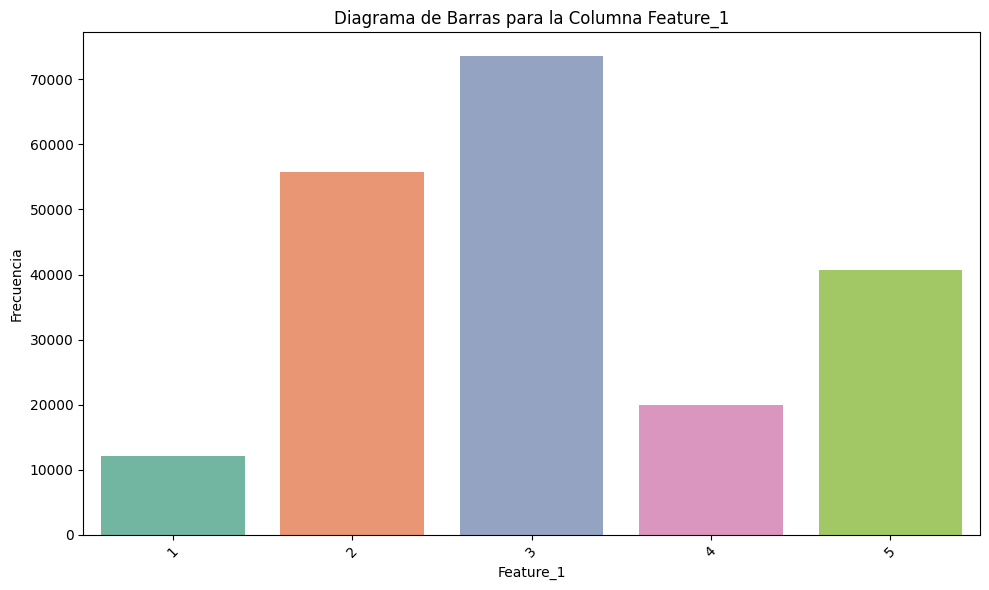

In [ ]:
# Diagrama de barras para la columna feature_1
vdf_train_feature_1 = vdf_train.select("feature_1").collect().to_pandas()
plt.figure(figsize=(10, 6))
sns.countplot(x=vdf_train_feature_1["feature_1"], palette="Set2")
plt.title("Diagrama de Barras para la Columna Feature_1")
plt.xlabel("Feature_1")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\564802368.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




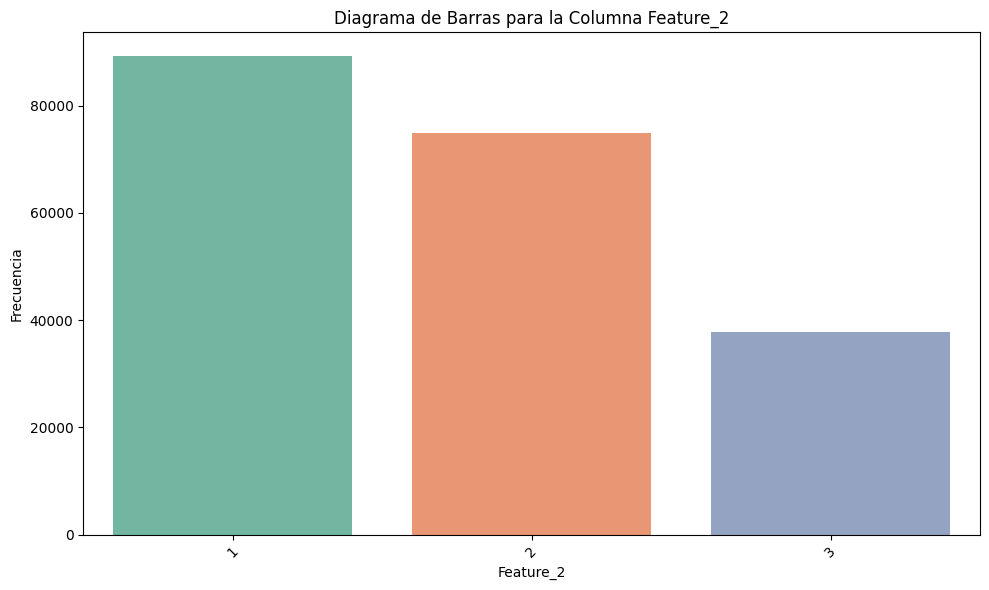

In [ ]:
# Diagrama de barras para la columna feature_2
vdf_train_feature_1 = vdf_train.select("feature_2").collect().to_pandas()
plt.figure(figsize=(10, 6))
sns.countplot(x=vdf_train_feature_1["feature_2"], palette="Set2")
plt.title("Diagrama de Barras para la Columna Feature_2")
plt.xlabel("Feature_2")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
vdf_feature3_dist = vdf_train.group_by("feature_3").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\964864988.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [22]:
vdf_feature3_dist

feature_3,count
i64,u32
1,114198
0,87719


C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\1327941608.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




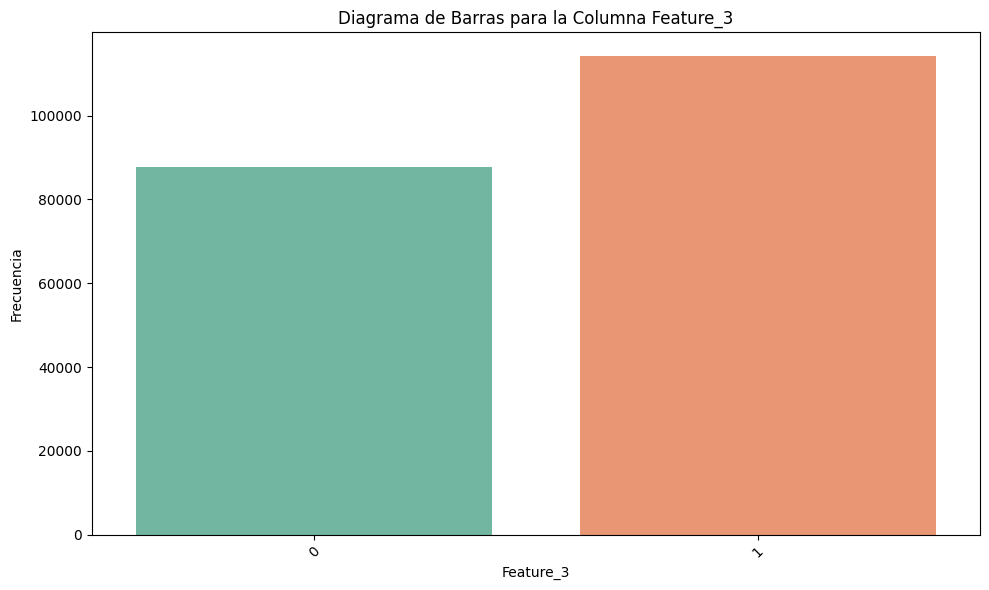

In [ ]:
# Diagrama de barras para la columna feature_3
vdf_train_feature_1 = vdf_train.select("feature_3").collect().to_pandas()
plt.figure(figsize=(10, 6))
sns.countplot(x=vdf_train_feature_1["feature_3"], palette="Set2")
plt.title("Diagrama de Barras para la Columna Feature_3")
plt.xlabel("Feature_3")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
vdf_target = vdf_train.select("target", "card_id")

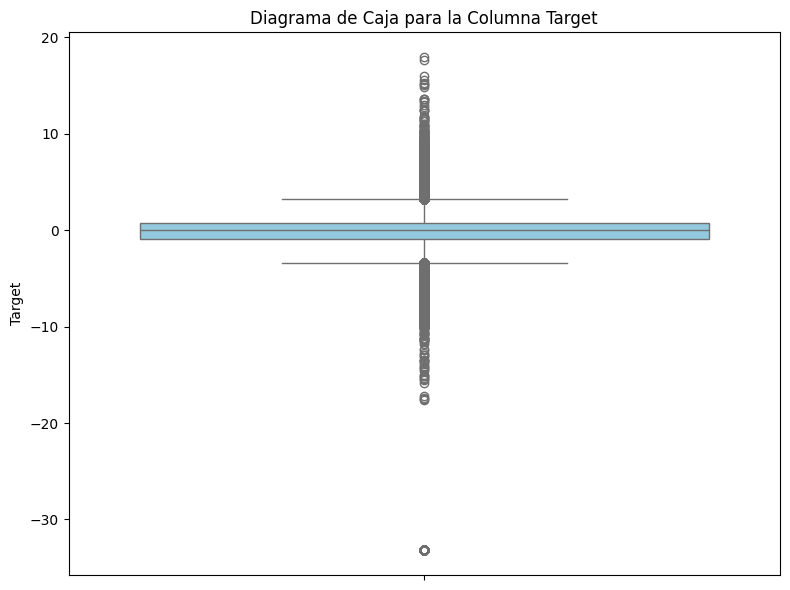

In [ ]:
# Diagrama de caja para la columna target
vdf_train_target = vdf_train.select("target").collect().to_pandas()
plt.figure(figsize=(8, 6))
sns.boxplot(y=vdf_train_target["target"], color="skyblue")
plt.title("Diagrama de Caja para la Columna Target")
plt.ylabel("Target")
plt.tight_layout()
plt.show()


Se ve que la información se encuentra concetrada cercana a cero. Con outliers muy pronunciados, talvez se pueda analizar los clientes a las cuales pertenecen esas tarjetas.

In [26]:
vdf_target_evol = vdf_train.select(
    "target",
    pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m")
)

In [27]:
vdf_target_by_month = vdf_train.group_by("first_active_month").agg(
    pl.col("target").mean().alias("mean_target"),
    pl.col("target").std().alias("std_target")
).sort("first_active_month")

In [28]:
fig = px.line(
    vdf_target_by_month,
    x="first_active_month",  # Eje X
    y="mean_target",  # Eje Y
    title="Diagrama de Líneas",
    labels={"first_active_month": "Eje X", "mean_target": "Eje Y"}  # Etiquetas personalizadas
)

# Mostrar el gráfico
fig.show()

Se confirma que el target es muy negativo atrás en el tiempo y hay tendido durante los ultimos meses de 2017 e inicios de 2018 tiendea mejorar target.

In [29]:
# Calcular cuartiles por fecha
quartiles_df = vdf_target_evol.group_by("first_active_month").agg([
    pl.col("target").quantile(0.25).alias("q1"),
    pl.col("target").quantile(0.50).alias("q2"),
    pl.col("target").quantile(0.75).alias("q3")
])

# Unir los cuartiles al DataFrame original
df = vdf_target_evol.join(quartiles_df, on="first_active_month")

# Asignar cada fila a un cuartil
df = df.with_columns(
    pl.when(df["target"] <= df["q1"]).then(pl.lit("Q1"))
    .when((df["target"] > df["q1"]) & (df["target"] <= df["q2"])).then(pl.lit("Q2"))
    .when((df["target"] > df["q2"]) & (df["target"] <= df["q3"])).then(pl.lit("Q3"))
    .otherwise(pl.lit("Q4"))
    .alias("quartile")
)

# Calcular la media de Target por cuartil y por fecha
grouped_df = df.group_by(["first_active_month", "quartile"]).agg(
    pl.mean("target").alias("mean_target")
)

# Convertir a pandas para graficar con Plotly
grouped_df_pandas = grouped_df.to_pandas()

grouped_df_pandas = grouped_df_pandas.sort_values(by="first_active_month")

# Crear el gráfico de líneas
fig = px.line(
    grouped_df_pandas,
    x="first_active_month",
    y="mean_target",
    color="quartile",  # Colorear por cuartil
    title="Evolución de la Media de Target por Cuartil (Cuartiles por Fecha)",
    labels={"first_active_month": "Fecha", "mean_target": "Media de Target", "quartile": "Cuartil"}
)

# Mostrar el gráfico
fig.show()

Al analizar los cuartiles por cada mes, se ve como tiene al incremento del target, gran parte de los outliers se encuentras entre 2012 y 2014

In [30]:
df_continuous = vdf_train.select(continuous)
# Convertir a pandas para calcular la correlación
df_continuous = df_continuous.to_pandas()

# Calcular la matriz de correlación
correlation_matrix = df_continuous.corr()

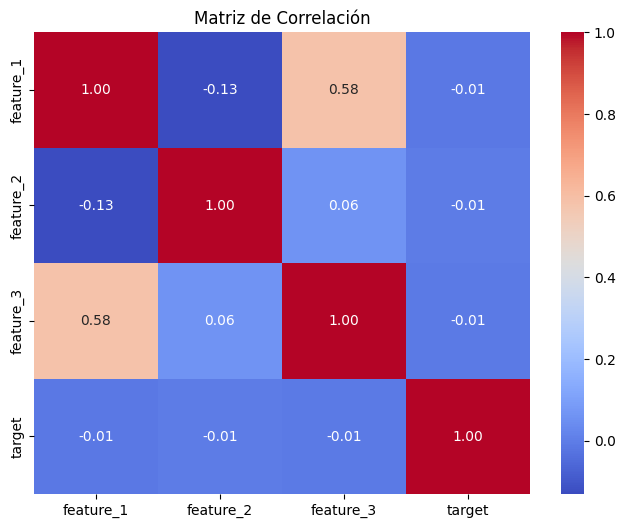

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
# Visualizar la matriz de correlación con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

## Transacciones historicas

In [32]:
vdf_hist_trx = pl.read_parquet("data/historical_transactions.parquet")

In [33]:
vdf_hist_trx_lazy = vdf_hist_trx.lazy()

In [34]:
vdf_hist_trx.describe()

statistic,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
str,str,str,f64,str,f64,str,f64,str,f64,f64,str,f64,f64,f64
"""count""","""29112361""","""29112361""",2.9112361e7,"""29112361""",2.9112361e7,"""28934202""",2.9112361e7,"""28973880""",2.9112361e7,2.9112361e7,"""29112361""",2.6459497e7,2.9112361e7,2.9112361e7
"""null_count""","""0""","""0""",0.0,"""0""",0.0,"""178159""",0.0,"""138481""",0.0,0.0,"""0""",2.652864e6,0.0,0.0
"""mean""",null,null,129.325617,null,0.648495,null,481.013028,null,-4.487294,0.036401,null,2.194578,10.56679,26.848388
"""std""",null,null,104.256301,null,2.795577,null,249.375714,null,3.5888,1123.521648,null,1.531896,6.366927,9.692793
"""min""","""N""","""C_ID_00007093c1""",-1.0,"""N""",-1.0,"""A""",-1.0,"""M_ID_000025127f""",-13.0,-0.746908,"""2017-01-01 00:00:08""",1.0,-1.0,-1.0
"""25%""",null,null,53.0,null,0.0,null,307.0,null,-7.0,-0.720356,null,1.0,9.0,19.0
"""50%""",null,null,90.0,null,0.0,null,454.0,null,-4.0,-0.688349,null,1.0,9.0,29.0
"""75%""",null,null,212.0,null,1.0,null,705.0,null,-2.0,-0.603254,null,3.0,16.0,34.0
"""max""","""Y""","""C_ID_fffffd5772""",347.0,"""Y""",999.0,"""C""",891.0,"""M_ID_ffffc28eaa""",0.0,6.0106e6,"""2018-02-28 23:59:51""",5.0,24.0,41.0


In [35]:
vdf_hist_trx.schema

Schema([('authorized_flag', String),
        ('card_id', String),
        ('city_id', Int64),
        ('category_1', String),
        ('installments', Int64),
        ('category_3', String),
        ('merchant_category_id', Int64),
        ('merchant_id', String),
        ('month_lag', Int64),
        ('purchase_amount', Float64),
        ('purchase_date', String),
        ('category_2', Float64),
        ('state_id', Int64),
        ('subsector_id', Int64)])

In [36]:
# Usar la función
categorical, continuous = separate_columns(vdf_hist_trx)
print("Categóricas:", categorical)
print("Continuas:", continuous)

Categóricas: ['authorized_flag', 'card_id', 'category_1', 'category_3', 'merchant_id', 'purchase_date']
Continuas: ['city_id', 'installments', 'merchant_category_id', 'month_lag', 'purchase_amount', 'category_2', 'state_id', 'subsector_id']


In [37]:
vdf_auth_dist = vdf_hist_trx.group_by("authorized_flag").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\3748603782.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [38]:
px.bar(
    vdf_auth_dist.to_pandas(),
    x="authorized_flag",
    y="count",
    title="Distribución de authorized_flag",
    labels={"authorized_flag": "authorized_flag ", "count": "Count"},
).show()

Vemos un desbalance en la variable autorizacion de compra, sin embargo, no es la columna a predecir

In [39]:
vdf_installment_dist = vdf_hist_trx.group_by("installments").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\3130361118.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [40]:
vdf_installment_authorized = vdf_hist_trx_lazy.group_by([pl.col("installments"), "authorized_flag"]).count().collect()

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\4113628745.py:1: DeprecationWarning:

`count` was renamed; use `len` instead



In [41]:
vdf_installment_authorized.sort(
    "installments", "authorized_flag"
).to_pandas()

,installments,authorized_flag,count
0,-1,N,20365
1,-1,Y,157794
2,0,N,1109158
3,0,Y,14302589
4,1,N,1085735
5,1,Y,10591787
6,2,N,77291
7,2,Y,589125
8,3,N,74136
9,3,Y,464071


In [42]:
# Calcular correlación entre installments y authorized_flag (convertida a numérica)
vdf_installment_authorized = vdf_installment_authorized.with_columns(
    pl.when(pl.col("authorized_flag") == pl.lit('Y')).then(
        pl.lit(1)
    ).otherwise(
        pl.lit(0)  
    ).alias("authorized_flag")
)

correlation = vdf_installment_authorized.select(
    pl.corr("installments", "authorized_flag")
)

In [43]:
correlation

installments
f64
3.8224e-18


No relacionadas

Alta correlacion entre categorias installments y aprobacion de compra

In [44]:
vdf_installment_dist = vdf_installment_dist.with_columns(
    pl.col("count").cast(pl.Int64)  # Asegúrate de que sea un entero
).filter(pl.col("installments") < 20)

In [45]:
fig = px.bar(
    vdf_installment_dist,
    x="installments",  # Eje X
    y="count",         # Eje Y
    title="Distribución de Installments",
    color="installments",  # Colorear las barras según el valor de installments
    text="count",          # Mostrar los valores de count como etiquetas
    labels={"installments": "Installments", "count": "Count"}  # Etiquetas personalizadas
)

# Ajustar la posición del texto
fig.update_traces(textposition="outside")  # Mostrar etiquetas fuera de las barras

# Mostrar el gráfico
fig.show()

In [ ]:
import polars as pl
import plotly.express as px
import pandas as pd

# Agrupar por día y calcular la mediana y media
vdf_purch_amnt_dist = (
    vdf_hist_trx_lazy
    .group_by(pl.col("purchase_date").str.slice(0, 10))  # Agrupar por día
    .agg(
        # pl.col("purchase_amount").median().alias("median_purchase_amount"),
        pl.col("purchase_amount").mean().alias("mean_purchase_amount"),
    )
    .collect()  # Ejecutar las operaciones
)

# Convertir solo las columnas necesarias a pandas
df_pandas = vdf_purch_amnt_dist.select(["purchase_date", "mean_purchase_amount"]).to_pandas()

# df_pandas = pd.to_datetime(df_pandas.purchase_date, format="%Y-%m-%d")

df_pandas = df_pandas.sort_values(by="purchase_date")


# Crear el gráfico de líneas
fig = px.line(
    df_pandas,
    x="purchase_date",
    y=["mean_purchase_amount"],
    title="Evolución de la Media de Purchase Amount por Fecha",
    labels={"purchase_date": "Fecha", "value": "Purchase Amount"},
)

# Mostrar el gráfico
fig.show()

In [ ]:
from scipy.stats import f_oneway

# Crear grupos basados en category_3
groups = [vdf_hist_trx.filter(pl.col("category_3") == cat)["month_lag"].to_numpy()
          for cat in vdf_hist_trx["category_3"].unique()]

# Realizar ANOVA
f_stat, p_value = f_oneway(*groups)

print(f"F-Statistic: {f_stat}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Conclusión: Existe una diferencia significativa entre las categorías de `category_3` en `month_lag`.")
else:
    print("Conclusión: No existe una diferencia significativa entre las categorías de `category_3` en `month_lag`.")

F-Statistic: nan
p-value: nan
Conclusión: No existe una diferencia significativa entre las categorías de `category_3` en `month_lag`.


C:\Users\Paul\AppData\Local\Temp\ipykernel_18928\2365613915.py:4: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  groups = [vdf_hist_trx.filter(pl.col("category_3") == cat)["month_lag"].to_numpy()
C:\Users\Paul\AppData\Local\Temp\ipykernel_18928\2365613915.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)


Debido a la cantidad de nulos

In [ ]:
import polars as pl
import plotly.express as px

# Agrupar las fechas por mes
vdf_purch_amnt_dist = (
    vdf_hist_trx.lazy()
    .with_columns(
        pl.col("purchase_date").str.slice(0, 7).alias("purchase_month")  # Extraer año-mes
    )
    .select(["purchase_month", "purchase_amount"])  # Seleccionar columnas necesarias
    .collect()
)

In [ ]:
vdf_purch_amnt_dist

purchase_month,purchase_amount
str,f64
"""2017-06""",-0.703331
"""2017-07""",-0.733128
"""2017-08""",-0.720386
"""2017-09""",-0.735352
"""2017-03""",-0.722865
…,…
"""2017-01""",-0.632706
"""2017-02""",-0.632706
"""2017-12""",-0.65774


In [ ]:
import polars as pl
import os

# Leer el archivo Parquet original
vdf_hist_trx = pl.read_parquet("data/historical_transactions.parquet")

# Crear una columna para el mes de compra
vdf_hist_trx = vdf_hist_trx.with_columns(
    pl.col("purchase_date").str.slice(0, 7).alias("purchase_month")  # Extraer año-mes
)

# Crear una carpeta para guardar los archivos particionados
output_dir = "data/processed/historical_transactions_partitioned"
os.makedirs(output_dir, exist_ok=True)

# Obtener los valores únicos de `purchase_month`
unique_months = vdf_hist_trx["purchase_month"].unique()

# Guardar un archivo Parquet para cada mes
for month in unique_months:
    # Filtrar los datos para el mes actual
    month_data = vdf_hist_trx.filter(pl.col("purchase_month") == month)
    
    # Guardar los datos en un archivo Parquet
    month_data.write_parquet(f"{output_dir}/purchase_month={month}.parquet")

print(f"Archivos particionados guardados en: {output_dir}")

Archivos particionados guardados en: data/processed/historical_transactions_partitioned


In [ ]:
import polars as pl
import os

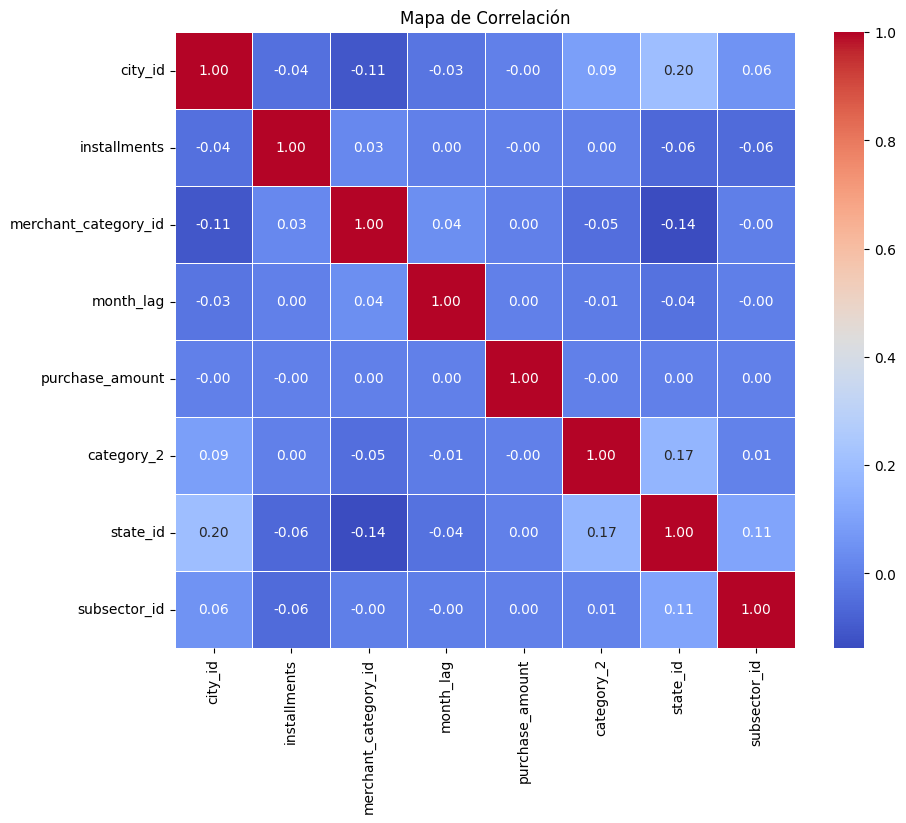

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Materializar el DataFrame perezoso
vdf_hist_trx = vdf_hist_trx_lazy.select(
      continuous
).collect()

# Convertir a pandas
df_pandas = vdf_hist_trx.to_pandas()

# Seleccionar solo las columnas numéricas
df_numeric = df_pandas

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Crear el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlación")
plt.show()

Baja correlacion entre variable numericas

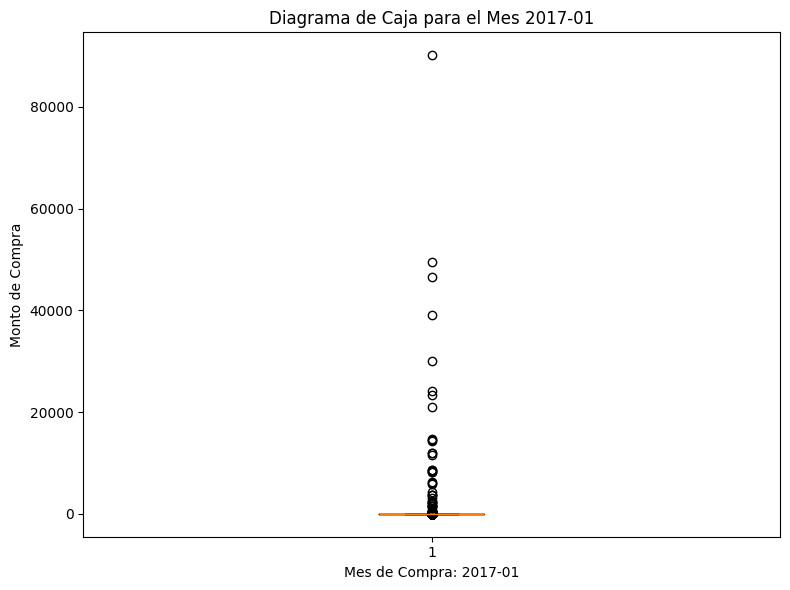

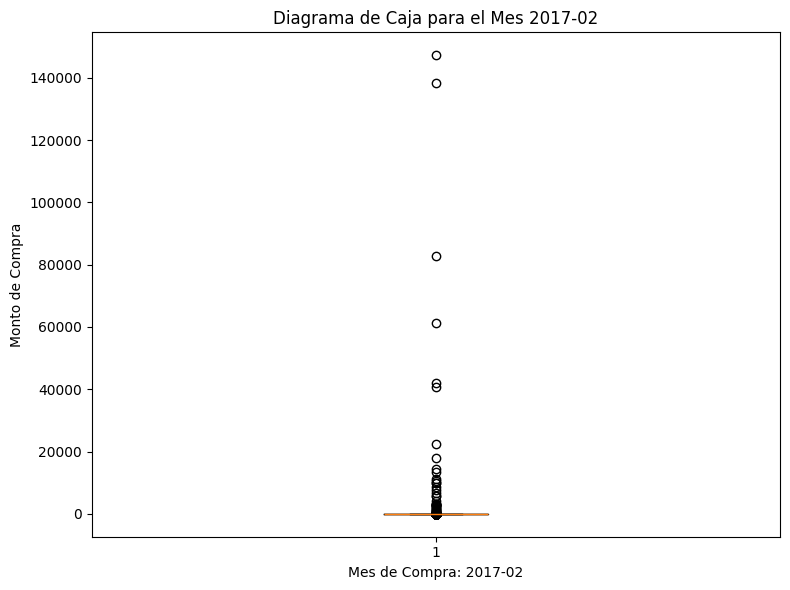

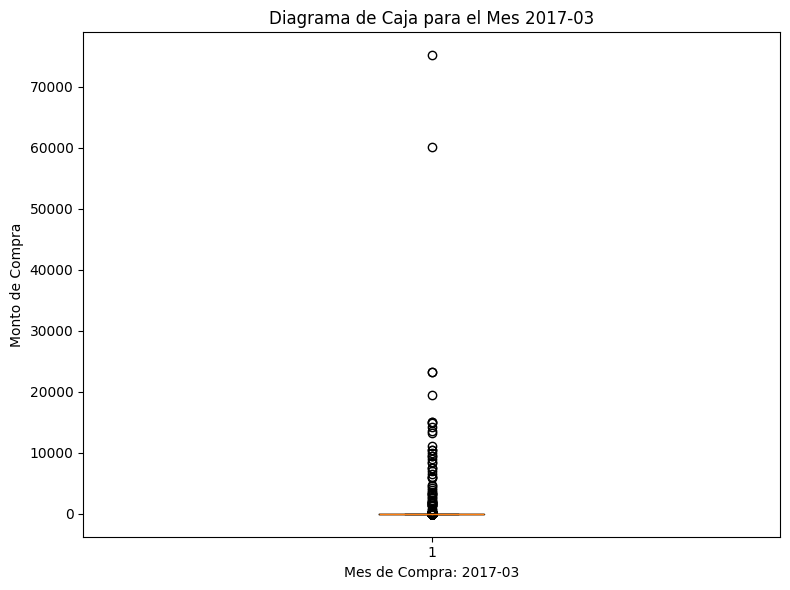

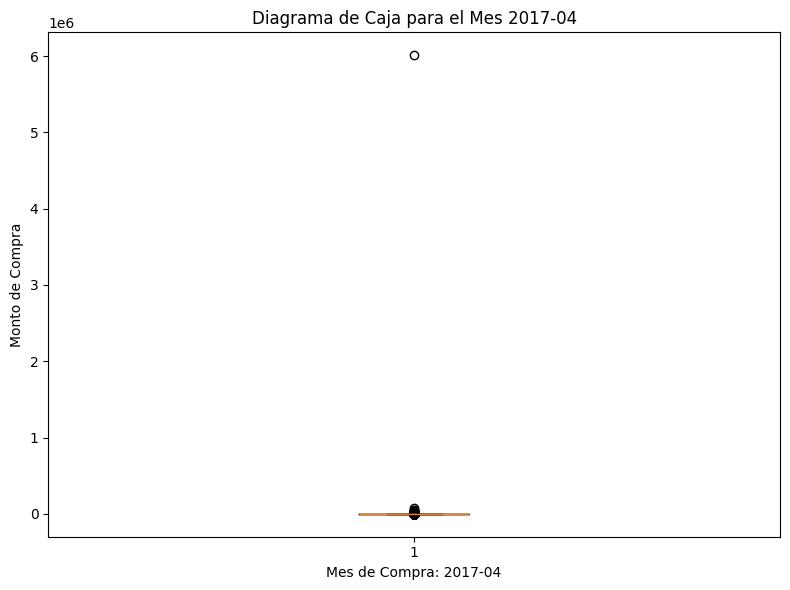

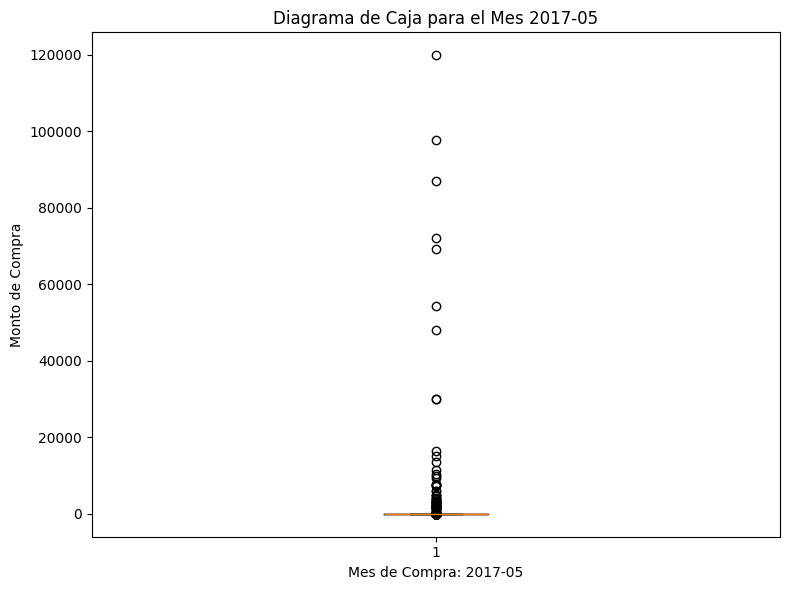

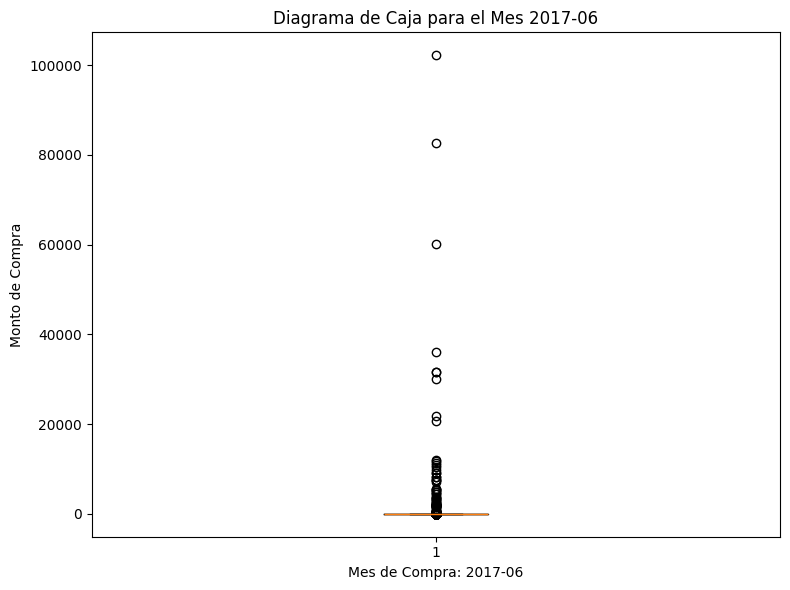

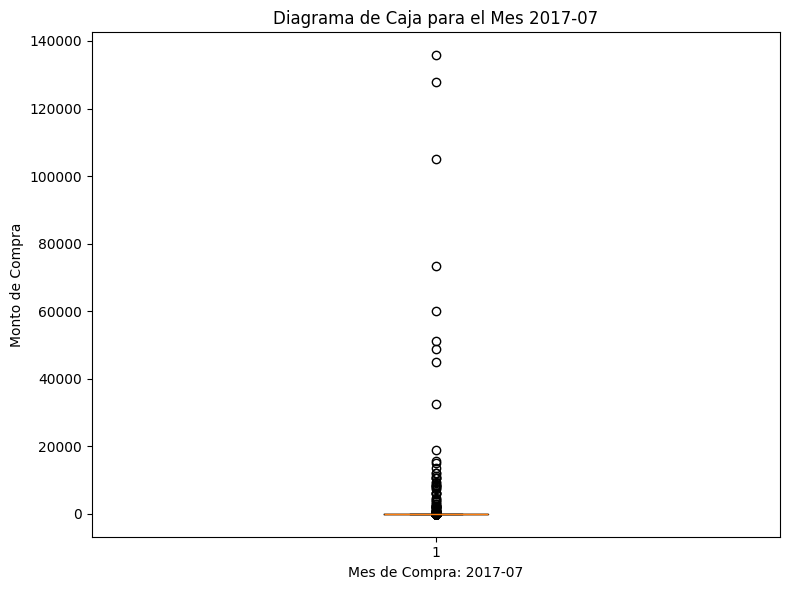

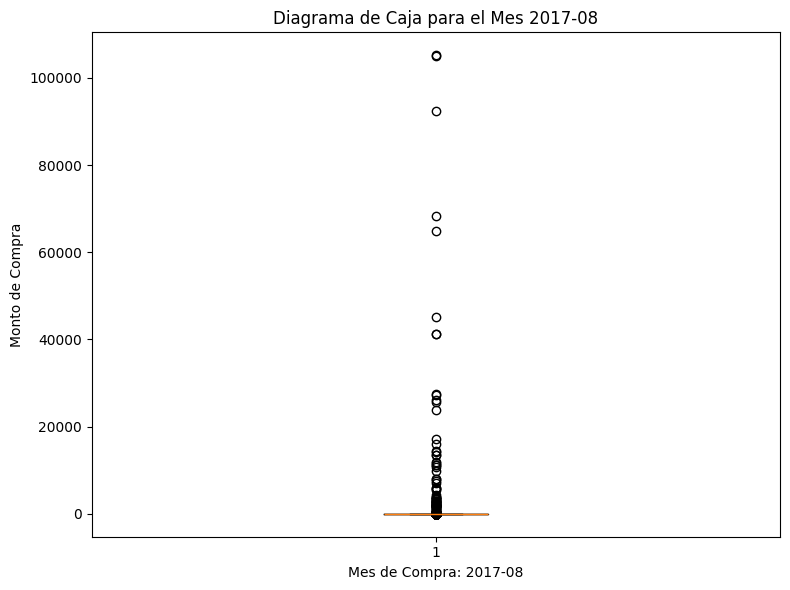

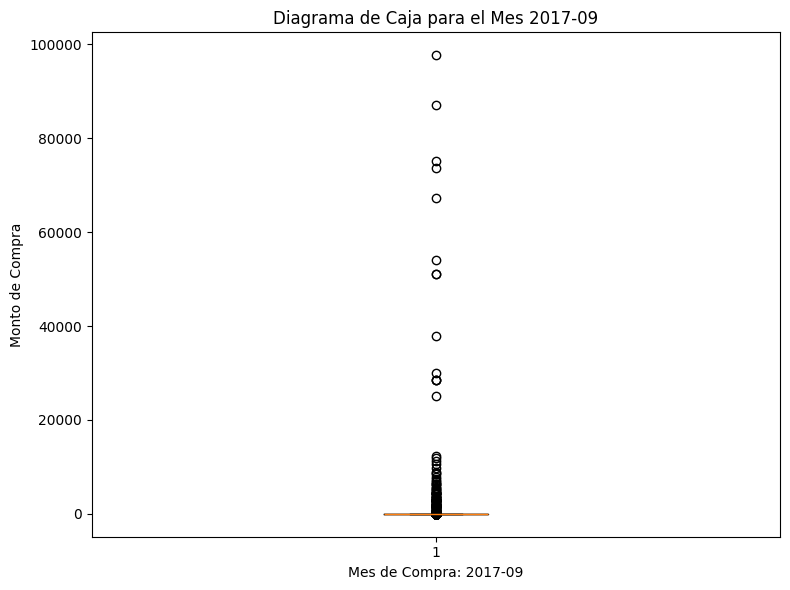

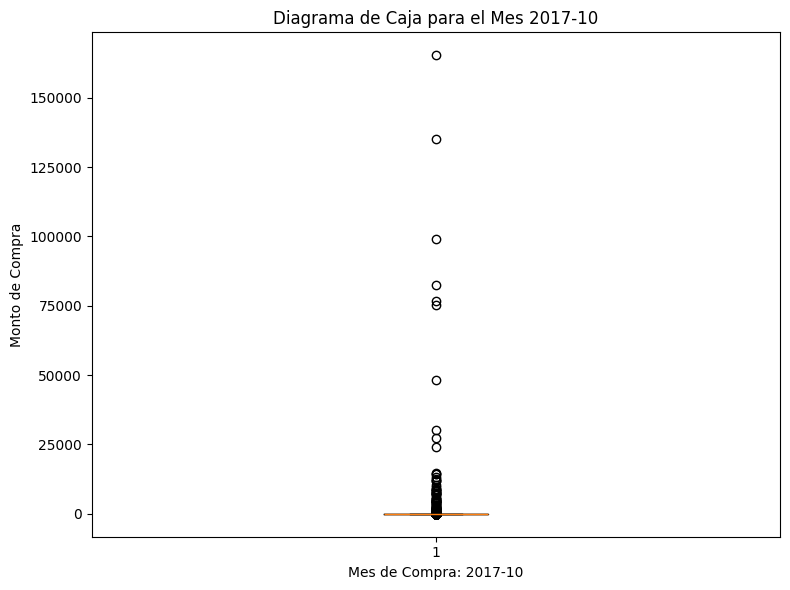

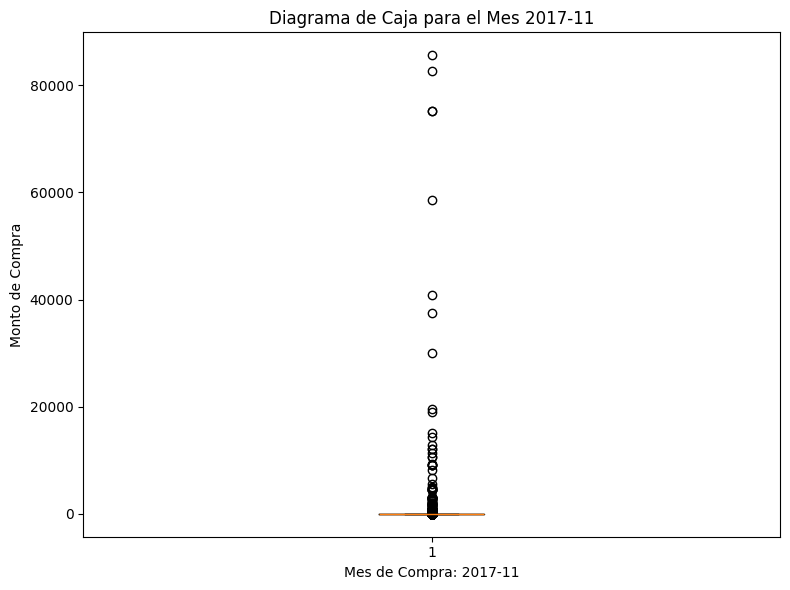

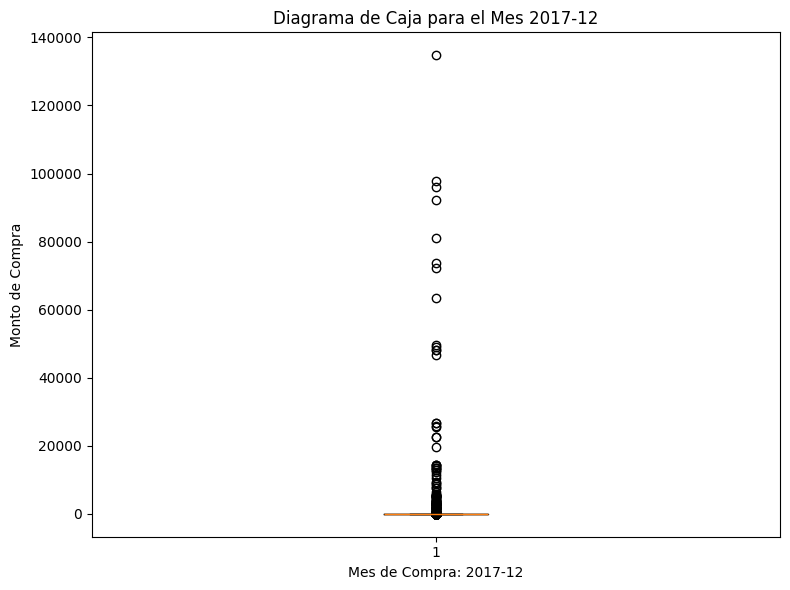

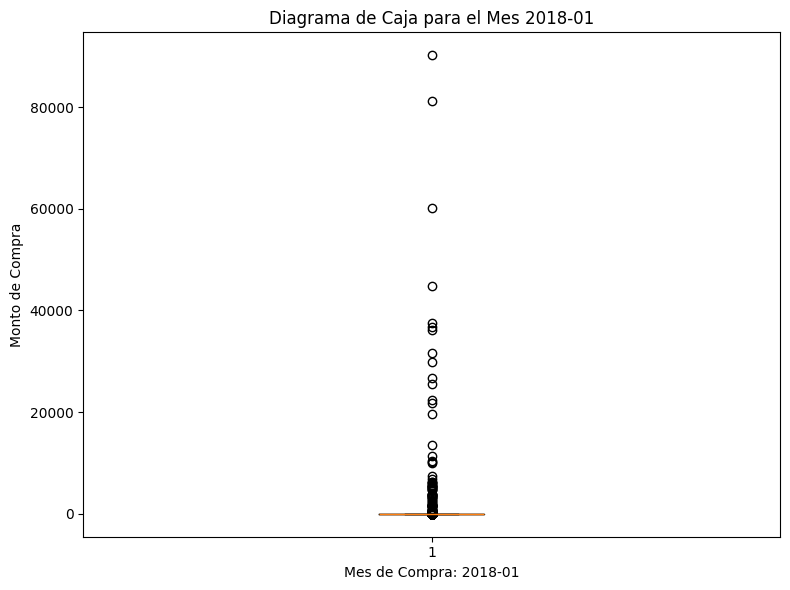

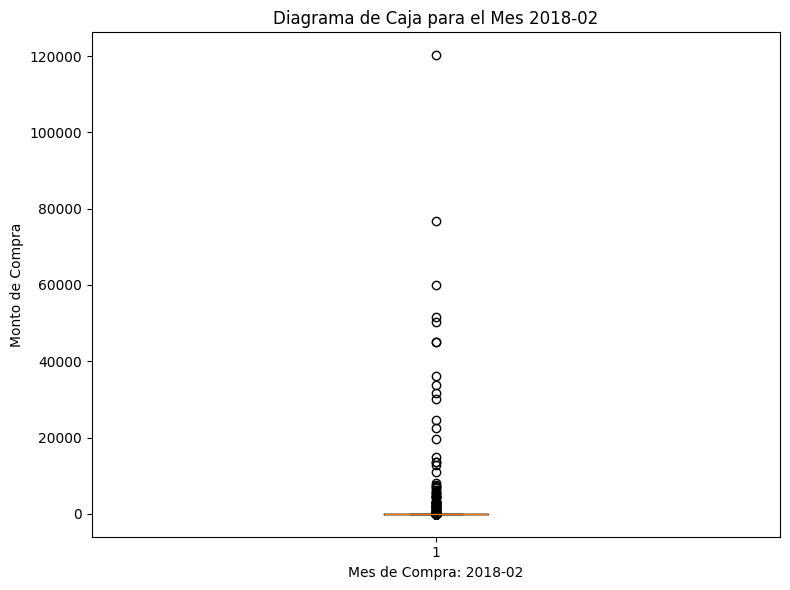

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import os

# Ruta de la carpeta con los archivos particionados
output_dir = "data/processed/historical_transactions_partitioned"

# Obtener la lista de archivos Parquet en la carpeta
parquet_files = [f for f in os.listdir(output_dir) if f.endswith(".parquet")]

# Recorrer cada archivo Parquet
for parquet_file in parquet_files:
    # Leer el archivo Parquet
    file_path = os.path.join(output_dir, parquet_file)
    vdf_fila = pl.read_parquet(file_path)
    
    # Convertir a pandas para graficar
    df_pandas = vdf_fila.to_pandas()
    
    # Preparar los datos para el boxplot
    boxplot_data = df_pandas["purchase_amount"].tolist()
    
    # Crear el boxplot
    plt.figure(figsize=(8, 6))
    plt.boxplot(boxplot_data, showfliers=True, vert=True)
    
    # Extraer el nombre del mes desde el archivo
    purchase_month = parquet_file.split("=")[1].replace(".parquet", "")
    
    # Personalizar el gráfico
    plt.title(f"Diagrama de Caja para el Mes {purchase_month}")
    plt.xlabel(f"Mes de Compra: {purchase_month}")
    plt.ylabel("Monto de Compra")
    plt.tight_layout()
    
    # Mostrar el gráfico
    plt.show()

Se comprende la existencia de varios outliers, podrian explicar los outliers de la varibale Target

## Merchants

In [ ]:
vdf_merchants = pl.read_parquet("data/merchants.parquet")

In [ ]:
vdf_merchants.describe()

statistic,merchant_id,merchant_group_id,merchant_category_id,subsector_id,numerical_1,numerical_2,category_1,most_recent_sales_range,most_recent_purchases_range,avg_sales_lag3,avg_purchases_lag3,active_months_lag3,avg_sales_lag6,avg_purchases_lag6,active_months_lag6,avg_sales_lag12,avg_purchases_lag12,active_months_lag12,category_4,city_id,state_id,category_2
str,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64
"""count""","""334696""",334696.0,334696.0,334696.0,334696.0,334696.0,"""334696""","""334696""","""334696""",334683.0,334696.0,334696.0,334683.0,334696.0,334696.0,334683.0,334696.0,334696.0,"""334696""",334696.0,334696.0,322809.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""",13.0,0.0,0.0,13.0,0.0,0.0,13.0,0.0,0.0,"""0""",0.0,0.0,11887.0
"""mean""",null,31028.736143,423.131663,25.116404,0.011476,0.008103,null,null,null,13.832993,inf,2.994108,21.650787,inf,5.947397,25.227709,inf,11.599335,null,102.917926,11.860942,2.380002
"""std""",null,31623.043426,252.898046,9.807371,1.098154,1.070497,null,null,null,2395.489999,NaN,0.095247,3947.108099,NaN,0.394936,5251.842165,NaN,1.520138,null,107.090673,6.176889,1.562661
"""min""","""M_ID_000025127f""",1.0,-1.0,-1.0,-0.057471,-0.057471,"""N""","""A""","""A""",-82.13,0.333495,1.0,-82.13,0.167045,1.0,-82.13,0.09833,1.0,"""N""",-1.0,-1.0,1.0
"""25%""",null,3612.0,222.0,19.0,-0.057471,-0.057471,null,null,null,0.88,0.92365,3.0,0.85,0.902248,6.0,0.85,0.898333,12.0,null,-1.0,9.0,1.0
"""50%""",null,19900.0,373.0,27.0,-0.057471,-0.057471,null,null,null,1.0,1.016667,3.0,1.01,1.026961,6.0,1.02,1.043362,12.0,null,69.0,9.0,2.0
"""75%""",null,51707.0,683.0,33.0,-0.047556,-0.047556,null,null,null,1.16,1.14652,3.0,1.23,1.215574,6.0,1.29,1.266478,12.0,null,182.0,16.0,4.0
"""max""","""M_ID_ffffc28eaa""",112586.0,891.0,41.0,183.735111,182.079322,"""Y""","""E""","""E""",851844.64,inf,3.0,1.513959e6,inf,6.0,2.567408e6,inf,12.0,"""Y""",347.0,24.0,5.0


In [ ]:
vdf_merchants_lazy = vdf_merchants.lazy()

In [ ]:
vdf_merchants.schema

Schema([('merchant_id', String),
        ('merchant_group_id', Int64),
        ('merchant_category_id', Int64),
        ('subsector_id', Int64),
        ('numerical_1', Float64),
        ('numerical_2', Float64),
        ('category_1', String),
        ('most_recent_sales_range', String),
        ('most_recent_purchases_range', String),
        ('avg_sales_lag3', Float64),
        ('avg_purchases_lag3', Float64),
        ('active_months_lag3', Int64),
        ('avg_sales_lag6', Float64),
        ('avg_purchases_lag6', Float64),
        ('active_months_lag6', Int64),
        ('avg_sales_lag12', Float64),
        ('avg_purchases_lag12', Float64),
        ('active_months_lag12', Int64),
        ('category_4', String),
        ('city_id', Int64),
        ('state_id', Int64),
        ('category_2', Float64)])

In [ ]:
# Usar la función
categorical, continuous = separate_columns(vdf_merchants)
print("Categóricas:", categorical)
print("Continuas:", continuous)

Categóricas: ['merchant_id', 'category_1', 'most_recent_sales_range', 'most_recent_purchases_range', 'category_4']
Continuas: ['merchant_group_id', 'merchant_category_id', 'subsector_id', 'numerical_1', 'numerical_2', 'avg_sales_lag3', 'avg_purchases_lag3', 'active_months_lag3', 'avg_sales_lag6', 'avg_purchases_lag6', 'active_months_lag6', 'avg_sales_lag12', 'avg_purchases_lag12', 'active_months_lag12', 'city_id', 'state_id', 'category_2']


In [ ]:
vdf_merchants

merchant_id,merchant_group_id,merchant_category_id,subsector_id,numerical_1,numerical_2,category_1,most_recent_sales_range,most_recent_purchases_range,avg_sales_lag3,avg_purchases_lag3,active_months_lag3,avg_sales_lag6,avg_purchases_lag6,active_months_lag6,avg_sales_lag12,avg_purchases_lag12,active_months_lag12,category_4,city_id,state_id,category_2
str,i64,i64,i64,f64,f64,str,str,str,f64,f64,i64,f64,f64,i64,f64,f64,i64,str,i64,i64,f64
"""M_ID_838061e48c""",8353,792,9,-0.057471,-0.057471,"""N""","""E""","""E""",-0.4,9.666667,3,-2.25,18.666667,6,-2.32,13.916667,12,"""N""",242,9,1.0
"""M_ID_9339d880ad""",3184,840,20,-0.057471,-0.057471,"""N""","""E""","""E""",-0.72,1.75,3,-0.74,1.291667,6,-0.57,1.6875,12,"""N""",22,16,1.0
"""M_ID_e726bbae1e""",447,690,1,-0.057471,-0.057471,"""N""","""E""","""E""",-82.13,260.0,2,-82.13,260.0,2,-82.13,260.0,2,"""N""",-1,5,5.0
"""M_ID_a70e9c5f81""",5026,792,9,-0.057471,-0.057471,"""Y""","""E""","""E""",null,1.666667,3,null,4.666667,6,null,3.833333,12,"""Y""",-1,-1,null
"""M_ID_64456c37ce""",2228,222,21,-0.057471,-0.057471,"""Y""","""E""","""E""",null,0.5,3,null,0.361111,6,null,0.347222,12,"""Y""",-1,-1,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""M_ID_1f4773aa76""",1145,705,33,3.174788,-0.047556,"""N""","""A""","""A""",1.0,1.022618,3,0.99,1.019505,6,1.0,1.024796,12,"""Y""",69,9,1.0
"""M_ID_725a60d404""",35,544,29,-0.057471,-0.057471,"""Y""","""A""","""A""",0.89,0.927684,3,0.78,0.813473,6,0.59,0.606765,12,"""Y""",-1,-1,null
"""M_ID_f2045dd267""",35,561,7,-0.057471,-0.057471,"""N""","""A""","""A""",0.96,0.982957,3,0.9,0.924769,6,0.74,0.750763,8,"""Y""",160,21,5.0


In [ ]:
vdf_merchants.select(
    pl.col("merchant_category_id")
).unique().count()

merchant_category_id
u32
324


In [ ]:
vdf_1 = vdf_merchants.group_by("most_recent_sales_range").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\2115135986.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [ ]:
px.bar(
    vdf_1.to_pandas(),
    x="most_recent_sales_range",
    y="count",
    title="Distribución de most_recent_sales_range",
    labels={"most_recent_sales_range": "most_recent_sales_range", "count": "Count"},
).show()

Gran parte de los mercaderes se encuentra en la escala mas baja del rango de inrgesos

In [ ]:
vdf_2 = vdf_merchants.group_by("most_recent_purchases_range").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\1648868323.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [ ]:
px.bar(
    vdf_2.to_pandas(),
    x="most_recent_purchases_range",
    y="count",
    title="Distribución de most_recent_purchases_range",
    labels={"most_recent_purchases_range": "most_recent_purchases_range", "count": "Count"},
).show()

El mismo comportamiento se repite para el rango de ventas

In [ ]:
vdf_month_lag3 = vdf_merchants.group_by("active_months_lag3").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\1981763504.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [ ]:
# Cambiar datatype de 'active_months_lag3' a Int64
vdf_month_lag3 = vdf_month_lag3.with_columns(
    pl.col("count").cast(pl.Int64)
)

In [ ]:
px.bar(
    vdf_month_lag3.to_pandas(),
    x="active_months_lag3",
    y="count",
    title="Distribución de active_months_lag3",
    labels={"active_months_lag3": "active_months_lag3", "count": "Count"},
).show()

In [ ]:
vdf_month_lag6 = vdf_merchants.group_by("active_months_lag6").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\3994539503.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [ ]:
# Cambiar datatype de 'active_months_lag6' a Int64
vdf_month_lag6 = vdf_month_lag6.with_columns(
    pl.col("count").cast(pl.Int64)
)

In [ ]:
px.bar(
    vdf_month_lag6.to_pandas(),
    x="active_months_lag6",
    y="count",
    title="Distribución de active_months_lag6",
    labels={"active_months_lag6": "active_months_lag6", "count": "Count"},
).show()

In [ ]:
vdf_month_lag12 = vdf_merchants.group_by("active_months_lag12").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\72420525.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [ ]:
# Cambiar datatype de 'active_months_lag12' a Int64
vdf_month_lag12 = vdf_month_lag12.with_columns(
    pl.col("count").cast(pl.Int64)
)

In [ ]:
px.bar(
    vdf_month_lag12.to_pandas(),
    x="active_months_lag12",
    y="count",
    title="Distribución de active_months_lag12",
    labels={"active_months_lag12": "active_months_lag12", "count": "Count"},
).show()

Vemos que son pocos los mercaderes inactivos

In [ ]:
avg_columns = [
    "avg_sales_lag3", "avg_sales_lag6", "avg_sales_lag12",
    "avg_purchases_lag3", "avg_purchases_lag6", "avg_purchases_lag12"
]

In [ ]:
vdf_3 = vdf_merchants.select(
    [
        pl.col(col).alias(f"mean_{col}") for col in avg_columns
    ]
)

In [ ]:
df_merchants_pandas = vdf_3.to_pandas()

In [ ]:
df_merchants_pandas

,mean_avg_sales_lag3,mean_avg_sales_lag6,mean_avg_sales_lag12,mean_avg_purchases_lag3,mean_avg_purchases_lag6,mean_avg_purchases_lag12
0,-0.40,-2.25,-2.32,9.666667,18.666667,13.916667
1,-0.72,-0.74,-0.57,1.750000,1.291667,1.687500
2,-82.13,-82.13,-82.13,260.000000,260.000000,260.000000
3,NaN,NaN,NaN,1.666667,4.666667,3.833333
4,NaN,NaN,NaN,0.500000,0.361111,0.347222
...,...,...,...,...,...,...
334691,1.00,0.99,1.00,1.022618,1.019505,1.024796
334692,0.89,0.78,0.59,0.927684,0.813473,0.606765
334693,0.96,0.90,0.74,0.982957,0.924769,0.750763
334694,0.94,0.82,0.65,0.919558,0.783000,0.584000


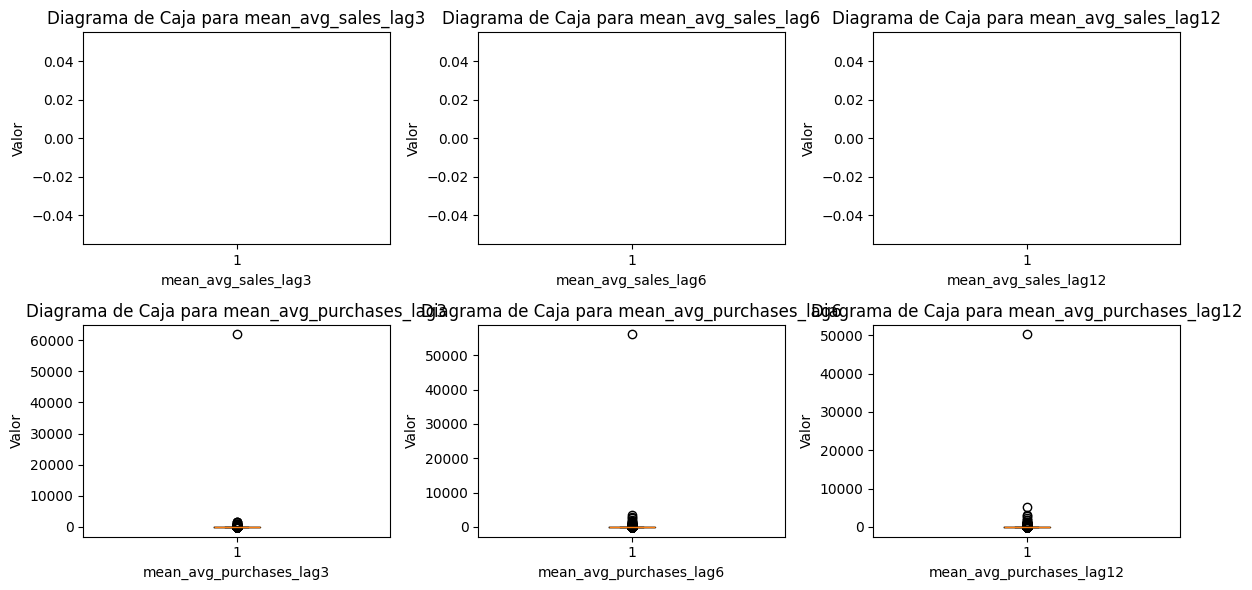

In [ ]:
# Crear un boxplot para cada columna
plt.figure(figsize=(12, 6))
for i, col in enumerate(df_merchants_pandas.columns):
    plt.subplot(2, 3, i + 1)
    plt.boxplot(df_merchants_pandas[col], showfliers=True)
    plt.title(f"Diagrama de Caja para {col}")
    plt.xlabel(col)
    plt.ylabel("Valor")
    plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [ ]:
# Contar valores nulos por columna
nulos_por_columna = df_merchants_pandas.isnull().sum()

# Mostrar los resultados
print(nulos_por_columna)

mean_avg_sales_lag3         13
mean_avg_sales_lag6         13
mean_avg_sales_lag12        13
mean_avg_purchases_lag3      0
mean_avg_purchases_lag6      0
mean_avg_purchases_lag12     0
dtype: int64


In [ ]:
# Cambiar nulos por ceros
df_merchants_pandas = df_merchants_pandas.fillna(0)

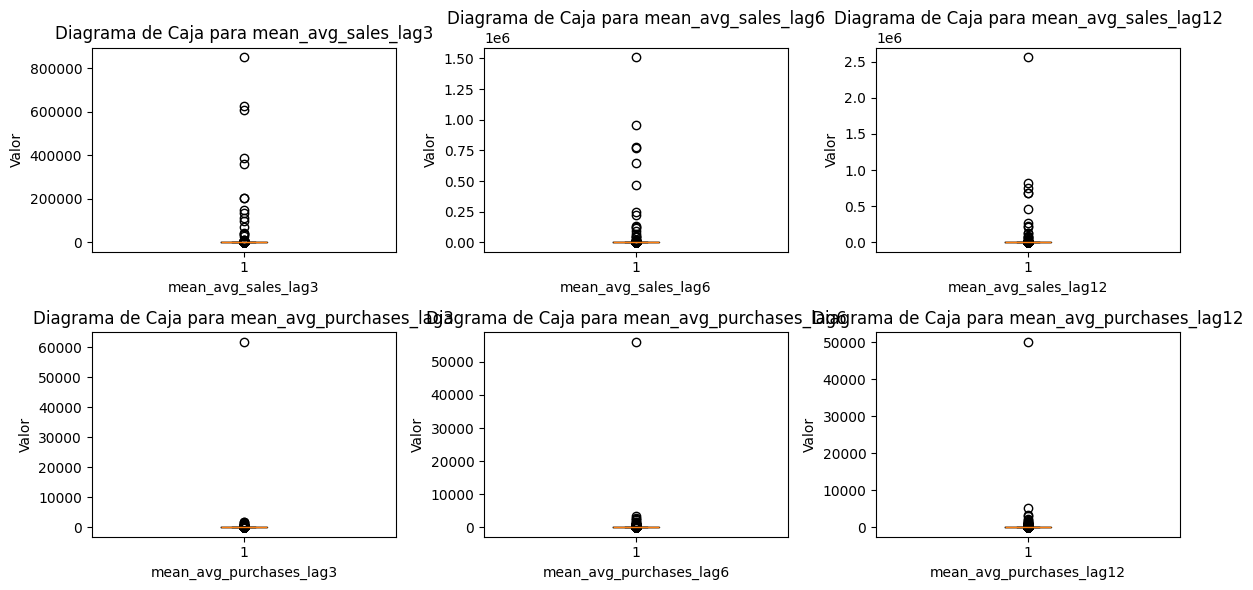

In [ ]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(df_merchants_pandas.columns):
    plt.subplot(2, 3, i + 1)
    plt.boxplot(df_merchants_pandas[col], showfliers=True)
    plt.title(f"Diagrama de Caja para {col}")
    plt.xlabel(col)
    plt.ylabel("Valor")
    plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [ ]:
# Asegurarse de que las columnas no tengan valores nulos
vdf_merchants = vdf_merchants.with_columns(
    pl.col("most_recent_sales_range").fill_null("Unknown"),
    pl.col("most_recent_purchases_range").fill_null("Unknown")
)

In [ ]:
import polars as pl
from scipy.stats import chi2_contingency

# Crear una tabla de contingencia con Polars
contingency_table = (
    vdf_merchants
    .group_by(["most_recent_sales_range", "most_recent_purchases_range"])
    .count()
    .pivot(
        values="count",
        index="most_recent_sales_range",
        columns="most_recent_purchases_range"
    )
    .fill_null(0)  # Reemplazar valores nulos con 0
)


C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\2762591441.py:8: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\2762591441.py:9: DeprecationWarning:

the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.



In [ ]:
contingency_table

most_recent_sales_range,A,C,E,B,D
str,u32,u32,u32,u32,u32
"""C""",13,19342,1439,1860,11421
"""B""",373,1638,9,2809,208
"""A""",624,48,1,328,4
"""E""",0,399,141459,0,35246
"""D""",0,12717,32401,49,72308


In [ ]:
# Convertir la tabla de contingencia a un formato NumPy para usar con scipy
contingency_array = contingency_table.select([
    pl.all().exclude("most_recent_sales_range")  # Excluir el índice si está presente
]).to_numpy()

# Realizar el test de Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(contingency_array)

# Mostrar los resultados
print("Resultados del Test de Chi-cuadrado:")
print(f"Chi-cuadrado: {chi2}")
print(f"Grados de libertad: {dof}")
print(f"Valor p: {p}")

# Interpretación
if p < 0.05:
    print("\nConclusión: Existe una relación significativa entre las variables.")
else:
    print("\nConclusión: No existe una relación significativa entre las variables.")

Resultados del Test de Chi-cuadrado:
Chi-cuadrado: 435305.4900859653
Grados de libertad: 16
Valor p: 0.0

Conclusión: Existe una relación significativa entre las variables.


Correlacion entre rango de ingresos y rango de transacciones.

In [ ]:
vdf_avg_sales_by_most_recent = vdf_merchants_lazy.group_by("most_recent_sales_range").agg(
    pl.sum("avg_sales_lag3").alias("total_avg_sales_lag3"),
    pl.sum("avg_sales_lag6").alias("total_avg_sales_lag6"),
    pl.sum("avg_sales_lag12").alias("total_avg_sales_lag12"),
    pl.col("merchant_id").n_unique().alias("merchants_count"),
).collect()

In [ ]:
vdf_avg_sales_by_most_recent

most_recent_sales_range,total_avg_sales_lag3,total_avg_sales_lag6,total_avg_sales_lag12,merchants_count
str,f64,f64,f64,u32
"""E""",4.4741e6,7.0904e6,8.2862e6,177093
"""A""",1015.79,1024.32,1039.22,998
"""C""",34164.6,34370.92,34585.82,34073
"""D""",115309.99,115125.72,116107.87,117465
"""B""",5069.08,5261.42,5357.2,5034


In [ ]:
vdf_avg_sales_by_most_recent.select(
    pl.col("*")
    , (pl.col("total_avg_sales_lag3")/pl.col("merchants_count")).alias("total_avg_sales_lag3_per_merchant")
    , (pl.col("total_avg_sales_lag6")/pl.col("merchants_count")).alias("total_avg_sales_lag6_per_merchant")
    , (pl.col("total_avg_sales_lag12")/pl.col("merchants_count")).alias("total_avg_sales_lag12_per_merchant")
).sort(
    "most_recent_sales_range"
).to_pandas()

,most_recent_sales_range,total_avg_sales_lag3,total_avg_sales_lag6,total_avg_sales_lag12,merchants_count,total_avg_sales_lag3_per_merchant,total_avg_sales_lag6_per_merchant,total_avg_sales_lag12_per_merchant
0,A,1015.79,1024.32,1039.22,998,1.017826,1.026373,1.041303
1,B,5069.08,5261.42,5357.20,5034,1.006969,1.045177,1.064203
2,C,34164.60,34370.92,34585.82,34073,1.002688,1.008744,1.015051
3,D,115309.99,115125.72,116107.87,117465,0.981654,0.980085,0.988447
4,E,4474107.97,7090368.01,8286195.18,177093,25.264172,40.037540,46.790077


## New Merchant TRX

In [ ]:
import polars as pl
import plotly.express as px

In [ ]:
vdf_new_merchat_trx = pl.read_parquet("data/new_merchant_transactions.parquet")

In [ ]:
vdf_new_merchat_trx.describe()

statistic,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
str,str,str,f64,str,f64,str,f64,str,f64,f64,str,f64,f64,f64
"""count""","""1963031""","""1963031""",1.963031e6,"""1963031""",1.963031e6,"""1907109""",1.963031e6,"""1936815""",1.963031e6,1.963031e6,"""1963031""",1.851286e6,1.963031e6,1.963031e6
"""null_count""","""0""","""0""",0.0,"""0""",0.0,"""55922""",0.0,"""26216""",0.0,0.0,"""0""",111745.0,0.0,0.0
"""mean""",null,null,134.386679,null,0.682964,null,430.970135,null,1.476515,-0.550969,null,2.197841,10.880669,25.976241
"""std""",null,null,101.515242,null,1.584069,null,246.338513,null,0.499448,0.694004,null,1.528125,6.038542,10.129083
"""min""","""Y""","""C_ID_00007093c1""",-1.0,"""N""",-1.0,"""A""",-1.0,"""M_ID_000025127f""",1.0,-0.746893,"""2017-03-01 03:24:51""",1.0,-1.0,-1.0
"""25%""",null,null,69.0,null,0.0,null,278.0,null,1.0,-0.716629,null,1.0,9.0,19.0
"""50%""",null,null,110.0,null,1.0,null,367.0,null,1.0,-0.674841,null,1.0,9.0,29.0
"""75%""",null,null,212.0,null,1.0,null,683.0,null,2.0,-0.581616,null,3.0,15.0,34.0
"""max""","""Y""","""C_ID_fffffd5772""",347.0,"""Y""",999.0,"""C""",891.0,"""M_ID_ffff0af8e7""",2.0,263.157498,"""2018-04-30 23:59:59""",5.0,24.0,41.0


In [ ]:
vdf_new_merchat_trx_lazy = vdf_new_merchat_trx.lazy()

In [ ]:
vdf_new_merchat_trx.schema

Schema([('authorized_flag', String),
        ('card_id', String),
        ('city_id', Int64),
        ('category_1', String),
        ('installments', Int64),
        ('category_3', String),
        ('merchant_category_id', Int64),
        ('merchant_id', String),
        ('month_lag', Int64),
        ('purchase_amount', Float64),
        ('purchase_date', String),
        ('category_2', Float64),
        ('state_id', Int64),
        ('subsector_id', Int64)])

In [ ]:
# Usar la función
categorical, continuous = separate_columns(vdf_new_merchat_trx)
print("Categóricas:", categorical)
print("Continuas:", continuous)

Categóricas: ['authorized_flag', 'card_id', 'category_1', 'category_3', 'merchant_id', 'purchase_date']
Continuas: ['city_id', 'installments', 'merchant_category_id', 'month_lag', 'purchase_amount', 'category_2', 'state_id', 'subsector_id']


In [ ]:
vdf_auth_dist_nm = vdf_new_merchat_trx.group_by("authorized_flag").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\2125869023.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [ ]:
vdf_auth_dist_nm

authorized_flag,count
str,u32
"""Y""",1963031


In [ ]:
px.bar(
    vdf_auth_dist_nm.to_pandas(),
    x="authorized_flag",
    y="count",
    title="Distribución de authorized_flag",
    labels={"authorized_flag": "authorized_flag", "count": "Count"},
).show()

In [ ]:
vdf_install_dist_nm = vdf_new_merchat_trx.group_by("installments").count()

C:\Users\Paul\AppData\Local\Temp\ipykernel_16248\3783599569.py:1: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



In [ ]:
vdf_install_dist_nm.sort("installments").head(20)

installments,count
i64,u32
-1,55922
0,922244
1,836178
2,54729
3,44750
…,…
9,478
10,8899
11,61


In [ ]:
vdf_install_dist_nm = vdf_install_dist_nm.with_columns(
    pl.col("count").cast(pl.Int64)  # Asegúrate de que sea un entero
).filter(pl.col("installments") < 20)

In [ ]:
fig = px.bar(
    vdf_install_dist_nm,
    x="installments",  # Eje X
    y="count",         # Eje Y
    title="Distribución de Installments",
    color="installments",  # Colorear las barras según el valor de installments
    text="count",          # Mostrar los valores de count como etiquetas
    labels={"installments": "Installments", "count": "Count"}  # Etiquetas personalizadas
)

# Ajustar la posición del texto
fig.update_traces(textposition="outside")  # Mostrar etiquetas fuera de las barras

# Mostrar el gráfico
fig.show()

Comportamiento similar al de la fuentes historic_transactions

In [ ]:
vdf_new_merchat_trx.schema

Schema([('authorized_flag', String),
        ('card_id', String),
        ('city_id', Int64),
        ('category_1', String),
        ('installments', Int64),
        ('category_3', String),
        ('merchant_category_id', Int64),
        ('merchant_id', String),
        ('month_lag', Int64),
        ('purchase_amount', Float64),
        ('purchase_date', String),
        ('category_2', Float64),
        ('state_id', Int64),
        ('subsector_id', Int64)])

In [ ]:
vdf_purchase_amount_dist_nm_2 = vdf_new_merchat_trx_lazy.group_by(pl.col("purchase_date").str.strptime(pl.Date, "%Y-%m-%d %H:%M:%S").alias("purchase_date")).agg(
    pl.col("purchase_amount").median().alias("median_purchase_amount"),
    pl.col("purchase_amount").mean().alias("mean_purchase_amount"),
).collect()

In [ ]:
vdf_purchase_amount_dist_nm_2


purchase_date,median_purchase_amount,mean_purchase_amount
date,f64,f64
2017-05-21,-0.686877,-0.5988
2017-10-05,-0.683864,-0.570811
2018-02-19,-0.677936,-0.539964
2018-02-16,-0.671925,-0.536827
2017-05-24,-0.58952,-0.505878
…,…,…
2017-09-23,-0.676734,-0.583756
2017-09-20,-0.683811,-0.574991
2017-09-11,-0.680941,-0.581834


In [ ]:
# Convertir a pandas para usar Plotly
df_pandas = vdf_purchase_amount_dist_nm_2.to_pandas()

# Crear el gráfico de líneas
fig = px.line(
    df_pandas.sort_values(by="purchase_date"),
    x="purchase_date",  # Eje X: Fecha de compra
    y="mean_purchase_amount",     # Eje Y: Total de compras
    title="Evolución del Total de Compras por Fecha",
    labels={"purchase_date": "Fecha", "mean_purchase_amount": "Total de Compras"}
)

# Mostrar el gráfico
fig.show()

Comportamiento del mongo promedio de transacciones al mes similiar al historic_transactions

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import os

# Leer el archivo Parquet original
vdf_hist_trx = pl.read_parquet("data/new_merchant_transactions.parquet")

# Crear una columna para el mes de compra
vdf_hist_trx = vdf_hist_trx.with_columns(
    pl.col("purchase_date").str.slice(0, 7).alias("purchase_month")  # Extraer año-mes
)

# Crear una carpeta para guardar los archivos particionados
output_dir = "data/processed/new_merchant_transactions_partitioned"
os.makedirs(output_dir, exist_ok=True)

# Obtener los valores únicos de `purchase_month`
unique_months = vdf_hist_trx["purchase_month"].unique()

# Guardar un archivo Parquet para cada mes
for month in unique_months:
    # Filtrar los datos para el mes actual
    month_data = vdf_hist_trx.filter(pl.col("purchase_month") == month)
    
    # Guardar los datos en un archivo Parquet
    month_data.write_parquet(f"{output_dir}/purchase_month={month}.parquet")

print(f"Archivos particionados guardados en: {output_dir}")

Archivos particionados guardados en: data/processed/new_merchant_transactions_partitioned


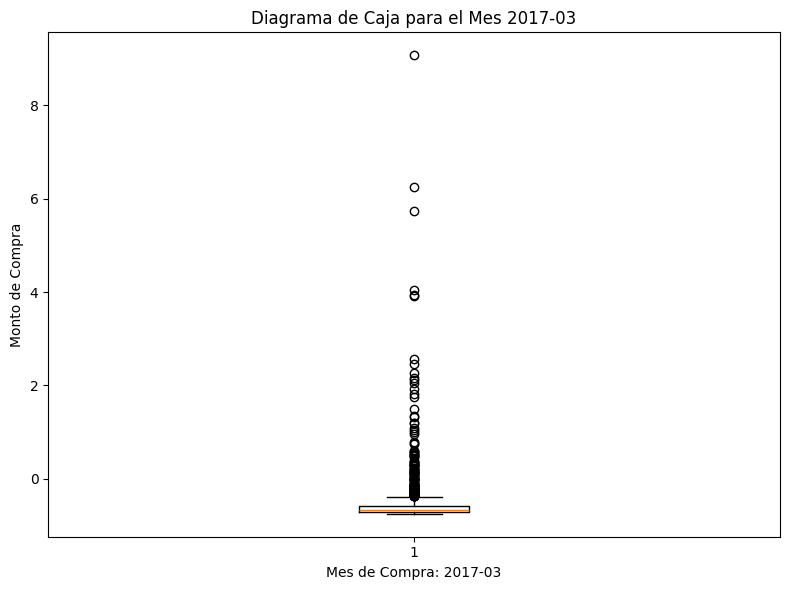

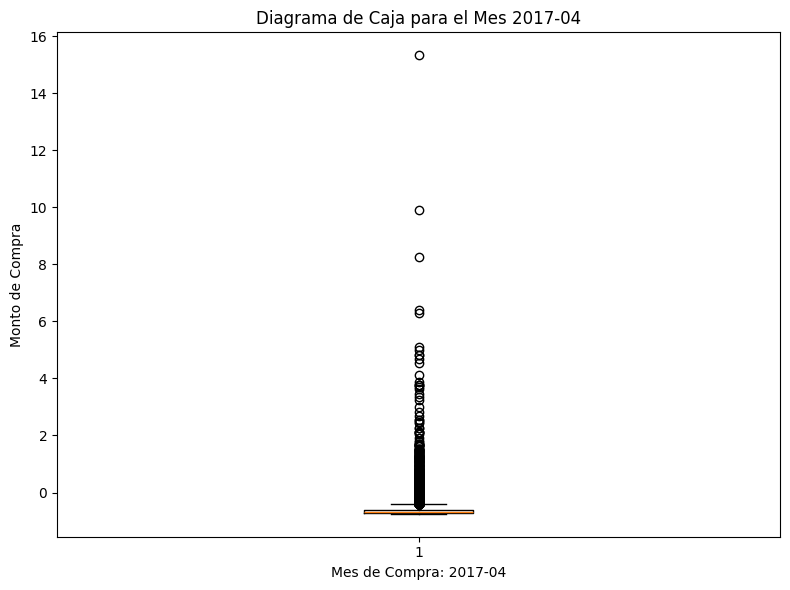

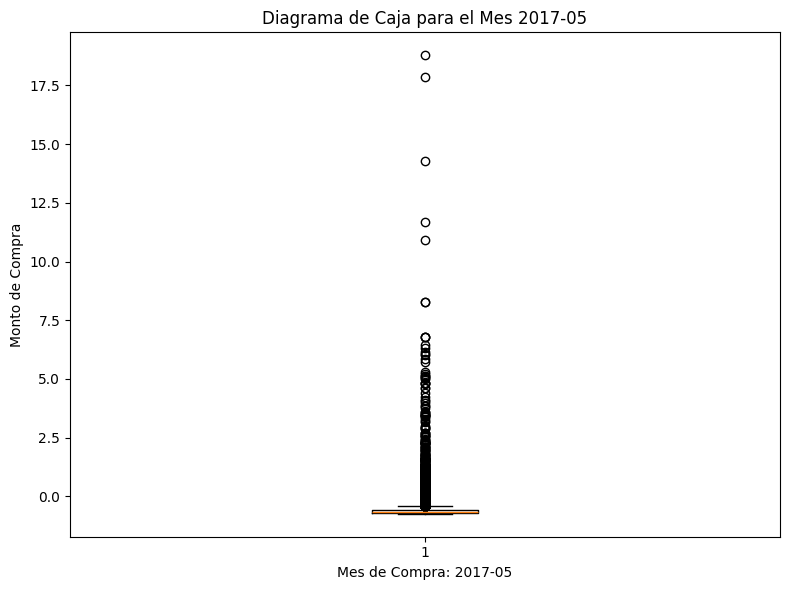

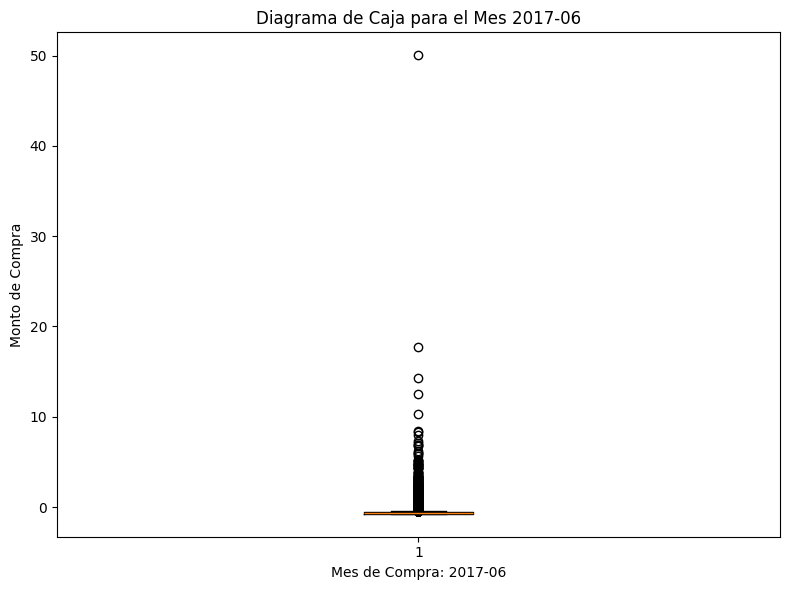

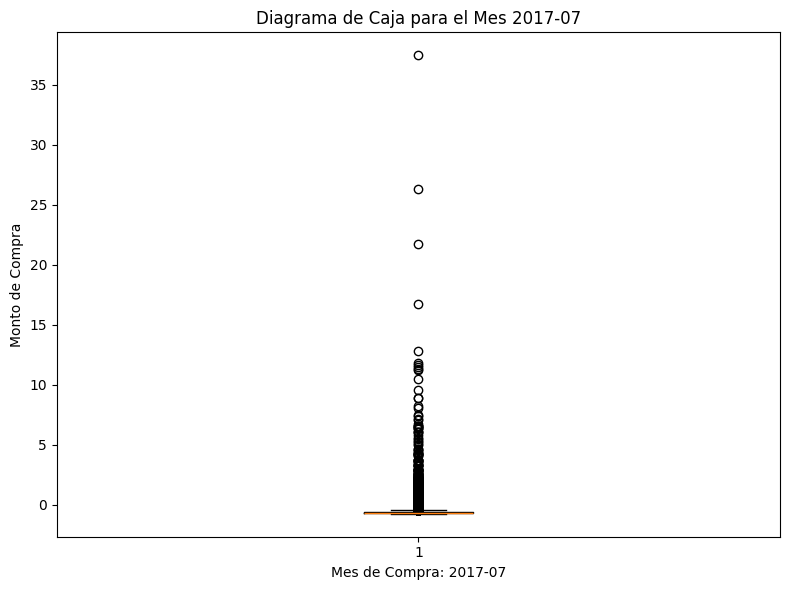

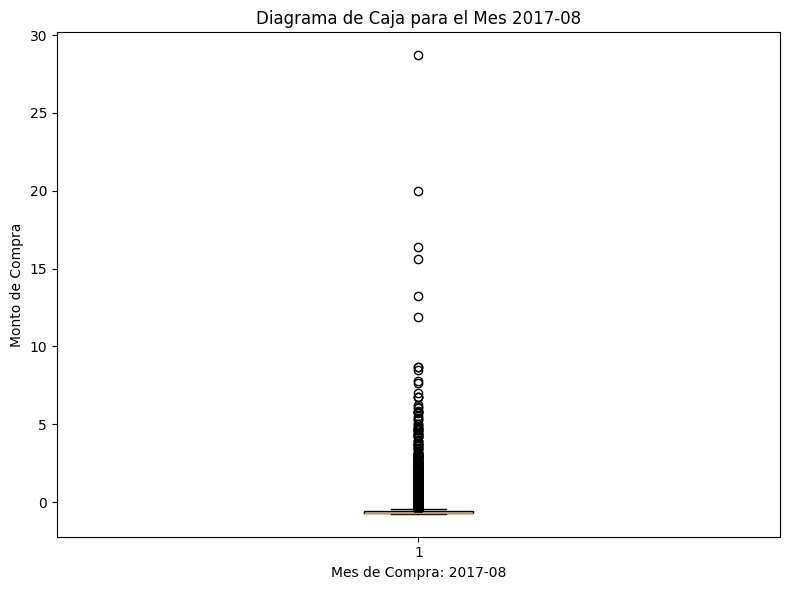

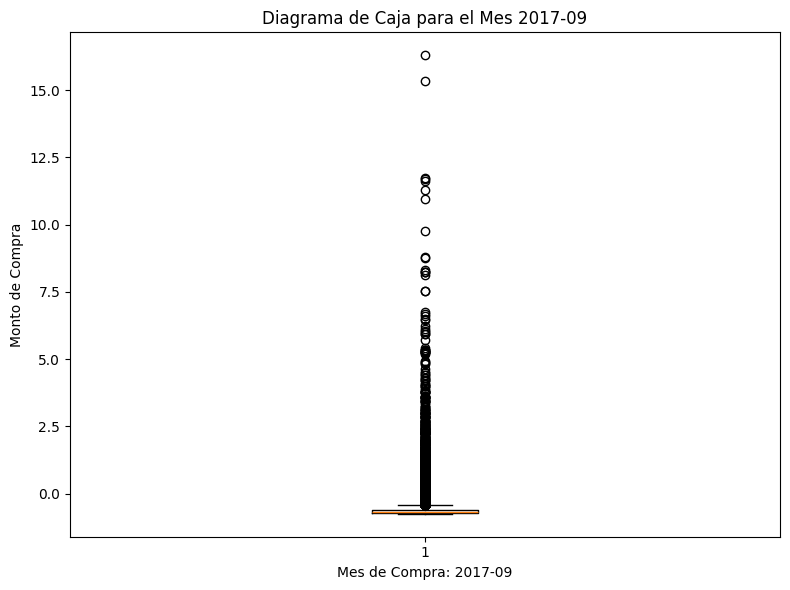

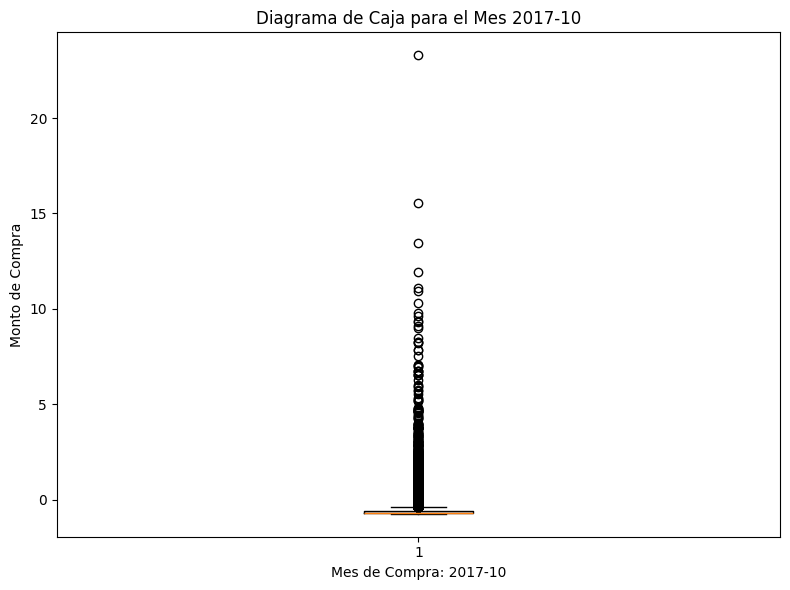

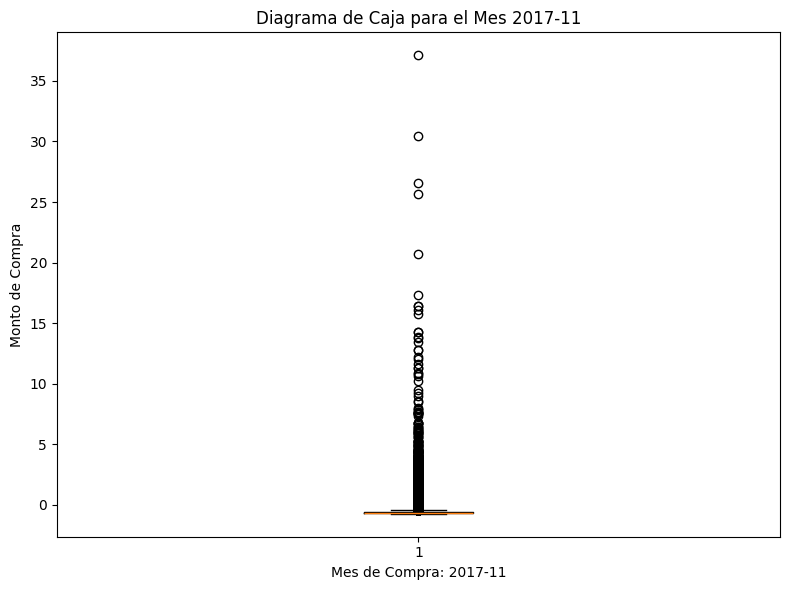

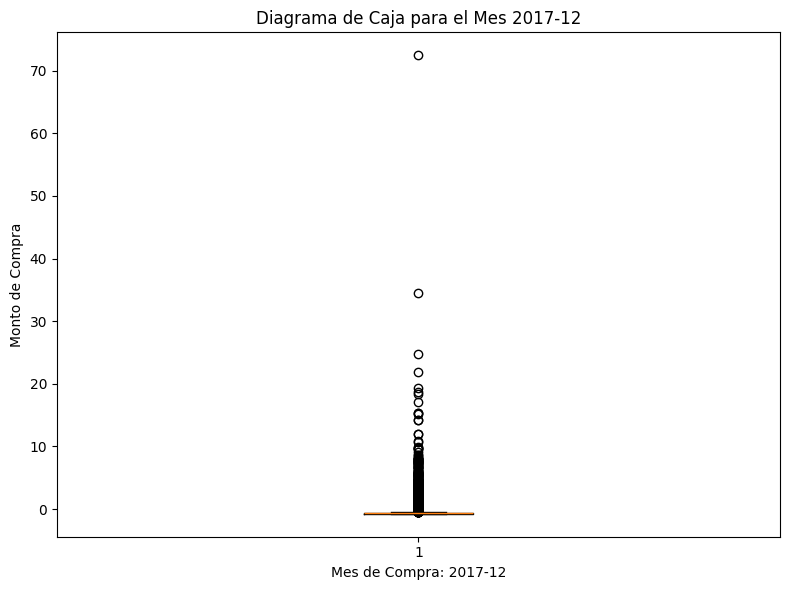

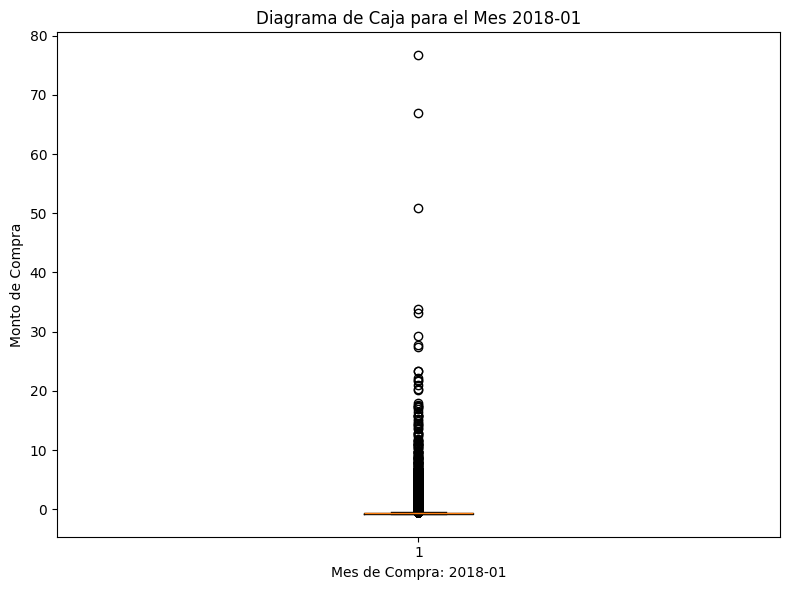

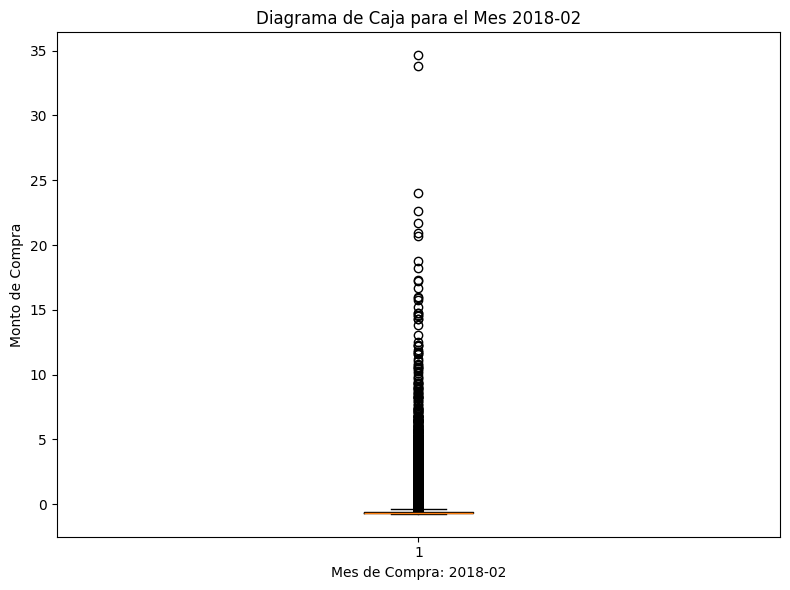

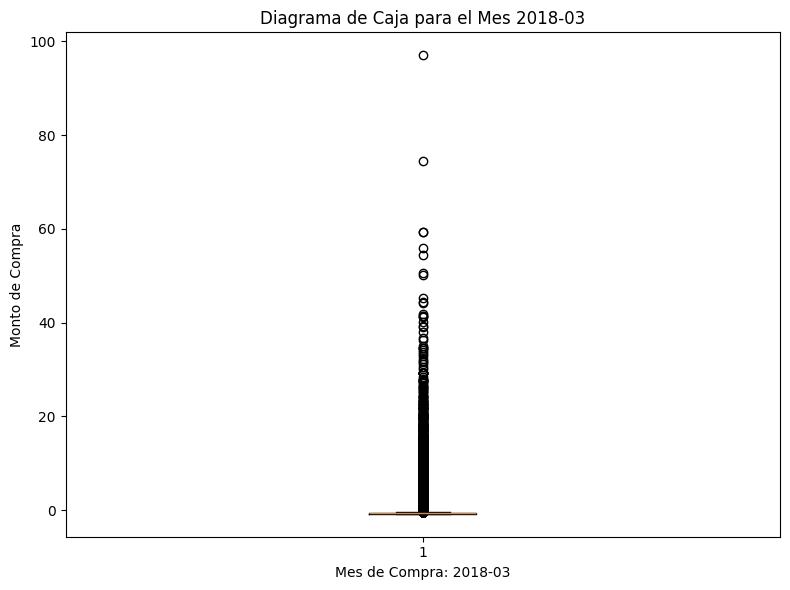

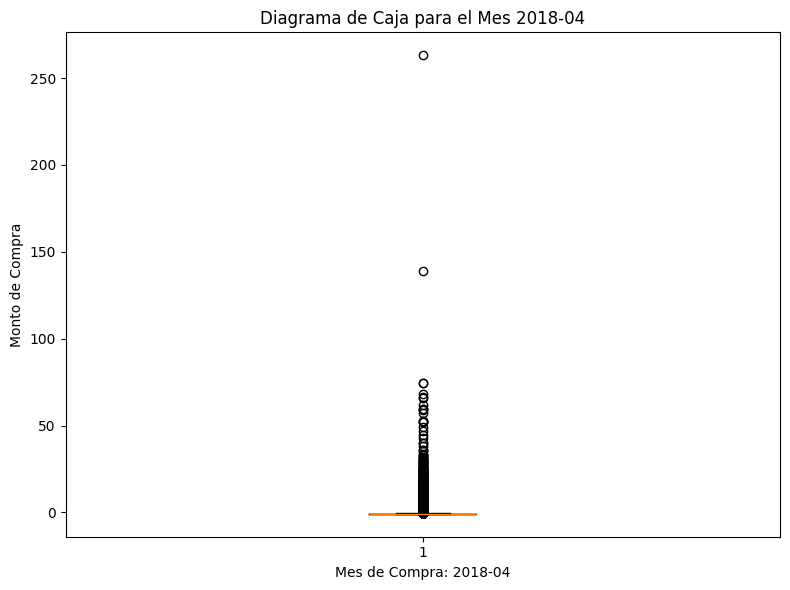

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import os

# Ruta de la carpeta con los archivos particionados
output_dir = "data/processed/new_merchant_transactions_partitioned"

# Obtener la lista de archivos Parquet en la carpeta
parquet_files = [f for f in os.listdir(output_dir) if f.endswith(".parquet")]

# Recorrer cada archivo Parquet
for parquet_file in parquet_files:
    # Leer el archivo Parquet
    file_path = os.path.join(output_dir, parquet_file)
    vdf_fila = pl.read_parquet(file_path)
    
    # Convertir a pandas para graficar
    df_pandas = vdf_fila.to_pandas()
    
    # Preparar los datos para el boxplot
    boxplot_data = df_pandas["purchase_amount"].tolist()
    
    # Crear el boxplot
    plt.figure(figsize=(8, 6))
    plt.boxplot(boxplot_data, showfliers=True, vert=True)
    
    # Extraer el nombre del mes desde el archivo
    purchase_month = parquet_file.split("=")[1].replace(".parquet", "")
    
    # Personalizar el gráfico
    plt.title(f"Diagrama de Caja para el Mes {purchase_month}")
    plt.xlabel(f"Mes de Compra: {purchase_month}")
    plt.ylabel("Monto de Compra")
    plt.tight_layout()
    
    # Mostrar el gráfico
    plt.show()

Se deberia juntar estas transacciones con las historicas, separarlo por fecha de corte y analizar el coportamiento por tarjeta o grupo de tarjetas

# Analisis Multivariado

In [ ]:
import polars as pl
import plotly.express as px

In [ ]:
vdf_hist_trx = pl.read_parquet("data/new_merchant_transactions.parquet").lazy()

In [ ]:
vdf_train = pl.read_parquet("data/train.parquet")

In [ ]:
# Haz que los valores que target de "desentadazricen", es decir que se vuelvan positivos para poder analizar su correlacion con feature1, feature2 y feature3
# No con absolute value, sino con el valor original,
epsilon = 1e-6  # Un pequeño valor para evitar división por cero
vdf_train_normal = vdf_train.with_columns(
    (pl.col("target") - pl.col("target").min() + epsilon).alias("target_positive")
)

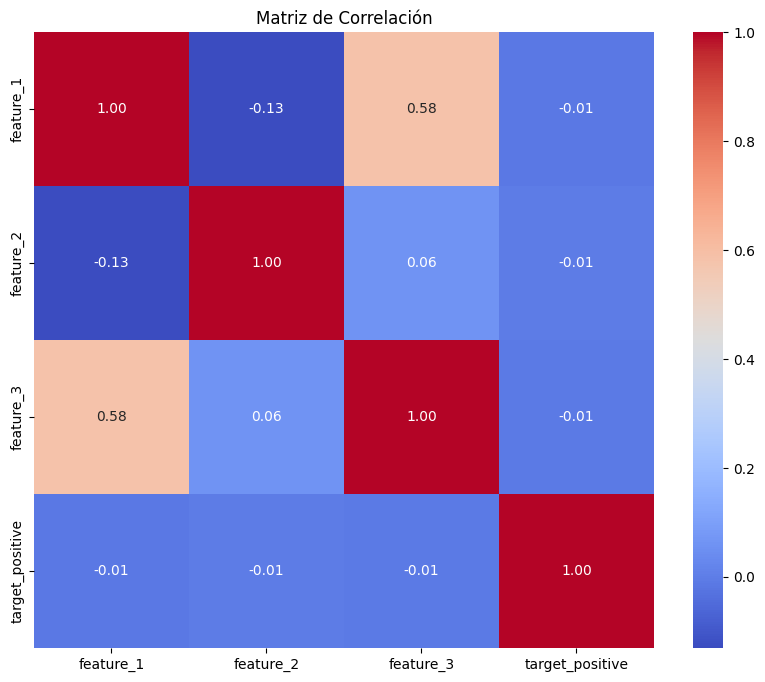

In [ ]:
continuous = [
    "feature_1", "feature_2", "feature_3", 
    "target_positive"
]
# Mapa de calor de correlacion de todas las variables continuas
vdf_continuous = vdf_train_normal.select(continuous)
# Convertir a pandas para calcular la correlación
df_continuous = vdf_continuous.to_pandas()
# Calcular la matriz de correlación
correlation_matrix = df_continuous.corr()
import matplotlib.pyplot as plt
import seaborn as sns
# Visualizar la matriz de correlación con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
# Media de target_positive por categoría de feature_1
mean_target_by_feature_1 = vdf_train_normal.group_by("feature_1").agg(
    pl.col("target_positive").mean().alias("mean_target_positive")
)
mean_target_by_feature_1

feature_1,mean_target_positive
i64,f64
1,32.903806
5,32.719403
2,32.86883
4,32.81463
3,32.841749


In [ ]:
# Media de target_positive por categoría de feature_1
mean_target_by_feature_2 = vdf_train_normal.group_by("feature_2").agg(
    pl.col("target_positive").mean().alias("mean_target_positive")
)
mean_target_by_feature_2

feature_2,mean_target_positive
i64,f64
3,32.717392
2,32.886383
1,32.820607


In [ ]:
# Media de target_positive por categoría de feature_1
mean_target_by_feature_3 = vdf_train_normal.group_by("feature_3").agg(
    pl.col("target_positive").mean().alias("mean_target_positive")
)
mean_target_by_feature_3

feature_3,mean_target_positive
i64,f64
1,32.798225
0,32.861343


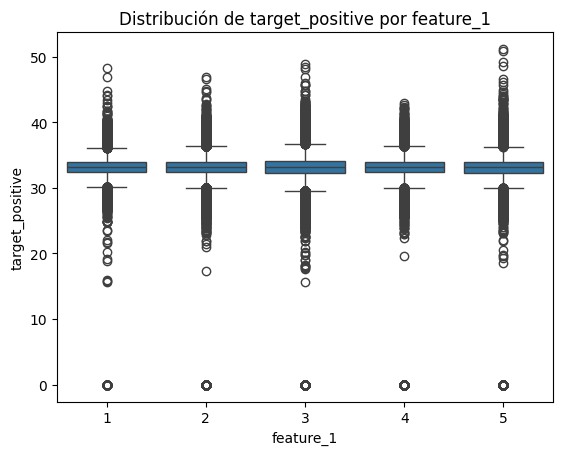

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot para feature_1
sns.boxplot(x="feature_1", y="target_positive", data=df_continuous)
plt.title("Distribución de target_positive por feature_1")
plt.show()

In [ ]:
vdf_merchants = pl.read_parquet("data/merchants.parquet")

In [ ]:
vdf_new_merchat_trx = pl.read_parquet("data/new_merchant_transactions.parquet").lazy()

In [ ]:
vdf_trx_total = vdf_hist_trx.collect().vstack(
    vdf_new_merchat_trx.collect()
)

In [ ]:
vdf_train_hist = vdf_train.join(
    vdf_trx_total,
    on="card_id",
    how="left"
)

In [ ]:
vdf_train_hist_merch = vdf_train_normal.join(
    vdf_trx_total,
    on="card_id",
    how="left"
).join(
    vdf_merchants,
    on="merchant_id",
    how="left"
)

In [ ]:
vdf_test_upper = vdf_train_hist_merch.filter(
    pl.col('target_positive') < 20
)

In [ ]:
vdf_test_upper

first_active_month,card_id,feature_1,feature_2,feature_3,target,target_positive,authorized_flag,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,merchant_group_id,merchant_category_id_right,subsector_id_right,numerical_1,numerical_2,category_1_right,most_recent_sales_range,most_recent_purchases_range,avg_sales_lag3,avg_purchases_lag3,active_months_lag3,avg_sales_lag6,avg_purchases_lag6,active_months_lag6,avg_sales_lag12,avg_purchases_lag12,active_months_lag12,category_4,city_id_right,state_id_right,category_2_right
str,str,i64,i64,i64,f64,f64,str,i64,str,i64,str,i64,str,i64,f64,str,f64,i64,i64,i64,i64,i64,f64,f64,str,str,str,f64,f64,i64,f64,f64,i64,f64,f64,i64,str,i64,i64,f64
"""2017-09""","""C_ID_8186f3fcc1""",3,1,1,-33.219281,0.000001,"""Y""",149,"""N""",1,"""B""",367,null,1,-0.701828,"""2018-03-10 22:51:58""",5.0,20,16,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2017-09""","""C_ID_8186f3fcc1""",3,1,1,-33.219281,0.000001,"""Y""",149,"""N""",1,"""B""",80,"""M_ID_fbaae334f0""",2,-0.682594,"""2018-04-23 20:55:01""",5.0,20,37,1348,80,37,-0.057471,-0.057471,"""N""","""D""","""D""",1.06,1.083523,3,1.59,1.460896,6,1.44,1.303287,7,"""N""",-1,20,5.0
"""2017-09""","""C_ID_8186f3fcc1""",3,1,1,-33.219281,0.000001,"""Y""",149,"""N""",1,"""B""",560,"""M_ID_b55158e29e""",2,-0.701152,"""2018-04-07 11:26:11""",5.0,20,34,89106,560,34,-0.057471,-0.057471,"""N""","""D""","""C""",1.0,0.98397,3,1.02,0.954994,6,0.89,0.83806,12,"""N""",-1,20,5.0
"""2017-09""","""C_ID_8186f3fcc1""",3,1,1,-33.219281,0.000001,"""Y""",149,"""N""",1,"""B""",130,"""M_ID_b3dc59a9a9""",1,-0.709342,"""2018-03-08 08:49:23""",5.0,20,41,35,130,41,12.772416,12.762501,"""N""","""B""","""B""",1.02,1.062803,3,1.04,1.093939,6,1.07,1.1113237,12,"""N""",-1,20,5.0
"""2017-09""","""C_ID_8186f3fcc1""",3,1,1,-33.219281,0.000001,"""Y""",288,"""N""",1,"""B""",80,"""M_ID_2d22260d5e""",1,-0.695818,"""2018-03-16 20:37:22""",5.0,20,37,3384,80,37,-0.057471,-0.057471,"""N""","""E""","""D""",1.19,1.113269,3,1.79,1.639159,6,1.88,1.763754,12,"""N""",288,20,5.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2016-08""","""C_ID_6f61bed11c""",3,3,1,-33.219281,0.000001,"""Y""",160,"""N""",1,"""B""",650,null,1,-0.664563,"""2017-10-26 00:00:00""",5.0,21,29,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2016-08""","""C_ID_6f61bed11c""",3,3,1,-33.219281,0.000001,"""Y""",160,"""N""",1,"""B""",683,"""M_ID_edc0990cd0""",2,-0.734346,"""2017-11-21 00:00:00""",5.0,21,34,35,683,34,5.643599,5.5246205,"""N""","""B""","""A""",1.08,1.088792,3,1.11,1.125703,6,1.2,1.220579,12,"""Y""",160,21,5.0
"""2016-08""","""C_ID_6f61bed11c""",3,3,1,-33.219281,0.000001,"""Y""",160,"""N""",1,"""B""",650,null,1,-0.664563,"""2017-10-26 00:00:00""",5.0,21,29,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [ ]:
print(vdf_test_upper.select(["target", "target_positive"]).describe())

shape: (9, 3)
┌────────────┬────────────┬─────────────────┐
│ statistic  ┆ target     ┆ target_positive │
│ ---        ┆ ---        ┆ ---             │
│ str        ┆ f64        ┆ f64             │
╞════════════╪════════════╪═════════════════╡
│ count      ┆ 15846.0    ┆ 15846.0         │
│ null_count ┆ 0.0        ┆ 0.0             │
│ mean       ┆ -33.219281 ┆ 0.000001        │
│ std        ┆ 8.0623e-16 ┆ 2.4028e-23      │
│ min        ┆ -33.219281 ┆ 0.000001        │
│ 25%        ┆ -33.219281 ┆ 0.000001        │
│ 50%        ┆ -33.219281 ┆ 0.000001        │
│ 75%        ┆ -33.219281 ┆ 0.000001        │
│ max        ┆ -33.219281 ┆ 0.000001        │
└────────────┴────────────┴─────────────────┘


In [ ]:
print(vdf_test_upper.select(["target", "target_positive"]).unique().height)

1


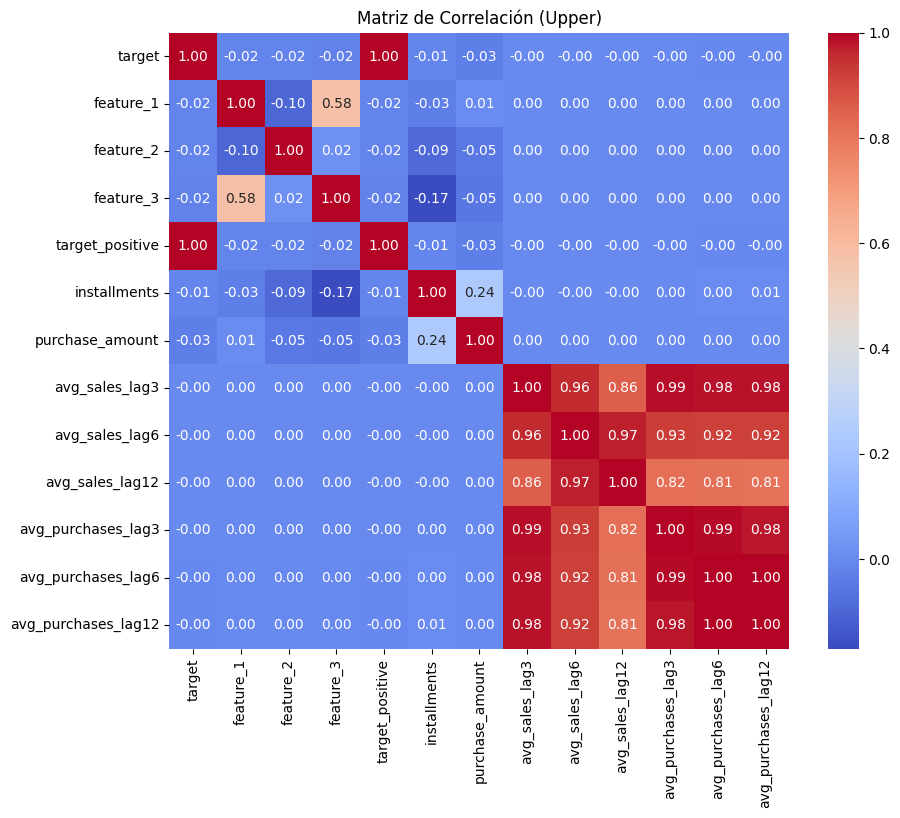

In [ ]:
# Extraccion de las columnas continuas
continuous = [
    "target", "feature_1", "feature_2", "feature_3", 
    "target_positive", "installments", "purchase_amount",
    "avg_sales_lag3", "avg_sales_lag6", "avg_sales_lag12",
    "avg_purchases_lag3", "avg_purchases_lag6", "avg_purchases_lag12"
]
# VIsualizar correlacion entre las variables continuas de upper
# Castear target a float64 para poder calcular la correlación
vdf_test_upper = vdf_train_hist_merch.with_columns(
    pl.col("target").cast(pl.Float64)
    , pl.col("target_positive").cast(pl.Float64)
)
vdf_test_upper_continuous = vdf_test_upper.select(continuous)
# Convertir a pandas para calcular la correlación
df_test_upper_continuous = vdf_test_upper_continuous.to_pandas()
# Calcular la matriz de correlación
correlation_matrix_upper = df_test_upper_continuous.corr()
# Visualizar la matriz de correlación con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_upper, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Upper)")
plt.show()

In [ ]:
correlation_matrix_upper_spearman = df_test_upper_continuous.corr(method='spearman')

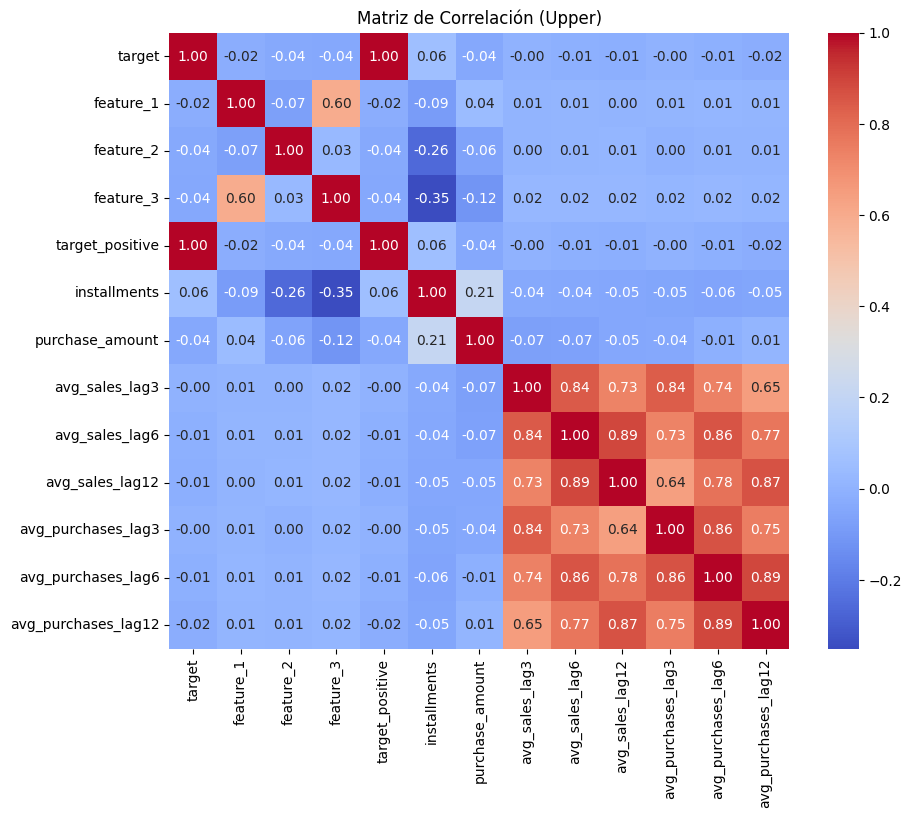

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_upper_spearman, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Upper)")
plt.show()

In [ ]:
# Calcular Q1, Q2 (mediana) y Q3
quartiles = vdf_train_hist_merch.select([
    pl.col("target").quantile(0.25).alias("q1"),
    pl.col("target").quantile(0.50).alias("q2"),
    pl.col("target").quantile(0.75).alias("q3")
])

q1 = quartiles[0, "q1"]
q2 = quartiles[0, "q2"]
q3 = quartiles[0, "q3"]

# Asignar cada tarjeta a un cuartil
vdf_with_quartiles = vdf_train_hist_merch.with_columns(
    pl.when(pl.col("target") <= q1).then(pl.lit("Q1"))
    .when((pl.col("target") > q1) & (pl.col("target") <= q2)).then(pl.lit("Q2"))
    .when((pl.col("target") > q2) & (pl.col("target") <= q3)).then(pl.lit("Q3"))
    .otherwise(pl.lit("Q4")).alias("quartile")
)

# Contar la cantidad de card_id únicos por cuartil
unique_card_count = vdf_with_quartiles.group_by("quartile").agg(
    pl.col("card_id").n_unique().alias("unique_card_count")
)

# Mostrar los resultados
unique_card_count

quartile,unique_card_count
str,u32
"""Q2""",40015
"""Q4""",71647
"""Q3""",44787
"""Q1""",45468


In [ ]:
# Calcular Q1, Q3 y el IQR
q1 = vdf_train_hist_merch["target_positive"].quantile(0.25)
q3 = vdf_train_hist_merch["target_positive"].quantile(0.75)
iqr = q3 - q1

# Definir límites para los outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filtrar los datos para eliminar outliers
vdf_filtered = vdf_train_hist_merch.filter(
    (pl.col("target_positive") >= lower_bound) & (pl.col("target_positive") <= upper_bound)
)

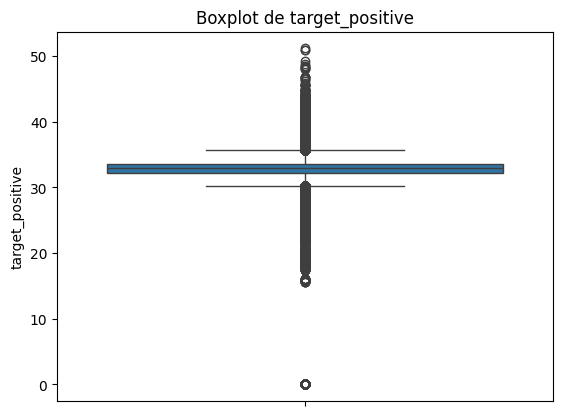

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un boxplot
sns.boxplot(y=vdf_train_hist_merch["target_positive"].to_pandas())
plt.title("Boxplot de target_positive")
plt.show()

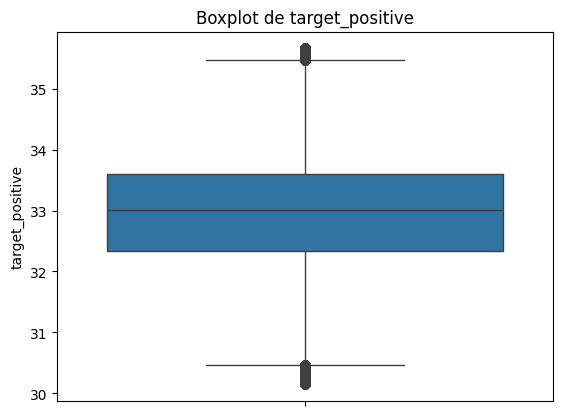

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un boxplot
sns.boxplot(y=vdf_filtered["target_positive"].to_pandas())
plt.title("Boxplot de target_positive")
plt.show()

In [ ]:
# Seleccionar columnas continuas
columns_to_correlate = [
    "target_positive", "purchase_amount", "installments",
    "avg_sales_lag3", "avg_sales_lag6", "avg_sales_lag12"
]

# Calcular correlación de Pearson
correlation_matrix_pearson = vdf_train_hist_merch.select(
    [pl.corr(pl.col(col1), pl.col(col2)).alias(f"{col1}_vs_{col2}")
     for col1 in columns_to_correlate
     for col2 in columns_to_correlate]
)

# Calcular correlación de Spearman
correlation_matrix_spearman = vdf_train_hist_merch.to_pandas()[columns_to_correlate].corr(method='spearman')

# Mostrar resultados
print("Correlación Pearson:")
print(correlation_matrix_pearson)

print("\nCorrelación Spearman:")
print(correlation_matrix_spearman)

Correlación Pearson:
shape: (1, 36)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ target_po ┆ target_po ┆ target_po ┆ target_po ┆ … ┆ avg_sales ┆ avg_sales ┆ avg_sales ┆ avg_sale │
│ sitive_vs ┆ sitive_vs ┆ sitive_vs ┆ sitive_vs ┆   ┆ _lag12_vs ┆ _lag12_vs ┆ _lag12_vs ┆ s_lag12_ │
│ _target_p ┆ _purchase ┆ _installm ┆ _avg_sale ┆   ┆ _installm ┆ _avg_sale ┆ _avg_sale ┆ vs_avg_s │
│ osi…      ┆ _am…      ┆ ent…      ┆ s_l…      ┆   ┆ ent…      ┆ s_l…      ┆ s_l…      ┆ ales_l…  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ -0.030035 ┆ -0.011735 ┆ -0.000839 ┆ … ┆ -0.00062  ┆ 0.85705   ┆ 0.969635  ┆ 1.0      │
└───────────┴───────────┴───────────┴───────────┴───┴──

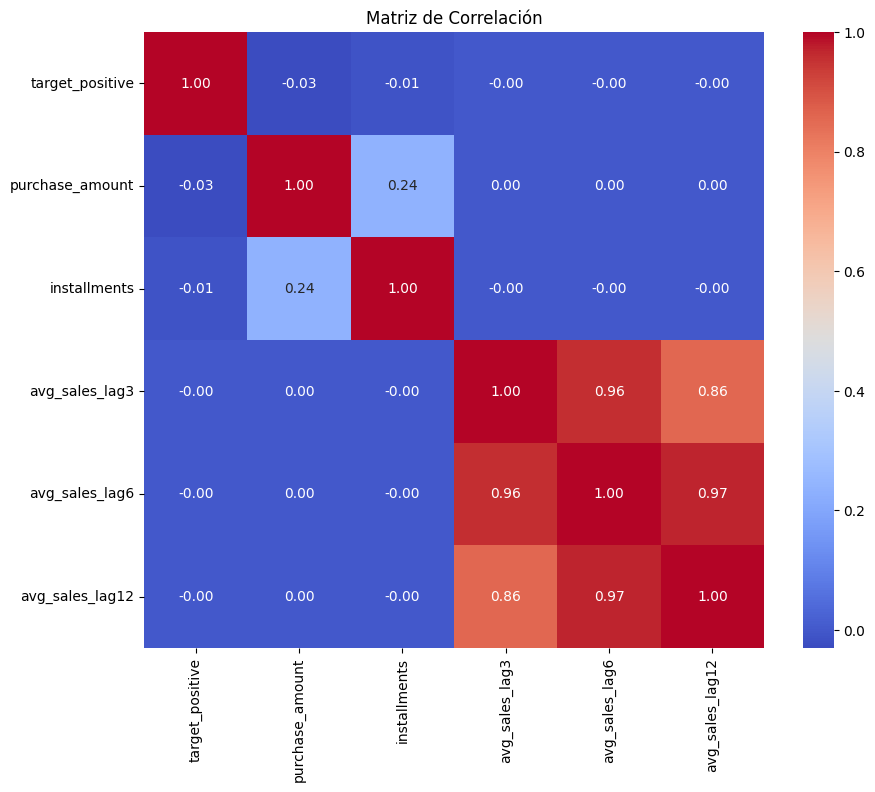

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir a pandas para visualización
df_pandas = vdf_train_hist_merch.select(columns_to_correlate).to_pandas()

# Calcular matriz de correlación
correlation_matrix = df_pandas.corr()

# Crear un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
# Agrupar por cuartil y calcular correlación
vdf_segmented = vdf_train_hist_merch.with_columns(
    pl.when(pl.col("target") <= q1).then(pl.lit("Q1"))
    .when((pl.col("target") > q1) & (pl.col("target") <= q2)).then(pl.lit("Q2"))
    .when((pl.col("target") > q2) & (pl.col("target") <= q3)).then(pl.lit("Q3"))
    .otherwise(pl.lit("Q4")).alias("quartile")
)

# Calcular la correlación por cuartil
vdf_segmented = vdf_with_quartiles.group_by("quartile").agg(
    pl.corr("purchase_amount", "target_positive").alias("corr_purchase_target"),
    pl.corr("installments", "target_positive").alias("corr_installments_target"),
    pl.corr("avg_sales_lag3", "target_positive").alias("corr_avg_sales_lag3_target"),
    pl.corr("avg_sales_lag6", "target_positive").alias("corr_avg_sales_lag6_target"),
    pl.corr("avg_sales_lag12", "target_positive").alias("corr_avg_sales_lag12_target")
)

# Mostrar los resultados
print(vdf_segmented)

shape: (4, 6)
┌──────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┐
│ quartile ┆ corr_purchase_t ┆ corr_installmen ┆ corr_avg_sales_ ┆ corr_avg_sales ┆ corr_avg_sales │
│ ---      ┆ arget           ┆ ts_target       ┆ lag3_target     ┆ _lag6_target   ┆ _lag12_target  │
│ str      ┆ ---             ┆ ---             ┆ ---             ┆ ---            ┆ ---            │
│          ┆ f64             ┆ f64             ┆ f64             ┆ f64            ┆ f64            │
╞══════════╪═════════════════╪═════════════════╪═════════════════╪════════════════╪════════════════╡
│ Q1       ┆ 0.000556        ┆ -0.031611       ┆ -0.000995       ┆ -0.000783      ┆ -0.000546      │
│ Q3       ┆ -0.010694       ┆ 0.002259        ┆ 0.000752        ┆ 0.000941       ┆ 0.001038       │
│ Q2       ┆ -0.018815       ┆ 0.006252        ┆ -0.000102       ┆ 0.000066       ┆ 0.000112       │
│ Q4       ┆ -0.038407       ┆ -0.039161       ┆ -0.002738       ┆ -0.00273  

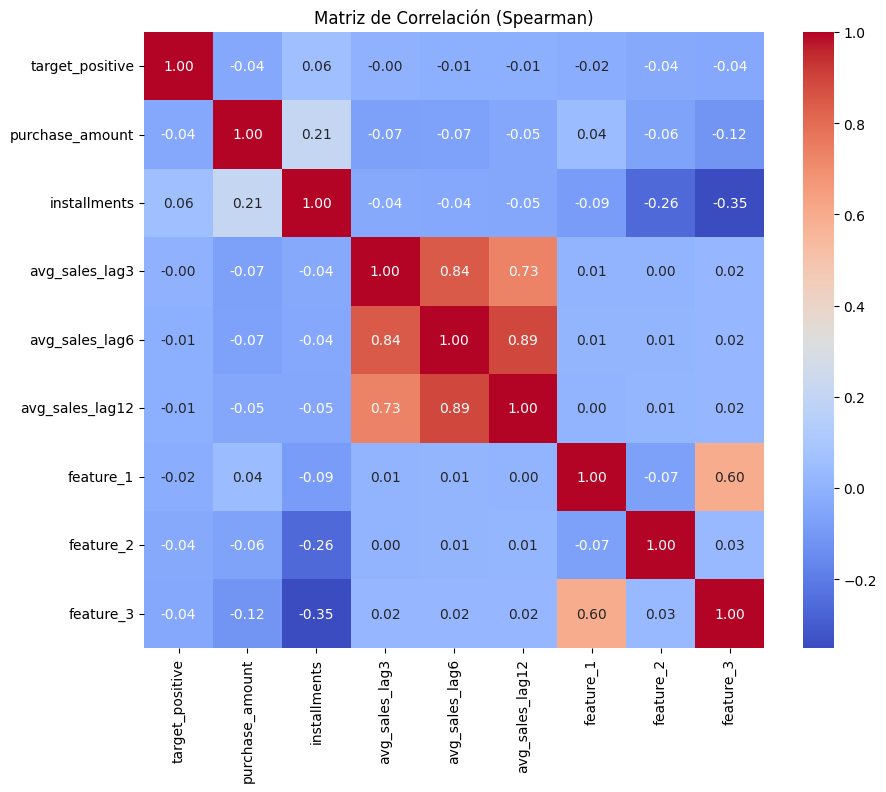

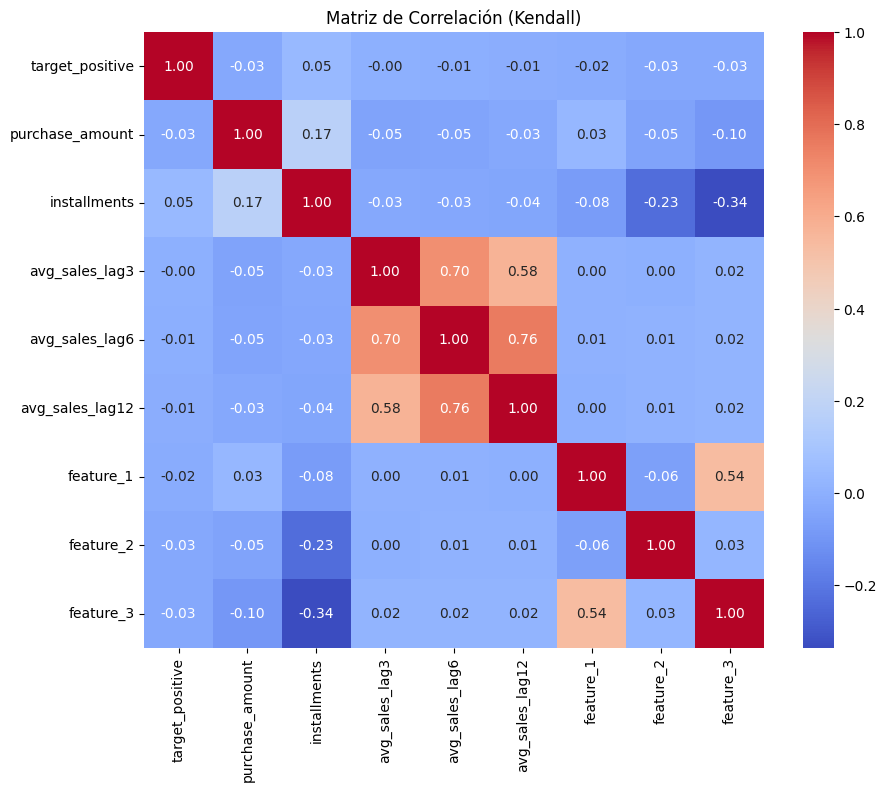

In [ ]:
# Seleccionar columnas continuas
columns_to_correlate = [
    "target_positive", "purchase_amount", "installments",
    "avg_sales_lag3", "avg_sales_lag6", "avg_sales_lag12",
    "feature_1", "feature_2", "feature_3"
]

# Calcular correlación de Spearman
correlation_matrix_spearman = vdf_train_hist_merch.to_pandas()[columns_to_correlate].corr(method='spearman')

# Calcular correlación de Kendall
correlation_matrix_kendall = vdf_train_hist_merch.to_pandas()[columns_to_correlate].corr(method='kendall')

# Visualizar las matrices
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_spearman, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Spearman)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_kendall, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Kendall)")
plt.show()

In [ ]:
vdf_train_hist_merch.height

2501101

In [ ]:
vdf_filtered.height

2340147

In [ ]:
# Calcular los percentiles
lower_bound = vdf_train_hist_merch["target_positive"].quantile(0.01)
upper_bound = vdf_train_hist_merch["target_positive"].quantile(0.99)

# Filtrar los datos para eliminar outliers
vdf_filtered = vdf_train_hist_merch.filter(
    (pl.col("target_positive") >= lower_bound) & (pl.col("target_positive") <= upper_bound)
)

In [ ]:
vdf_filtered.height

2451085

In [ ]:
# Calcular la media y la desviación estándar
mean = vdf_train_hist_merch["target_positive"].mean()
std_dev = vdf_train_hist_merch["target_positive"].std()

# Definir límites para los outliers (por ejemplo, 3 desviaciones estándar)
lower_bound = mean - 3 * std_dev
upper_bound = mean + 3 * std_dev

# Filtrar los datos para eliminar outliers
vdf_filtered = vdf_train_hist_merch.filter(
    (pl.col("target_positive") >= lower_bound) & (pl.col("target_positive") <= upper_bound)
)

In [ ]:
vdf_filtered.height

2484169

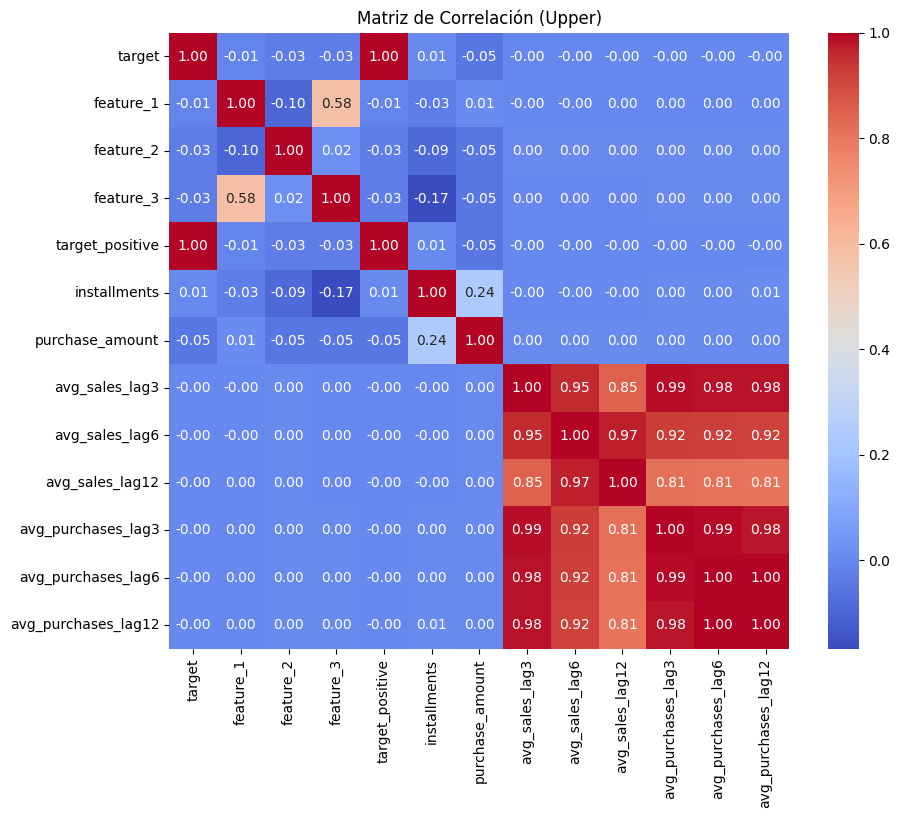

In [ ]:
# Extraccion de las columnas continuas
continuous = [
    "target", "feature_1", "feature_2", "feature_3", 
    "target_positive", "installments", "purchase_amount",
    "avg_sales_lag3", "avg_sales_lag6", "avg_sales_lag12",
    "avg_purchases_lag3", "avg_purchases_lag6", "avg_purchases_lag12"
]
# VIsualizar correlacion entre las variables continuas de upper
# Castear target a float64 para poder calcular la correlación
vdf_test_upper = vdf_filtered.with_columns(
    pl.col("target").cast(pl.Float64)
    , pl.col("target_positive").cast(pl.Float64)
)
vdf_test_upper_continuous = vdf_test_upper.select(continuous)
# Convertir a pandas para calcular la correlación
df_test_upper_continuous = vdf_test_upper_continuous.to_pandas()
# Calcular la matriz de correlación
correlation_matrix_upper = df_test_upper_continuous.corr()
# Visualizar la matriz de correlación con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_upper, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Upper)")
plt.show()

In [ ]:
vdf_train_hist_merch.filter(
    pl.col('target_positive') > 45
).head()

first_active_month,card_id,feature_1,feature_2,feature_3,target,target_positive,authorized_flag,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,merchant_group_id,merchant_category_id_right,subsector_id_right,numerical_1,numerical_2,category_1_right,most_recent_sales_range,most_recent_purchases_range,avg_sales_lag3,avg_purchases_lag3,active_months_lag3,avg_sales_lag6,avg_purchases_lag6,active_months_lag6,avg_sales_lag12,avg_purchases_lag12,active_months_lag12,category_4,city_id_right,state_id_right,category_2_right
str,str,i64,i64,i64,f64,f64,str,i64,str,i64,str,i64,str,i64,f64,str,f64,i64,i64,i64,i64,i64,f64,f64,str,str,str,f64,f64,i64,f64,f64,i64,f64,f64,i64,str,i64,i64,f64
"""2017-05""","""C_ID_700c15a07d""",3,2,1,15.606405,48.825687,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2017-01""","""C_ID_1c8a5b9d44""",5,1,1,17.675716,50.894998,"""Y""",212,"""N""",1,"""B""",427,"""M_ID_32e96ddff1""",2,-0.746893,"""2018-04-30 12:11:04""",4.0,4,27,35,427,27,3.422661,3.383001,"""N""","""B""","""C""",1.04,1.046242,3,1.07,1.072892,6,1.19,1.19371,12,"""Y""",212,4,4.0
"""2017-01""","""C_ID_1c8a5b9d44""",5,1,1,17.675716,50.894998,"""Y""",212,"""N""",1,"""B""",427,"""M_ID_32e96ddff1""",2,-0.746893,"""2018-04-30 12:11:04""",4.0,4,27,35,427,27,3.422661,3.383001,"""N""","""B""","""C""",1.04,1.046242,3,1.07,1.072892,6,1.19,1.19371,12,"""Y""",212,4,4.0
"""2017-08""","""C_ID_1b28c8af6b""",3,2,1,14.85516,48.074442,"""Y""",-1,"""Y""",0,"""A""",661,"""M_ID_fc7d7969c3""",2,-0.746893,"""2018-04-18 15:10:11""",null,-1,8,104706,661,8,-0.057471,-0.057471,"""Y""","""A""","""A""",0.88,0.890464,3,0.72,0.737107,6,0.56,0.585596,12,"""Y""",-1,-1,null
"""2017-08""","""C_ID_1b28c8af6b""",3,2,1,14.85516,48.074442,"""Y""",-1,"""Y""",0,"""A""",661,"""M_ID_fc7d7969c3""",2,-0.746893,"""2018-04-18 15:10:11""",null,-1,8,104706,661,8,-0.057471,-0.057471,"""Y""","""A""","""A""",0.88,0.890464,3,0.72,0.737107,6,0.56,0.585596,12,"""Y""",-1,-1,null


In [ ]:
vdf_train_hist

first_active_month,card_id,feature_1,feature_2,feature_3,target,authorized_flag,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
str,str,i64,i64,i64,f64,str,i64,str,i64,str,i64,str,i64,f64,str,f64,i64,i64
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,"""Y""",19,"""N""",0,"""A""",80,"""M_ID_98b342c0e3""",1,-0.491457,"""2018-03-30 10:30:32""",1.0,9,37
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,"""Y""",69,"""N""",0,"""A""",80,"""M_ID_28a21ea733""",2,-0.666561,"""2018-04-06 10:55:08""",1.0,9,37
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,"""Y""",19,"""N""",0,"""A""",278,"""M_ID_20dce166b9""",1,-0.635246,"""2018-03-29 15:38:10""",1.0,9,37
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,"""Y""",69,"""N""",0,"""A""",842,"""M_ID_f7796994d1""",2,-0.58118,"""2018-04-09 13:56:50""",1.0,9,37
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,"""Y""",276,"""N""",0,"""A""",783,"""M_ID_0703c10cc0""",1,-0.296112,"""2018-03-12 16:49:03""",1.0,9,19
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2017-07""","""C_ID_92c9984c58""",3,1,1,-1.859413,"""Y""",25,"""N""",1,"""B""",705,"""M_ID_87bea2720d""",2,-0.664878,"""2018-04-30 14:04:26""",3.0,7,33
"""2017-07""","""C_ID_92c9984c58""",3,1,1,-1.859413,"""Y""",25,"""N""",-1,null,884,"""M_ID_62664cd0ae""",2,-0.326316,"""2018-04-27 15:11:46""",3.0,7,27
"""2017-07""","""C_ID_92c9984c58""",3,1,1,-1.859413,"""Y""",25,"""N""",-1,null,506,"""M_ID_19dc835856""",1,0.081323,"""2018-03-25 12:11:27""",3.0,7,30


In [ ]:
# Definir un pequeño valor constante para evitar ceros
epsilon = 1e-6

# Reemplazar valores nulos en purchase_amount con 0
vdf_train_hist = vdf_train_hist.with_columns(
    pl.col("purchase_amount").fill_null(0).alias("purchase_amount_filled")
)

# Transformar purchase_amount y target a valores positivos manteniendo la escala
vdf_train_hist_scaled = vdf_train_hist.with_columns(
    (pl.col("purchase_amount_filled") - pl.col("purchase_amount_filled").min() + epsilon).alias("purchase_amount_positive"),
    (pl.col("target") - pl.col("target").min() + epsilon).alias("target_positive")
)

# Verificar los cambios
vdf_train_hist_scaled.sort(
    "card_id", descending=True
).head()

first_active_month,card_id,feature_1,feature_2,feature_3,target,authorized_flag,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,purchase_amount_filled,purchase_amount_positive,target_positive
str,str,i64,i64,i64,f64,str,i64,str,i64,str,i64,str,i64,f64,str,f64,i64,i64,f64,f64,f64
"""2017-08""","""C_ID_fffffd5772""",2,1,0,-1.073077,"""Y""",20,"""N""",1,"""B""",705,"""M_ID_bbc64a7bd8""",1,-0.733985,"""2018-03-02 16:23:47""",3.0,19,33,-0.733985,0.012909,32.146205
"""2017-08""","""C_ID_fffffd5772""",2,1,0,-1.073077,"""Y""",20,"""N""",1,"""B""",367,"""M_ID_1208576963""",1,-0.665765,"""2018-03-27 13:45:10""",3.0,19,16,-0.665765,0.081129,32.146205
"""2017-08""","""C_ID_fffffd5772""",2,1,0,-1.073077,"""Y""",20,"""N""",1,"""B""",360,"""M_ID_c613085a2f""",1,-0.72572,"""2018-03-02 18:14:05""",3.0,19,34,-0.72572,0.021173,32.146205
"""2017-08""","""C_ID_fffffd5772""",2,1,0,-1.073077,"""Y""",20,"""N""",1,"""B""",705,"""M_ID_bbc64a7bd8""",1,-0.733985,"""2018-03-02 16:23:47""",3.0,19,33,-0.733985,0.012909,32.146205
"""2017-08""","""C_ID_fffffd5772""",2,1,0,-1.073077,"""Y""",20,"""N""",1,"""B""",367,"""M_ID_1208576963""",1,-0.665765,"""2018-03-27 13:45:10""",3.0,19,16,-0.665765,0.081129,32.146205


In [ ]:
vdf_train_hist_scaled_by_card = vdf_train_hist_scaled.select(
    pl.col("card_id"),
    pl.col("purchase_amount_positive"),
    pl.col("target_positive"),
    pl.col("purchase_date").str.slice(0, 7).alias("purchase_date")
).with_columns(
    pl.col("purchase_date").is_null().alias("is_null_date")  # Indicador de fechas nulas
).group_by("card_id", "target_positive", "purchase_date", 'is_null_date').agg(
    pl.col("purchase_amount_positive").sum().alias("total_purchase_amount"),
    pl.col("card_id").count().alias("total_transactions")
).sort("card_id")

In [ ]:
vdf_train_hist_scaled_by_card = vdf_train_hist_scaled_by_card.with_columns(
    pl.col("purchase_date").fill_null("Sin actividad").alias("purchase_date_filled")
)

In [ ]:
# Crear ventanas temporales
vdf_with_dates = vdf_train_hist_scaled_by_card.filter(~pl.col("is_null_date"))

# Agregar métricas por ventana temporal (por ejemplo, mensual)
vdf_time_windows = vdf_with_dates.with_columns(
    pl.col("purchase_date").str.slice(0, 7).alias("month")
).group_by(["card_id", "month"]).agg([
    pl.col("total_purchase_amount").sum().alias("monthly_purchase_amount"),
    pl.col("total_transactions").sum().alias("monthly_transactions")
])

# Calcular la correlación entre las métricas mensuales y el target
vdf_correlation = vdf_time_windows.join(
    vdf_train_hist_scaled_by_card.select(["card_id", "target_positive"]),
    on="card_id",
    how="left"
).select([
    pl.corr("monthly_purchase_amount", "target_positive").alias("corr_purchase_amount"),
    pl.corr("monthly_transactions", "target_positive").alias("corr_transactions")
])

vdf_correlation

corr_purchase_amount,corr_transactions
f64,f64
-0.058293,-0.039347


#### Analasis por variaciones de tiempo totales

In [ ]:
vdf_with_dates = vdf_train_hist_scaled_by_card.filter(~pl.col("is_null_date"))

vdf_with_dates = vdf_with_dates.sort(["card_id", "purchase_date"]).with_columns([
    (pl.col("total_purchase_amount") - pl.col("total_purchase_amount").shift(1)).over("card_id").alias("purchase_amount_diff"),
    (pl.col("total_transactions") - pl.col("total_transactions").shift(1)).over("card_id").alias("transactions_diff"),
    ((pl.col("total_purchase_amount") - pl.col("total_purchase_amount").shift(1)) / pl.col("total_purchase_amount").shift(1)).over("card_id").alias("purchase_amount_pct_change"),
    ((pl.col("total_transactions") - pl.col("total_transactions").shift(1)) / pl.col("total_transactions").shift(1)).over("card_id").alias("transactions_pct_change")
])

In [ ]:
vdf_null_dates_stats = vdf_train_hist_scaled_by_card.filter(pl.col("is_null_date")).select([
    pl.col("target_positive").mean().alias("avg_target_positive_null_dates"),
    pl.col("total_purchase_amount").mean().alias("avg_purchase_amount_null_dates")
])

In [ ]:
vdf_final = vdf_train_hist_scaled_by_card.join(vdf_with_dates, on="card_id", how="left")

In [ ]:
from scipy.stats import linregress

# Calcular la tendencia (pendiente) de las transacciones para cada tarjeta
def calculate_trend(df):
    slopes = []
    for card_id, group in df.groupby("card_id"):
        group = group.sort_values("purchase_date")
        slope, _, _, _, _ = linregress(range(len(group)), group["total_purchase_amount"])
        slopes.append({"card_id": card_id, "slope": slope})
    return pd.DataFrame(slopes)

# Convertir a pandas y calcular la tendencia
df_pandas = vdf_with_dates.to_pandas()
trend_df = calculate_trend(df_pandas)

# Unir con el target y calcular la correlación
trend_df = trend_df.merge(vdf_train_hist_scaled_by_card.to_pandas()[["card_id", "target_positive"]], on="card_id")
correlation = trend_df["slope"].corr(trend_df["target_positive"])
print(f"Correlación entre la tendencia y el target: {correlation}")

c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\scipy\stats\_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\scipy\stats\_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\scipy\stats\_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


Correlación entre la tendencia y el target: 0.013054839903872309


In [ ]:
# Calcular cambios relativos
vdf_with_changes = vdf_with_dates.with_columns([
    ((pl.col("total_purchase_amount") - pl.col("total_purchase_amount").shift(1)) / pl.col("total_purchase_amount").shift(1)).over("card_id").alias("purchase_amount_pct_change"),
    ((pl.col("total_transactions") - pl.col("total_transactions").shift(1)) / pl.col("total_transactions").shift(1)).over("card_id").alias("transactions_pct_change")
])

# Calcular la correlación con el target
vdf_correlation_changes = vdf_with_changes.join(
    vdf_train_hist_scaled_by_card.select(["card_id", "target_positive"]),
    on="card_id",
    how="left"
).select([
    pl.corr("purchase_amount_pct_change", "target_positive").alias("corr_purchase_pct_change"),
    pl.corr("transactions_pct_change", "target_positive").alias("corr_transactions_pct_change")
])

print(vdf_correlation_changes)

shape: (1, 2)
┌──────────────────────────┬──────────────────────────────┐
│ corr_purchase_pct_change ┆ corr_transactions_pct_change │
│ ---                      ┆ ---                          │
│ f64                      ┆ f64                          │
╞══════════════════════════╪══════════════════════════════╡
│ 0.001393                 ┆ 0.008469                     │
└──────────────────────────┴──────────────────────────────┘


In [ ]:
# Crear segmentos basados en el monto promedio de compra
vdf_segments = vdf_with_dates.group_by("card_id").agg(
    pl.col("total_purchase_amount").mean().alias("avg_purchase_amount")
).with_columns(
    pl.when(pl.col("avg_purchase_amount") < 50).then(pl.lit("Very Low spender"))
    .when(pl.col("avg_purchase_amount") < 100).then(pl.lit("Low spender"))
    .when(pl.col("avg_purchase_amount") < 500).then(pl.lit("Medium spender"))
    .otherwise(pl.lit("High spender")).alias("spending_segment")
)

# Calcular el target promedio por segmento
vdf_segment_analysis = vdf_segments.join(
    vdf_train_hist_scaled_by_card.select(["card_id", "target_positive"]),
    on="card_id",
    how="left"
).group_by("spending_segment").agg(
    pl.col("target_positive").mean().alias("avg_target")
    , pl.col('card_id').n_unique().alias("cards_unique")  # Contar el número de tarjetas en cada segmento
)

In [ ]:
vdf_segment_analysis

spending_segment,avg_target,cards_unique
str,f64,u32
"""Very Low spender""",32.759069,179930
"""Low spender""",30.898724,53
"""Medium spender""",30.123814,3


In [ ]:
vdf_correlation_by_segment = vdf_segments.join(
    vdf_train_hist_scaled_by_card.select(["card_id", "target_positive"]),
    on="card_id",
    how="left"
).group_by("spending_segment").agg(
    pl.corr("avg_purchase_amount", "target_positive").alias("corr_avg_purchase_target")
)
print(vdf_correlation_by_segment)

shape: (3, 2)
┌──────────────────┬──────────────────────────┐
│ spending_segment ┆ corr_avg_purchase_target │
│ ---              ┆ ---                      │
│ str              ┆ f64                      │
╞══════════════════╪══════════════════════════╡
│ Medium spender   ┆ 0.621101                 │
│ Low spender      ┆ -0.081581                │
│ Very Low spender ┆ -0.073335                │
└──────────────────┴──────────────────────────┘


In [ ]:
correlation_matrix = vdf_final.select(
    pl.corr("purchase_amount_diff", "target_positive").alias("purchase_amount_diff_vs_target"),
    pl.corr("transactions_diff", "target_positive").alias("transactions_diff_vs_target")
)

In [ ]:
correlation_matrix

purchase_amount_diff_vs_target,transactions_diff_vs_target
f64,f64
0.013055,-0.036526


In [ ]:
columns_to_correlate = [
    "purchase_amount_diff",
    "transactions_diff",
    "purchase_amount_pct_change",
    "transactions_pct_change"
]

In [ ]:
vdf_pandas = vdf_final.to_pandas()

In [ ]:
correlation_matrix = vdf_pandas[columns_to_correlate].corr()

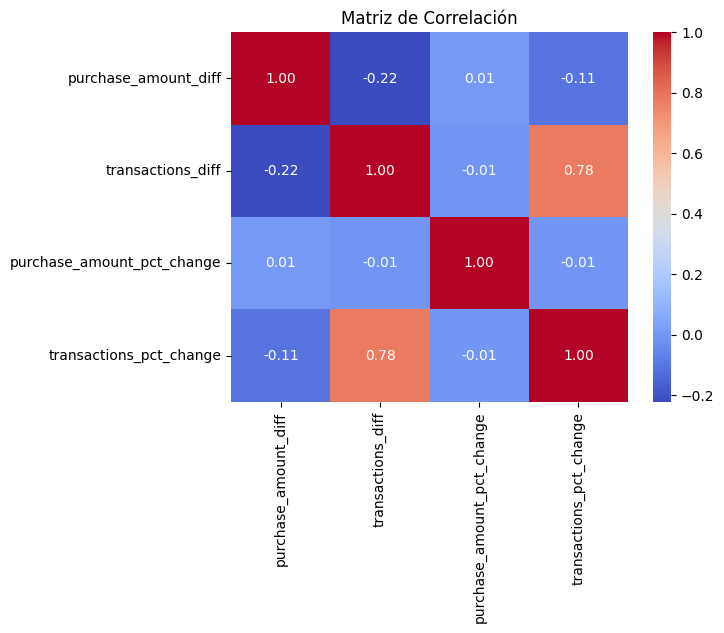

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
vdf_with_dates

card_id,target_positive,purchase_date,is_null_date,total_purchase_amount,total_transactions,purchase_date_filled,purchase_amount_diff,transactions_diff,purchase_amount_pct_change,transactions_pct_change
str,f64,str,bool,f64,u32,str,f64,u32,f64,f64
"""C_ID_00007093c1""",33.353359,"""2018-04""",false,0.330527,4,"""2018-04""",null,null,null,null
"""C_ID_0001506ef0""",34.103577,"""2018-03""",false,0.092868,4,"""2018-03""",null,null,null,null
"""C_ID_000183fdda""",32.954849,"""2018-03""",false,1.728666,16,"""2018-03""",null,null,null,null
"""C_ID_000183fdda""",32.954849,"""2018-04""",false,1.52144,6,"""2018-04""",-0.207226,4294967286,-0.119876,2.6844e8
"""C_ID_0002c7c2c1""",34.507796,"""2018-02""",false,0.717101,6,"""2018-02""",null,null,null,null
…,…,…,…,…,…,…,…,…,…,…
"""C_ID_fffeed3a89""",33.133925,"""2018-04""",false,9.574128,46,"""2018-04""",-0.159021,4294967286,-0.016338,7.6696e7
"""C_ID_ffff579d3a""",34.749343,"""2018-03""",false,0.165264,2,"""2018-03""",null,null,null,null
"""C_ID_ffff828181""",32.619218,"""2018-03""",false,0.5115385,6,"""2018-03""",null,null,null,null


In [ ]:
vdf_train_hist_scaled_by_card

card_id,target_positive,purchase_date,is_null_date,total_purchase_amount,total_transactions,purchase_date_filled
str,f64,str,bool,f64,u32,str
"""C_ID_00007093c1""",33.353359,"""2018-04""",false,0.330527,4,"""2018-04"""
"""C_ID_0001506ef0""",34.103577,"""2018-03""",false,0.092868,4,"""2018-03"""
"""C_ID_000183fdda""",32.954849,"""2018-04""",false,1.52144,6,"""2018-04"""
"""C_ID_000183fdda""",32.954849,"""2018-03""",false,1.728666,16,"""2018-03"""
"""C_ID_00027503e2""",34.032154,null,true,0.746894,1,"""Sin actividad"""
…,…,…,…,…,…,…
"""C_ID_fffeed3a89""",33.133925,"""2018-04""",false,9.574128,46,"""2018-04"""
"""C_ID_ffff579d3a""",34.749343,"""2018-03""",false,0.165264,2,"""2018-03"""
"""C_ID_ffff828181""",32.619218,"""2018-03""",false,0.5115385,6,"""2018-03"""


In [ ]:
nulos = vdf_train_hist_scaled_by_card.filter(pl.col('purchase_date').is_null()).height

In [ ]:
total = vdf_train_hist_scaled_by_card.height

In [ ]:
nulos / total * 100

6.850975430704591

In [ ]:
vdf_train_hist_scaled_by_card = vdf_train_hist_scaled_by_card.sort(["card_id", "purchase_date"])

In [ ]:
vdf_train_hist_scaled_by_card

card_id,target_positive,purchase_date,total_purchase_amount,total_transactions
str,f64,str,f64,u32
"""C_ID_00007093c1""",33.353359,"""2018-04""",0.330527,4
"""C_ID_0001506ef0""",34.103577,"""2018-03""",0.092868,4
"""C_ID_000183fdda""",32.954849,"""2018-03""",1.728666,16
"""C_ID_000183fdda""",32.954849,"""2018-04""",1.52144,6
"""C_ID_00027503e2""",34.032154,null,0.746894,1
…,…,…,…,…
"""C_ID_fffeed3a89""",33.133925,"""2018-04""",9.574128,46
"""C_ID_ffff579d3a""",34.749343,"""2018-03""",0.165264,2
"""C_ID_ffff828181""",32.619218,"""2018-03""",0.5115385,6


In [ ]:
# Calcular el coeficiente de correlación de Pearson
correlation = vdf_train_hist_scaled_by_card.select(
    pl.corr("total_purchase_amount", "target_positive").alias("pearson_correlation")
)

In [ ]:
# Seleccionar las columnas relevantes
columns_to_correlate = ["total_purchase_amount", "target_positive", "total_transactions"]

# Crear una matriz de correlación
correlation_matrix = vdf_train_hist_scaled_by_card.select(
    [pl.corr(pl.col(col1), pl.col(col2)).alias(f"{col1}_vs_{col2}")
     for col1 in columns_to_correlate
     for col2 in columns_to_correlate]
)

# Mostrar la matriz
print(correlation_matrix)

shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ total_pur ┆ total_pur ┆ total_pur ┆ target_po ┆ … ┆ target_po ┆ total_tra ┆ total_tra ┆ total_tr │
│ chase_amo ┆ chase_amo ┆ chase_amo ┆ sitive_vs ┆   ┆ sitive_vs ┆ nsactions ┆ nsactions ┆ ansactio │
│ unt_vs_to ┆ unt_vs_ta ┆ unt_vs_to ┆ _total_pu ┆   ┆ _total_tr ┆ _vs_total ┆ _vs_targe ┆ ns_vs_to │
│ tal…      ┆ rge…      ┆ tal…      ┆ rch…      ┆   ┆ ans…      ┆ _pu…      ┆ t_p…      ┆ tal_tr…  │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ -0.058811 ┆ 0.489205  ┆ -0.058811 ┆ … ┆ -0.046729 ┆ 0.489205  ┆ -0.046729 ┆ 1.0      │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴

In [ ]:
# Convertir a pandas
df_pandas = vdf_train_hist_scaled_by_card.to_pandas()

# Calcular la matriz de correlación
correlation_matrix = df_pandas[columns_to_correlate].corr()

# Mostrar la matriz
print(correlation_matrix)

                       total_purchase_amount  target_positive  \
total_purchase_amount               1.000000        -0.058811   
target_positive                    -0.058811         1.000000   
total_transactions                  0.489205        -0.046729   

                       total_transactions  
total_purchase_amount            0.489205  
target_positive                 -0.046729  
total_transactions               1.000000  


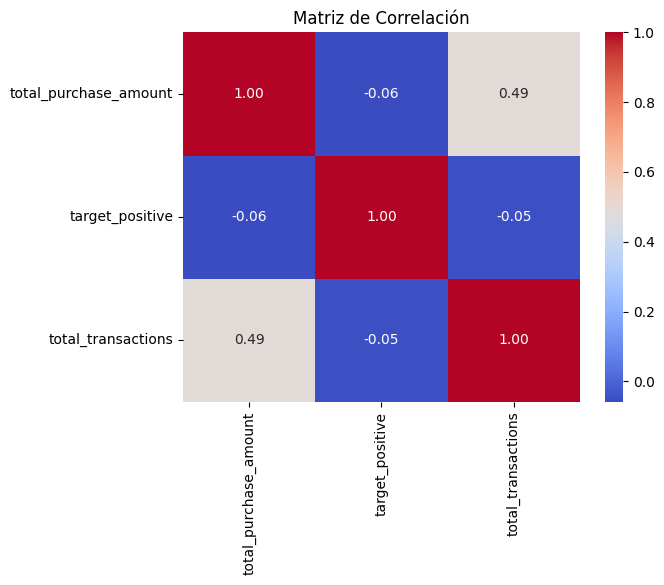

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

pearson_correlation
f64
-0.058811


In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

# Analisis Avanzado

## Historical transactions

### Extraccion de fuente

In [5]:
vdf_hist_trx = pl.read_parquet("data/historical_transactions.parquet").lazy()
vdf_hist_trx.schema

C:\Users\Paul\AppData\Local\Temp\ipykernel_11588\1558397435.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  vdf_hist_trx.schema


Schema([('authorized_flag', String),
        ('card_id', String),
        ('city_id', Int64),
        ('category_1', String),
        ('installments', Int64),
        ('category_3', String),
        ('merchant_category_id', Int64),
        ('merchant_id', String),
        ('month_lag', Int64),
        ('purchase_amount', Float64),
        ('purchase_date', String),
        ('category_2', Float64),
        ('state_id', Int64),
        ('subsector_id', Int64)])

In [6]:
vdf_hist_trx = vdf_hist_trx.select(
    pl.col("card_id"),
    pl.col("purchase_amount"),
    pl.col("purchase_date").str.strptime(pl.Date, "%Y-%m-%d %H:%M:%S").alias("purchase_date"),
    pl.col("merchant_id"),
    pl.col("installments"),
    pl.col("authorized_flag")
)

### Agrupacion por card_id

In [ ]:
# Calcular tendencias de uso de cuotas por card_id y authorized_flag
vdf_install_trends = (
  vdf_hist_trx
  .with_columns(
    pl.col("purchase_date").cast(pl.Int64).alias("purchase_date_num")
  )
  .group_by(["card_id", "authorized_flag"])
  .agg([
    pl.count().alias("txn_count_install"),
    pl.sum("installments").alias("total_installments"),
    pl.mean("installments").alias("mean_installments"),
    pl.median("installments").alias("median_installments"),
    pl.std("installments").alias("std_installments"),
    (pl.max("installments") - pl.min("installments")).alias("installment_range"),
    (
      (pl.max("installments") - pl.min("installments"))
      / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
    ).alias("installment_trend_per_day")
  ])
)

# Unir métricas históricas de monto por tarjeta con las de cuotas
vdf_hist_trx_enhanced = (
  vdf_hist_trx_trends
  .join(vdf_install_trends, on="card_id", how="left")
  .collect()
)

vdf_hist_trx_enhanced

In [35]:
vdf_combined_trends = (
    vdf_hist_trx
    .with_columns(
        pl.col("purchase_date").cast(pl.Int64).alias("purchase_date_num"),
        # Crear columnas binarias para authorized_flag
        pl.when(pl.col("authorized_flag") == "Y").then(1).otherwise(0).alias("is_authorized"),
        pl.when(pl.col("authorized_flag") == "N").then(1).otherwise(0).alias("is_not_authorized")
    )
    .group_by("card_id")
    .agg([
        # Métricas generales
        pl.count().alias("transaction_count"),
        pl.sum("purchase_amount").alias("total_amount"),
        pl.mean("purchase_amount").alias("mean_amount"),
        pl.median("purchase_amount").alias("median_amount"),
        pl.std("purchase_amount").alias("std_amount"),
        pl.min("purchase_date").alias("first_purchase_date"),
        pl.max("purchase_date").alias("last_purchase_date"),
        (pl.max("purchase_amount") - pl.min("purchase_amount")).alias("amount_range"),
        (
            (pl.max("purchase_amount") - pl.min("purchase_amount"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("amount_trend_per_day"),
        
        # Métricas autorizadas
        (pl.col("purchase_amount") * pl.col("is_authorized")).sum().alias("total_amount_authorized"),
        (pl.col("purchase_amount") * pl.col("is_authorized")).mean().alias("mean_amount_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).sum().alias("total_installments_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).mean().alias("mean_installments_authorized"),
        
        # Métricas no autorizadas
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).sum().alias("total_amount_not_authorized"),
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).mean().alias("mean_amount_not_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).sum().alias("total_installments_not_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).mean().alias("mean_installments_not_authorized"),
        
        # Rango y tendencia de cuotas
        pl.max("installments").alias("max_installments"),
        pl.min("installments").alias("min_installments"),
        (pl.max("installments") - pl.min("installments")).alias("installment_range"),
        (
            (pl.max("installments") - pl.min("installments"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("installment_trend_per_day")
    ])
)

# Mostrar el resultado
vdf_combined_trends.collect()

C:\Users\Paul\AppData\Local\Temp\ipykernel_32052\1099717560.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("transaction_count"),


card_id,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,amount_trend_per_day,total_amount_authorized,mean_amount_authorized,total_installments_authorized,mean_installments_authorized,total_amount_not_authorized,mean_amount_not_authorized,total_installments_not_authorized,mean_installments_not_authorized,max_installments,min_installments,installment_range,installment_trend_per_day
str,u32,f64,f64,f64,f64,date,date,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,i64,i64,i64,f64
"""C_ID_14e5eeaa58""",94,-62.651884,-0.666509,-0.701828,0.113116,2017-01-09,2018-02-28,0.871613,0.0021,-60.631149,-0.645012,113,1.202128,-2.020735,-0.021497,6,0.06383,5,-1,6,0.014458
"""C_ID_26ccce072f""",36,-16.466172,-0.457394,-0.513937,0.189785,2017-02-23,2018-02-27,0.74506,0.002019,-13.440584,-0.37335,32,0.888889,-3.025588,-0.084044,7,0.194444,3,1,2,0.00542
"""C_ID_78ccb47892""",27,-13.817148,-0.511746,-0.599798,0.237792,2017-11-23,2018-02-26,0.815639,0.008586,-12.523005,-0.463815,27,1.0,-1.294143,-0.047931,4,0.148148,2,-1,3,0.031579
"""C_ID_0e509d2a14""",93,-65.454854,-0.703816,-0.713248,0.043811,2017-10-13,2018-02-27,0.321868,0.002349,-56.024546,-0.602414,0,0.0,-9.430308,-0.101401,8,0.086022,1,0,1,0.007299
"""C_ID_faaa61c0c6""",129,-88.293094,-0.684443,-0.688304,0.028493,2017-08-05,2018-02-28,0.158154,0.000764,-82.803188,-0.641885,0,0.0,-5.489906,-0.042557,1,0.007752,1,0,1,0.004831
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_eb1e950135""",295,-169.52541,-0.574662,-0.670363,0.370443,2017-05-17,2018-02-27,3.45458,0.012079,-170.692399,-0.578618,348,1.179661,1.166989,0.003956,5,0.016949,12,1,11,0.038462
"""C_ID_89294d98cb""",67,-46.667732,-0.696533,-0.723466,0.098611,2017-04-29,2018-01-09,0.596057,0.002337,-29.646692,-0.442488,0,0.0,-17.021041,-0.254045,23,0.343284,12,0,12,0.047059
"""C_ID_eea1ab5c3a""",21,-10.545561,-0.50217,-0.559076,0.280509,2017-09-29,2018-02-22,1.351034,0.009254,-7.43904,-0.35424,0,0.0,-3.106521,-0.14793,1,0.047619,1,0,1,0.006849


In [56]:
vdf_combined_trends.schema

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\1666302180.py:1: PerformanceWarning:

Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.



Schema([('card_id', String),
        ('transaction_count', UInt32),
        ('total_amount', Float64),
        ('mean_amount', Float64),
        ('median_amount', Float64),
        ('std_amount', Float64),
        ('first_purchase_date', Date),
        ('last_purchase_date', Date),
        ('amount_range', Float64),
        ('amount_trend_per_day', Float64),
        ('total_amount_authorized', Float64),
        ('mean_amount_authorized', Float64),
        ('total_installments_authorized', Int64),
        ('mean_installments_authorized', Float64),
        ('total_amount_not_authorized', Float64),
        ('mean_amount_not_authorized', Float64),
        ('total_installments_not_authorized', Int64),
        ('mean_installments_not_authorized', Float64),
        ('max_installments', Int64),
        ('min_installments', Int64),
        ('installment_range', Int64),
        ('installment_trend_per_day', Float64)])

### Diagrama de cajas

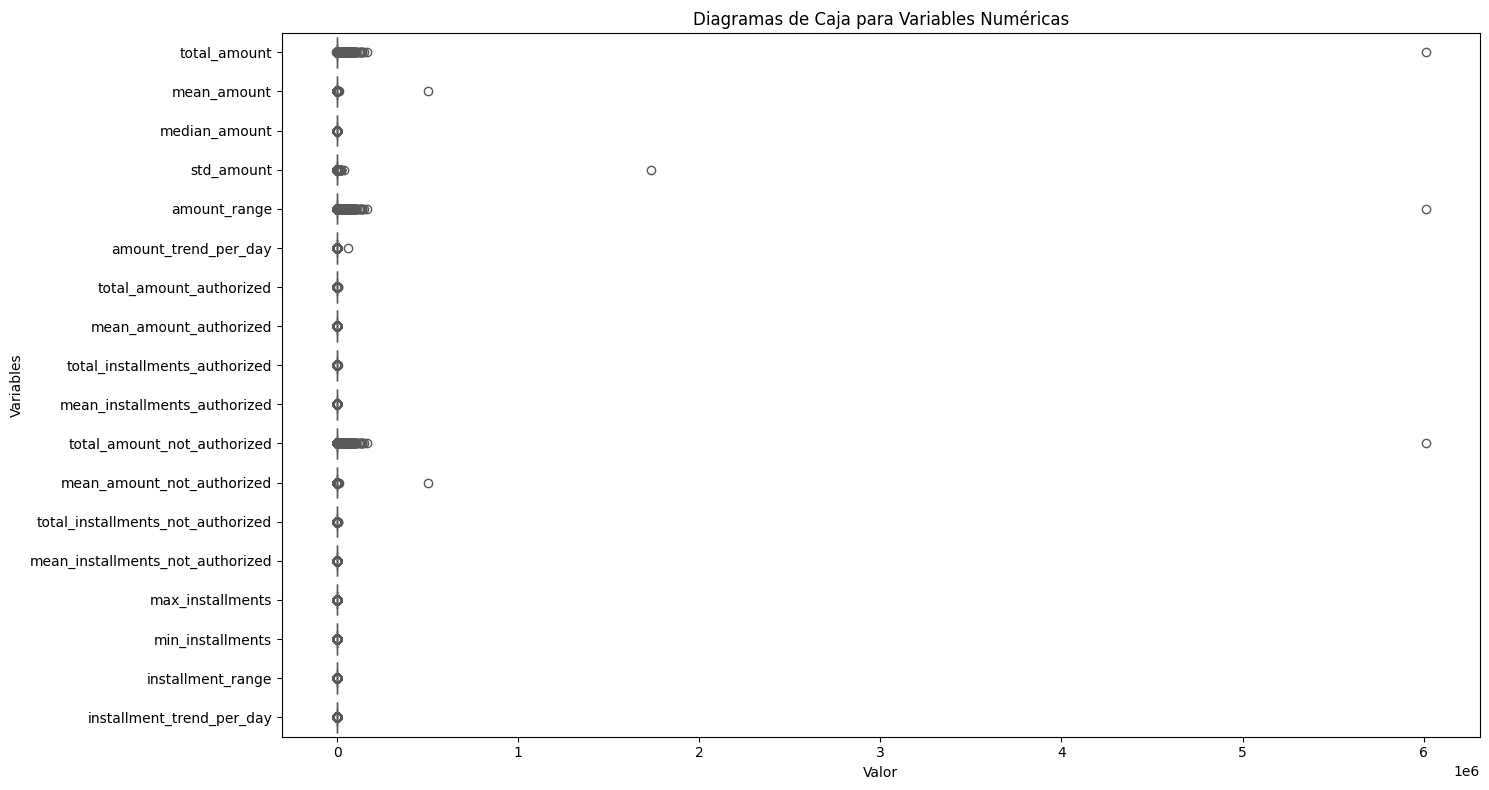

In [55]:
# Vizualizacion de diagrama de caja para las columnas continuas
vdf_merchants_pandas = vdf_combined_trends.collect().to_pandas()
numeric_columns = vdf_merchants_pandas.select_dtypes(include=["float64", "int64"])
# Crear un gráfico de caja para todas las columnas numéricas
plt.figure(figsize=(15, 8))
sns.boxplot(data=numeric_columns, orient="h", palette="Set2")
plt.title("Diagramas de Caja para Variables Numéricas")
plt.xlabel("Valor")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

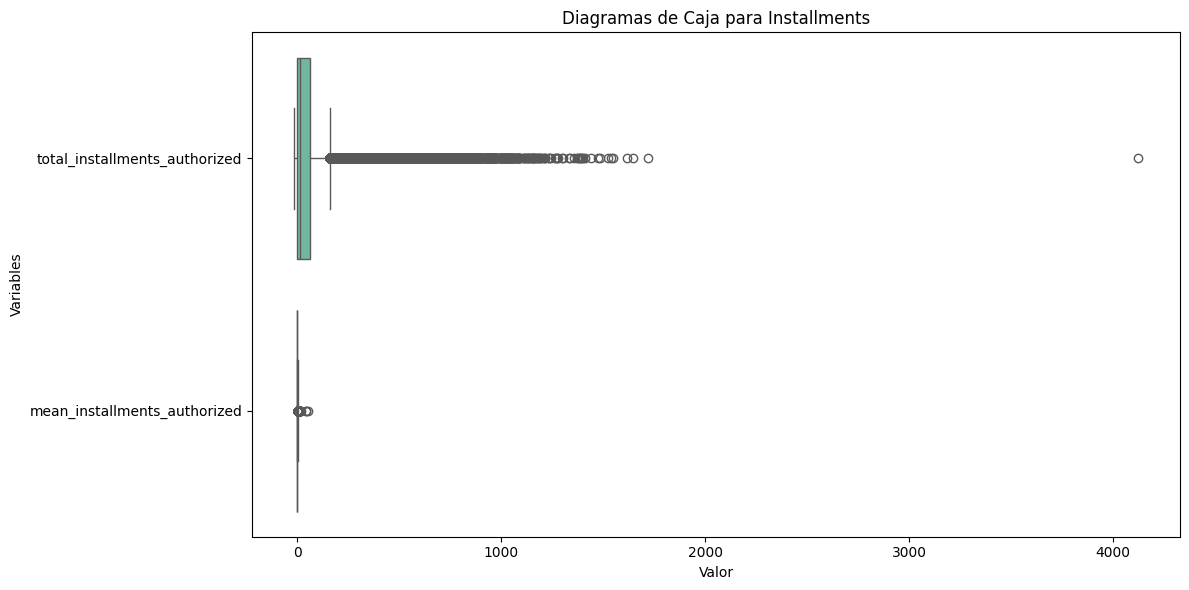

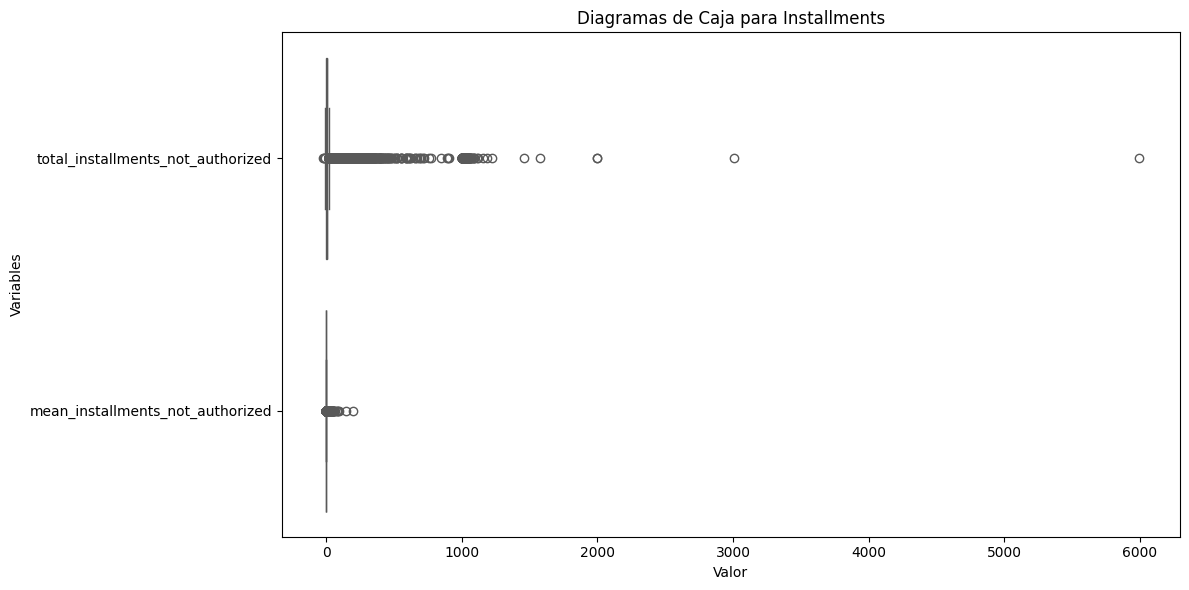

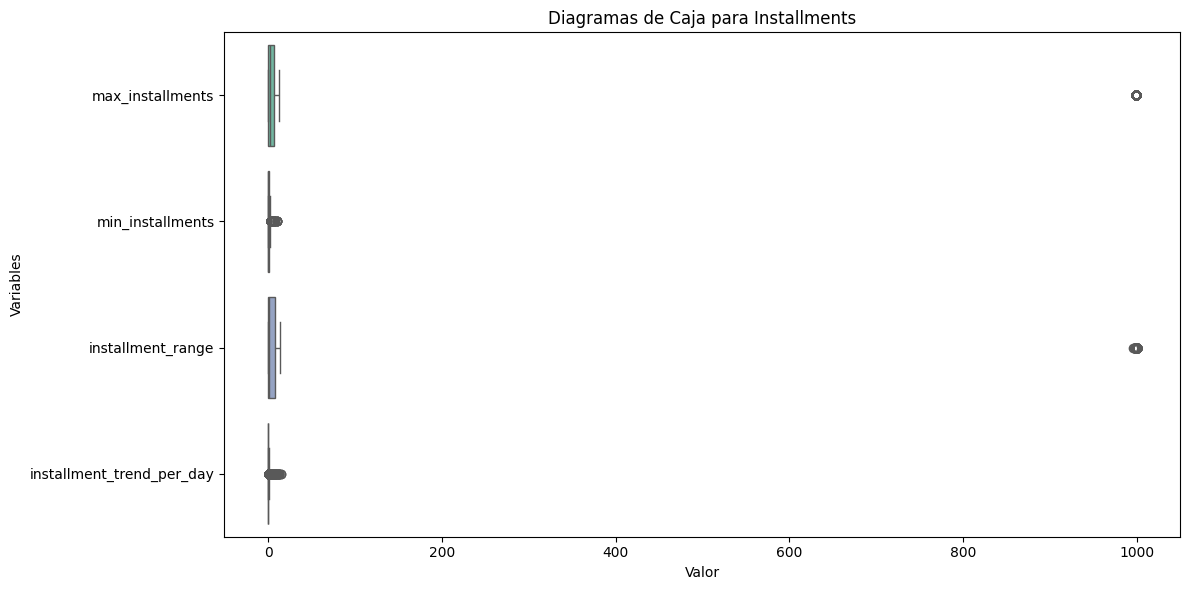

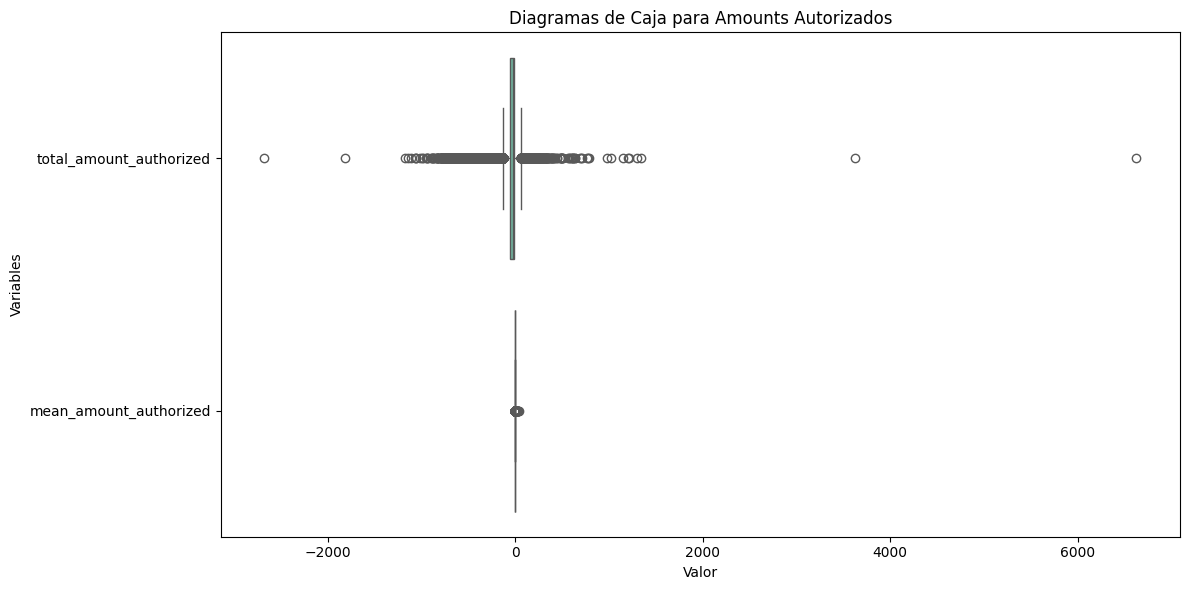

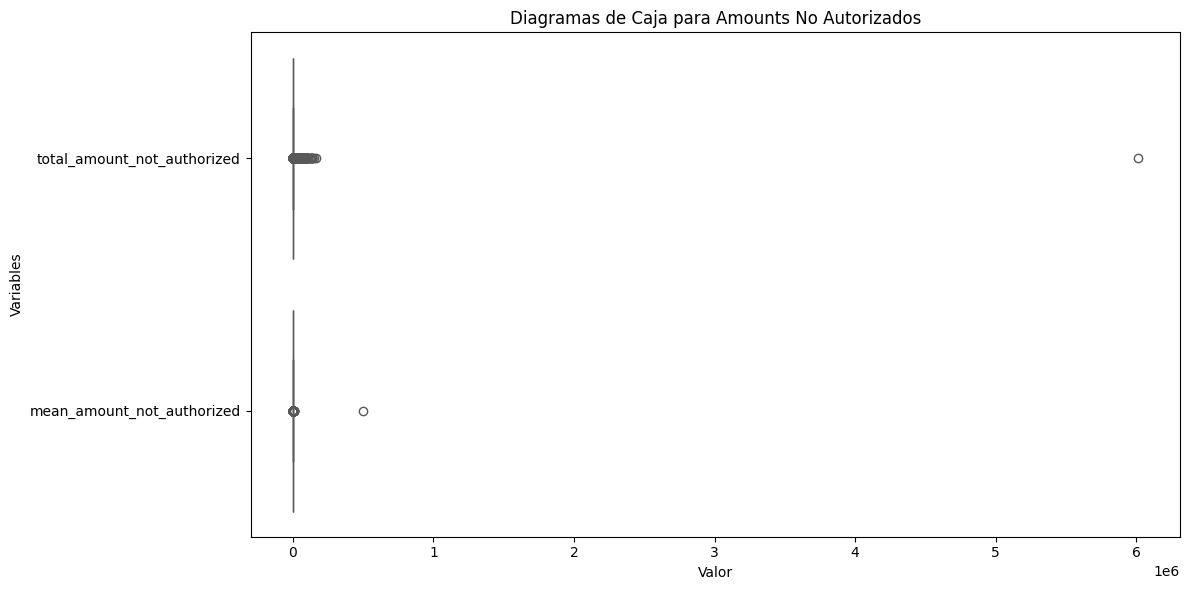

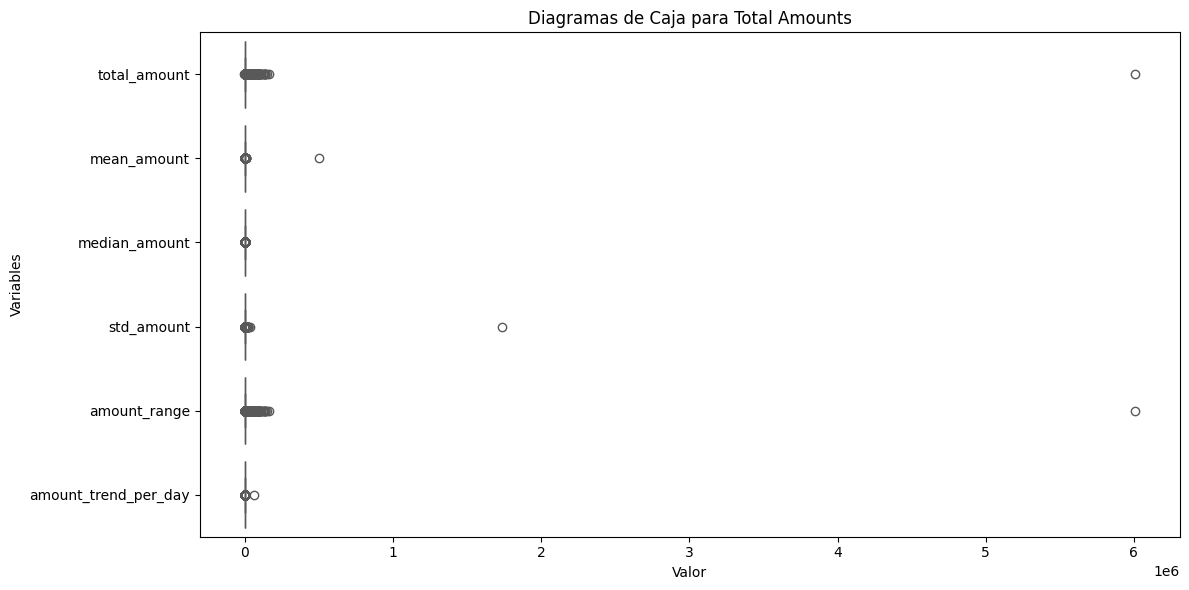

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir a pandas
vdf_merchants_pandas = vdf_combined_trends.collect().to_pandas()

# Reemplazar valores nulos con 0
vdf_merchants_pandas = vdf_merchants_pandas.fillna(0)

# Crear subconjuntos de columnas para cada categoría

authorized_installments_columns = [
    "total_installments_authorized", "mean_installments_authorized"
]

not_authorized_installments_columns = [
    "total_installments_not_authorized", "mean_installments_not_authorized"
]

total_installments_columns = [
    "max_installments", "min_installments", "installment_range", "installment_trend_per_day"
]

authorized_amount_columns = [
    "total_amount_authorized", "mean_amount_authorized"
]

not_authorized_amount_columns = [
    "total_amount_not_authorized", "mean_amount_not_authorized"
]

total_amount_columns = [
    "total_amount", "mean_amount", "median_amount", "std_amount", "amount_range", "amount_trend_per_day"
]

# Función para graficar diagramas de caja
def plot_boxplots(data, columns, title):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[columns], orient="h", palette="Set2")
    plt.title(title)
    plt.xlabel("Valor")
    plt.ylabel("Variables")
    plt.tight_layout()
    plt.show()

# Graficar cada categoría
plot_boxplots(vdf_merchants_pandas, authorized_installments_columns, "Diagramas de Caja para Installments")
plot_boxplots(vdf_merchants_pandas, not_authorized_installments_columns, "Diagramas de Caja para Installments")
plot_boxplots(vdf_merchants_pandas, total_installments_columns, "Diagramas de Caja para Installments")
plot_boxplots(vdf_merchants_pandas, authorized_amount_columns, "Diagramas de Caja para Amounts Autorizados")
plot_boxplots(vdf_merchants_pandas, not_authorized_amount_columns, "Diagramas de Caja para Amounts No Autorizados")
plot_boxplots(vdf_merchants_pandas, total_amount_columns, "Diagramas de Caja para Total Amounts")

### Matriz de correlacion

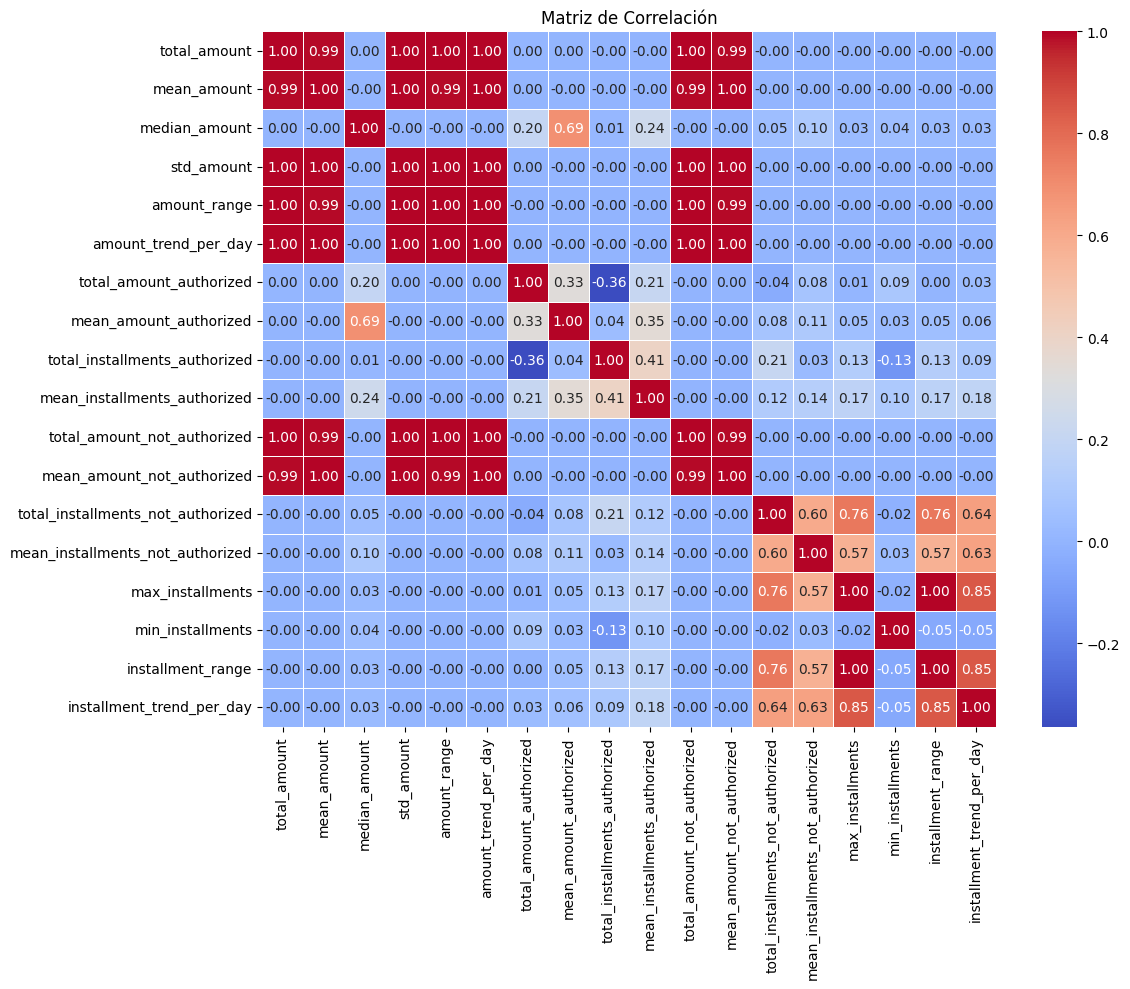

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir a pandas
vdf_merchants_pandas = vdf_combined_trends.collect().to_pandas()

# Reemplazar valores nulos con 0
vdf_merchants_pandas = vdf_merchants_pandas.fillna(0)

# Seleccionar solo las columnas numéricas
numeric_columns = vdf_merchants_pandas.select_dtypes(include=["float64", "int64"])

# Calcular la matriz de correlación
correlation_matrix = numeric_columns.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

- Las columnas con baja correlacion servirán para el modelo predictivo

## Train

### Lectura de datos

In [2]:
#Lectura de train
vdf_train = pl.read_parquet("data/train.parquet").lazy()

### Correlacion entre variables

In [73]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency  # Importar chi2_contingency desde scipy.stats

# Calcular estadísticas básicas del target
stats = vdf_train.select(
    pl.col("target").mean().alias("mean_target"),
    pl.col("target").std().alias("std_target"),
    pl.col("target").min().alias("min_target"),
    pl.col("target").max().alias("max_target")
).collect().to_pandas()

# Convertir las variables categóricas y el target a un DataFrame de Pandas
vdf_train_categorical = vdf_train.select(["feature_1", "feature_2", "feature_3", "target"]).collect().to_pandas()

# Definir la función para calcular Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]  # Usar chi2_contingency de scipy.stats
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

# Calcular Cramér's V para cada par de variables categóricas
cramers_v_results = {}
for col1 in vdf_train_categorical.columns[:-1]:  # Excluir la columna target
    for col2 in vdf_train_categorical.columns[:-1]:
        if col1 != col2:
            cramers_v_results[f"{col1} vs {col2}"] = cramers_v(vdf_train_categorical[col1], vdf_train_categorical[col2])

# Convertir los resultados a un DataFrame
cramers_v_df = pd.DataFrame(list(cramers_v_results.items()), columns=["Variables", "Cramér's V"])

# Mostrar los resultados
print(cramers_v_df)

                Variables  Cramér's V
0  feature_1 vs feature_2    0.241731
1  feature_1 vs feature_3    1.000000
2  feature_2 vs feature_1    0.241731
3  feature_2 vs feature_3    0.080816
4  feature_3 vs feature_1    1.000000
5  feature_3 vs feature_2    0.080816


- Eliminar las altamente correlacionadas

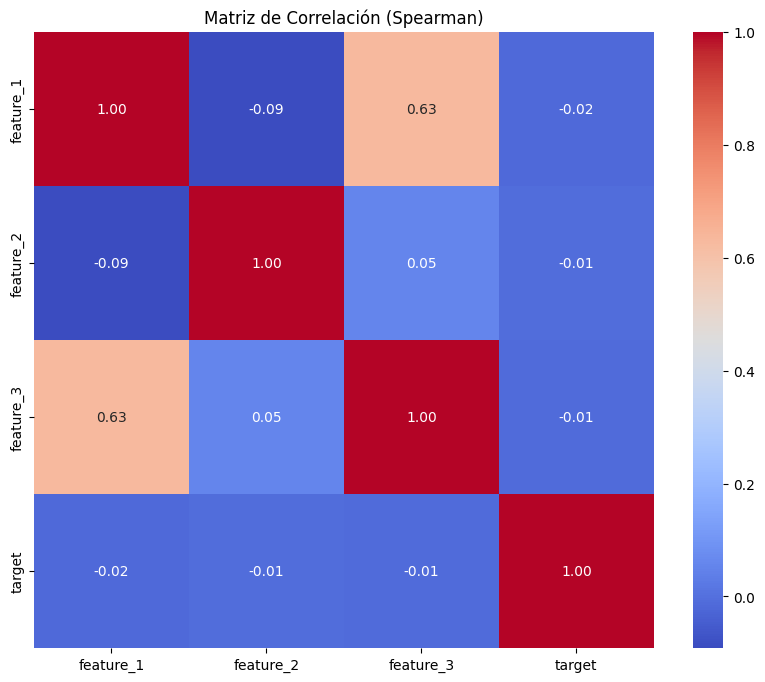

In [74]:
# Correlación entre las variables categóricas y la variable target
vdf_train_categorical = vdf_train.select(["feature_1", "feature_2", "feature_3", "target"]).collect().to_pandas()

# Mapa de correlacion
correlation_matrix = vdf_train_categorical.corr(method='spearman')
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación (Spearman)")
plt.show()

## New Merchant Transactions

### Extraccion de fuente

In [19]:
vdf_new_merchat_trx = pl.read_parquet("data/new_merchant_transactions.parquet").lazy()
vdf_new_merchat_trx.schema

C:\Users\Paul\AppData\Local\Temp\ipykernel_32052\2413355308.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  vdf_new_merchat_trx.schema


Schema([('authorized_flag', String),
        ('card_id', String),
        ('city_id', Int64),
        ('category_1', String),
        ('installments', Int64),
        ('category_3', String),
        ('merchant_category_id', Int64),
        ('merchant_id', String),
        ('month_lag', Int64),
        ('purchase_amount', Float64),
        ('purchase_date', String),
        ('category_2', Float64),
        ('state_id', Int64),
        ('subsector_id', Int64)])

In [20]:
vdf_new_merchat_trx = vdf_new_merchat_trx.select(
    pl.col("card_id"),
    pl.col("purchase_amount"),
    pl.col("purchase_date").str.strptime(pl.Date, "%Y-%m-%d %H:%M:%S").alias("purchase_date"),
    pl.col("merchant_id"),
    pl.col("installments"),
    pl.col("authorized_flag")
)

### Agrupacion por card_id

In [32]:
vdf_combined_trends_new_merch = (
    vdf_new_merchat_trx
    .with_columns(
        pl.col("purchase_date").cast(pl.Int64).alias("purchase_date_num"),
        # Crear columnas binarias para authorized_flag
        pl.when(pl.col("authorized_flag") == "Y").then(1).otherwise(0).alias("is_authorized"),
        pl.when(pl.col("authorized_flag") == "N").then(1).otherwise(0).alias("is_not_authorized")
    )
    .group_by("card_id")
    .agg([
        # Métricas generales
        pl.count().alias("transaction_count"),
        pl.sum("purchase_amount").alias("total_amount"),
        pl.mean("purchase_amount").alias("mean_amount"),
        pl.median("purchase_amount").alias("median_amount"),
        pl.std("purchase_amount").alias("std_amount"),
        pl.min("purchase_date").alias("first_purchase_date"),
        pl.max("purchase_date").alias("last_purchase_date"),
        (pl.max("purchase_amount") - pl.min("purchase_amount")).alias("amount_range"),
        (
            (pl.max("purchase_amount") - pl.min("purchase_amount"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("amount_trend_per_day"),
        
        # Métricas autorizadas
        (pl.col("purchase_amount") * pl.col("is_authorized")).sum().alias("total_amount_authorized"),
        (pl.col("purchase_amount") * pl.col("is_authorized")).mean().alias("mean_amount_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).sum().alias("total_installments_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).mean().alias("mean_installments_authorized"),
        
        # Métricas no autorizadas
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).sum().alias("total_amount_not_authorized"),
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).mean().alias("mean_amount_not_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).sum().alias("total_installments_not_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).mean().alias("mean_installments_not_authorized"),
        
        # Rango y tendencia de cuotas
        pl.max("installments").alias("max_installments"),
        pl.min("installments").alias("min_installments"),
        (pl.max("installments") - pl.min("installments")).alias("installment_range"),
        (
            (pl.max("installments") - pl.min("installments"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("installment_trend_per_day")
    ])
)

# Mostrar el resultado
vdf_combined_trends_new_merch.collect()

C:\Users\Paul\AppData\Local\Temp\ipykernel_32052\1082406158.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("transaction_count"),


card_id,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,amount_trend_per_day,total_amount_authorized,mean_amount_authorized,total_installments_authorized,mean_installments_authorized,total_amount_not_authorized,mean_amount_not_authorized,total_installments_not_authorized,mean_installments_not_authorized,max_installments,min_installments,installment_range,installment_trend_per_day
str,u32,f64,f64,f64,f64,date,date,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,i64,i64,i64,f64
"""C_ID_e5232c2648""",9,-6.445111,-0.716123,-0.724368,0.02161,2018-03-04,2018-04-30,0.066117,0.00116,-6.445111,-0.716123,0,0.0,-0.0,-0.0,0,0.0,0,0,0,0.0
"""C_ID_0b8dd43d79""",9,-5.337327,-0.593036,-0.685299,0.191531,2018-03-09,2018-04-30,0.509248,0.009793,-5.337327,-0.593036,0,0.0,-0.0,-0.0,0,0.0,0,0,0,0.0
"""C_ID_aa0cb29be9""",1,-0.67463,-0.67463,-0.67463,null,2018-01-20,2018-01-20,0.0,NaN,-0.67463,-0.67463,0,0.0,-0.0,-0.0,0,0.0,0,0,0,NaN
"""C_ID_244c9d407e""",4,-2.792903,-0.698226,-0.720311,0.046804,2017-07-06,2017-08-31,0.095884,0.001712,-2.792903,-0.698226,4,1.0,-0.0,-0.0,0,0.0,1,1,0,0.0
"""C_ID_fa8274362d""",3,-1.830289,-0.610096,-0.650077,0.135747,2018-03-22,2018-04-02,0.262513,0.023865,-1.830289,-0.610096,4,1.333333,-0.0,-0.0,0,0.0,2,1,1,0.090909
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_986fc1874c""",28,-19.679111,-0.702825,-0.707576,0.032647,2018-03-06,2018-04-26,0.14756,0.002893,-19.679111,-0.702825,0,0.0,-0.0,-0.0,0,0.0,0,0,0,0.0
"""C_ID_cd59f5cb22""",10,-6.237791,-0.623779,-0.638191,0.097803,2017-12-09,2018-01-22,0.250943,0.005703,-6.237791,-0.623779,0,0.0,-0.0,-0.0,0,0.0,0,0,0,0.0
"""C_ID_9f0a5b7cc7""",3,-2.113749,-0.704583,-0.734887,0.056436,2018-03-28,2018-04-13,0.099926,0.006245,-2.113749,-0.704583,0,0.0,-0.0,-0.0,0,0.0,0,0,0,0.0


In [ ]:
vdf_combined_trends.schema

C:\Users\Paul\AppData\Local\Temp\ipykernel_29472\1666302180.py:1: PerformanceWarning:

Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.



Schema([('card_id', String),
        ('transaction_count', UInt32),
        ('total_amount', Float64),
        ('mean_amount', Float64),
        ('median_amount', Float64),
        ('std_amount', Float64),
        ('first_purchase_date', Date),
        ('last_purchase_date', Date),
        ('amount_range', Float64),
        ('amount_trend_per_day', Float64),
        ('total_amount_authorized', Float64),
        ('mean_amount_authorized', Float64),
        ('total_installments_authorized', Int64),
        ('mean_installments_authorized', Float64),
        ('total_amount_not_authorized', Float64),
        ('mean_amount_not_authorized', Float64),
        ('total_installments_not_authorized', Int64),
        ('mean_installments_not_authorized', Float64),
        ('max_installments', Int64),
        ('min_installments', Int64),
        ('installment_range', Int64),
        ('installment_trend_per_day', Float64)])

### Diagrama de cajas

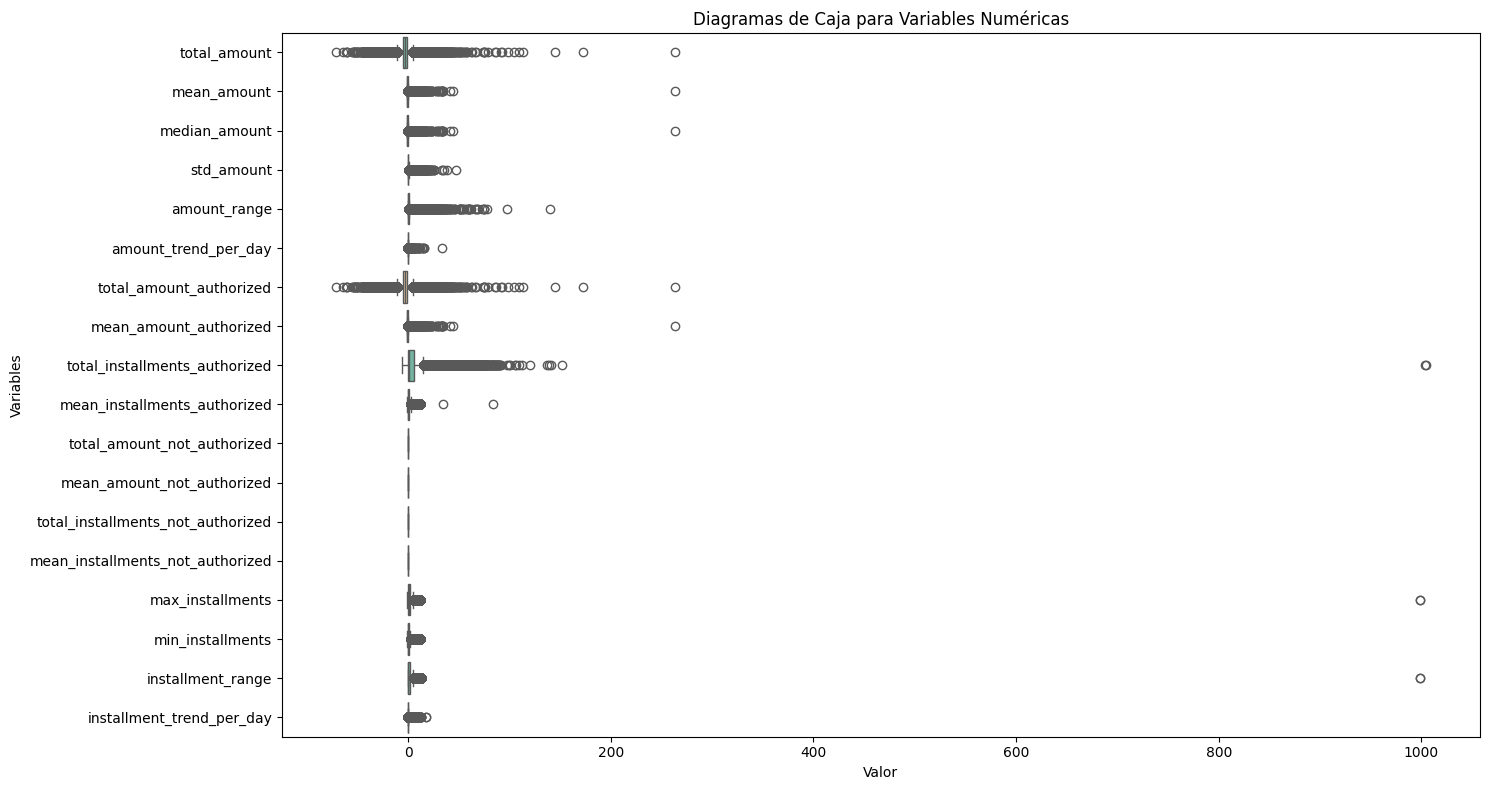

In [79]:
# Vizualizacion de diagrama de caja para las columnas continuas
vdf_merchants_pandas = vdf_combined_trends.collect().to_pandas()
numeric_columns = vdf_merchants_pandas.select_dtypes(include=["float64", "int64"])
# Crear un gráfico de caja para todas las columnas numéricas
plt.figure(figsize=(15, 8))
sns.boxplot(data=numeric_columns, orient="h", palette="Set2")
plt.title("Diagramas de Caja para Variables Numéricas")
plt.xlabel("Valor")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

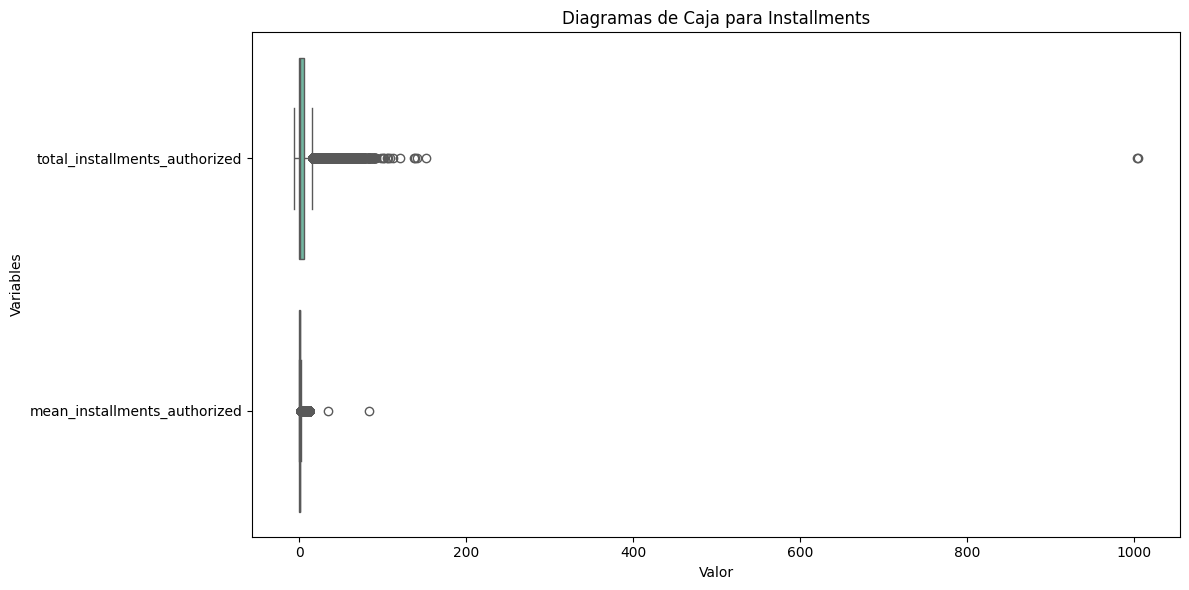

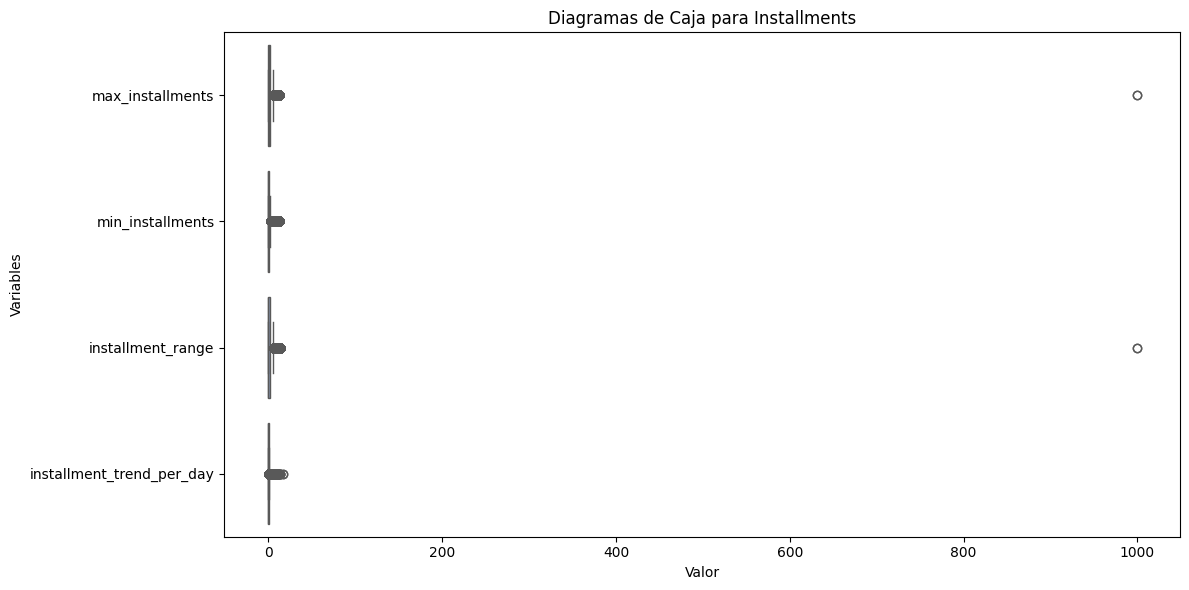

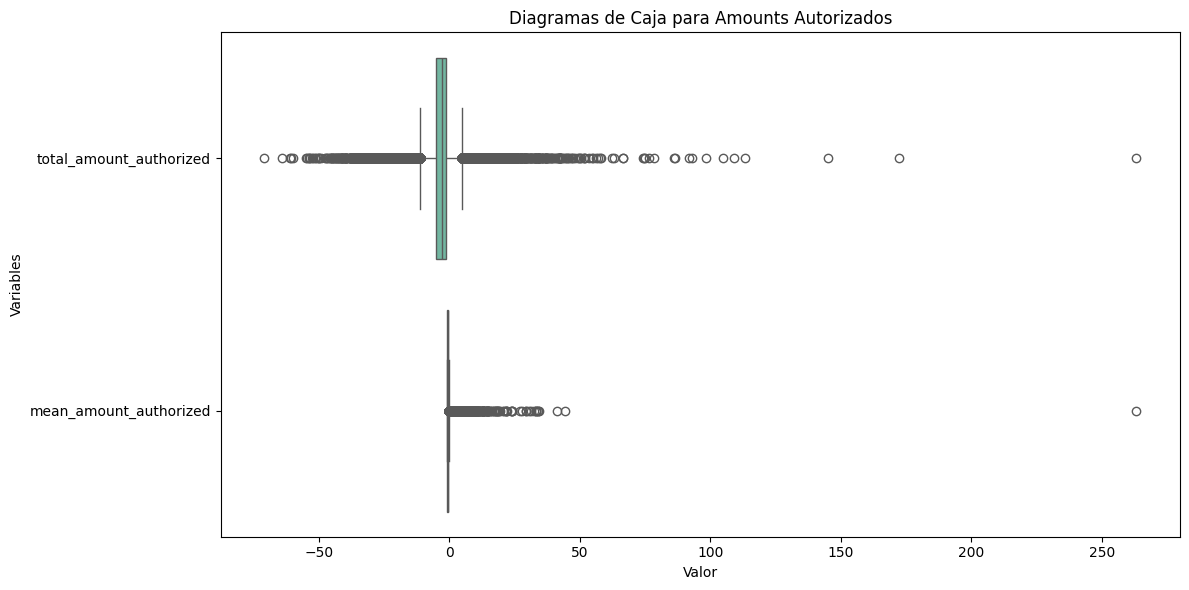

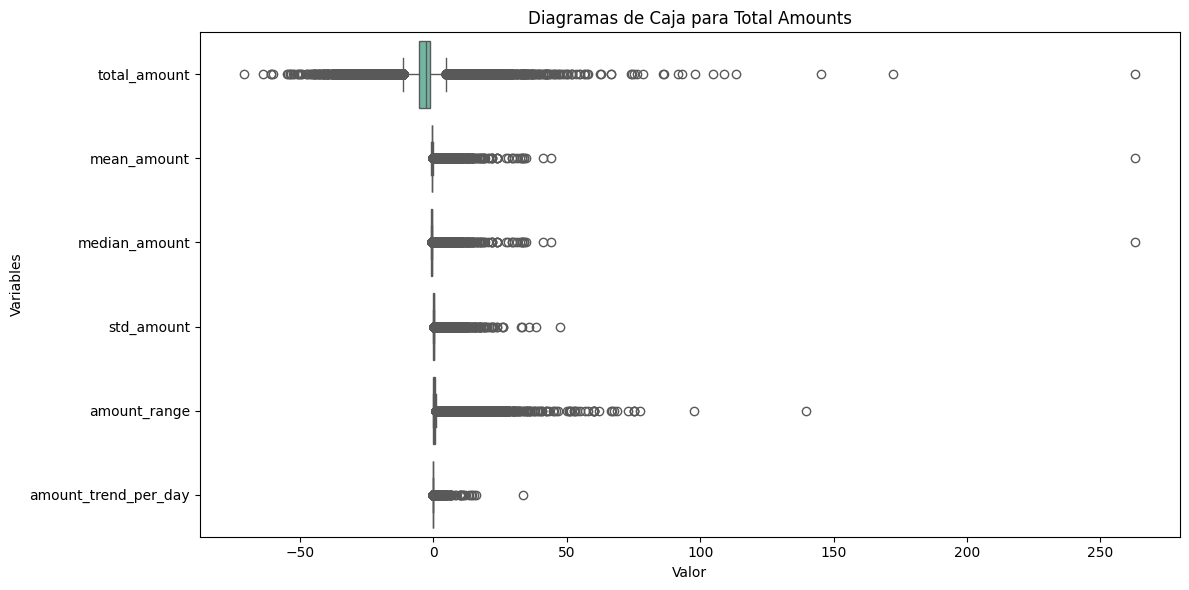

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir a pandas
vdf_merchants_pandas = vdf_combined_trends.collect().to_pandas()

# Reemplazar valores nulos con 0
vdf_merchants_pandas = vdf_merchants_pandas.fillna(0)

# Crear subconjuntos de columnas para cada categoría

authorized_installments_columns = [
    "total_installments_authorized", "mean_installments_authorized"
]

not_authorized_installments_columns = [
    "total_installments_not_authorized", "mean_installments_not_authorized"
]

total_installments_columns = [
    "max_installments", "min_installments", "installment_range", "installment_trend_per_day"
]

authorized_amount_columns = [
    "total_amount_authorized", "mean_amount_authorized"
]

not_authorized_amount_columns = [
    "total_amount_not_authorized", "mean_amount_not_authorized"
]

total_amount_columns = [
    "total_amount", "mean_amount", "median_amount", "std_amount", "amount_range", "amount_trend_per_day"
]

# Función para graficar diagramas de caja
def plot_boxplots(data, columns, title):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[columns], orient="h", palette="Set2")
    plt.title(title)
    plt.xlabel("Valor")
    plt.ylabel("Variables")
    plt.tight_layout()
    plt.show()

# Graficar cada categoría
plot_boxplots(vdf_merchants_pandas, authorized_installments_columns, "Diagramas de Caja para Installments")
# plot_boxplots(vdf_merchants_pandas, not_authorized_installments_columns, "Diagramas de Caja para Installments")
plot_boxplots(vdf_merchants_pandas, total_installments_columns, "Diagramas de Caja para Installments")
plot_boxplots(vdf_merchants_pandas, authorized_amount_columns, "Diagramas de Caja para Amounts Autorizados")
# plot_boxplots(vdf_merchants_pandas, not_authorized_amount_columns, "Diagramas de Caja para Amounts No Autorizados")
plot_boxplots(vdf_merchants_pandas, total_amount_columns, "Diagramas de Caja para Total Amounts")

### Matriz de correlacion

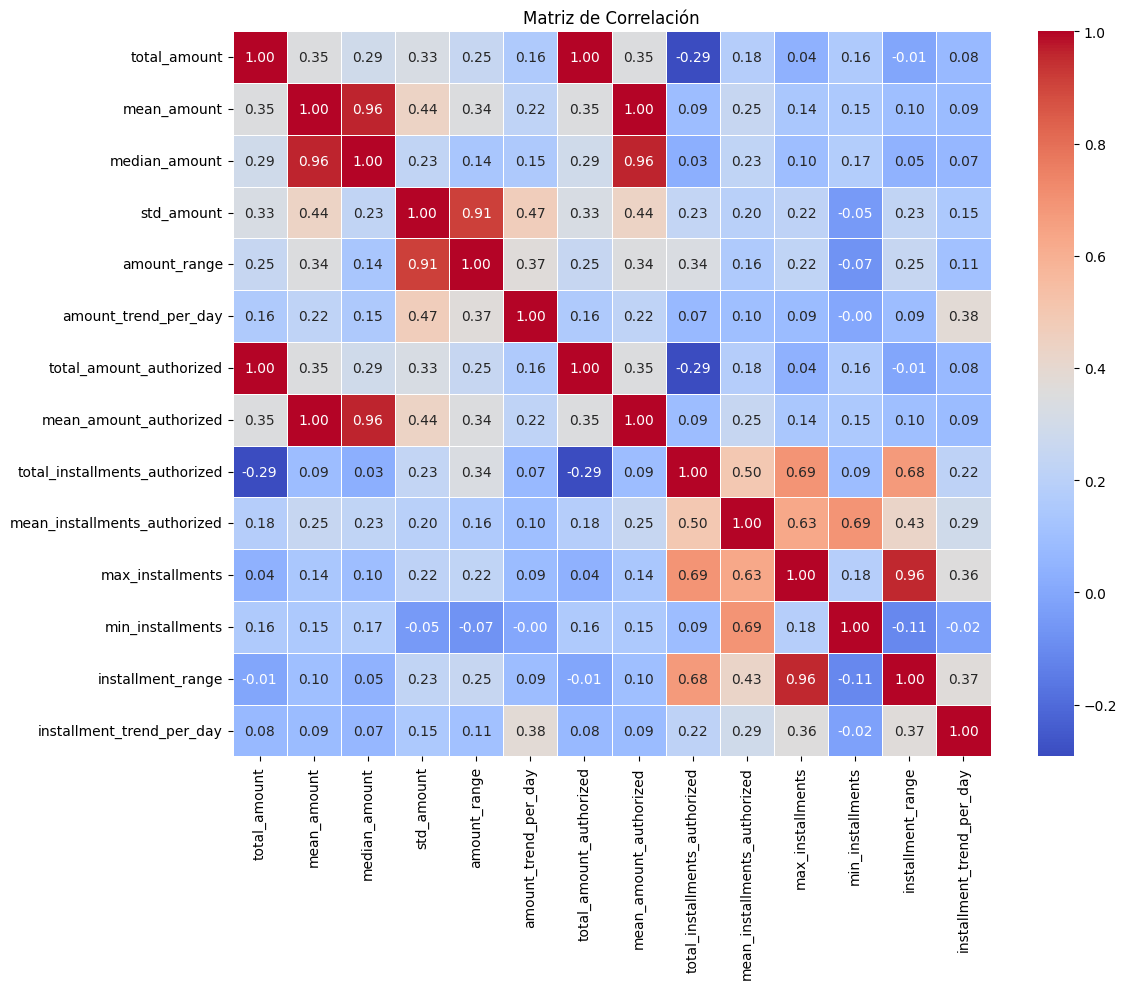

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir a pandas
vdf_merchants_pandas = vdf_combined_trends.collect().to_pandas()

# Reemplazar valores nulos con 0
vdf_merchants_pandas = vdf_merchants_pandas.fillna(0)

# Seleccionar solo las columnas numéricas
numeric_columns = vdf_merchants_pandas.select_dtypes(include=["float64", "int64"]).drop(columns=[
    "total_installments_not_authorized", "mean_installments_not_authorized"
] + [
    "total_amount_not_authorized", "mean_amount_not_authorized"
])

# Calcular la matriz de correlación
correlation_matrix = numeric_columns.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

- Las columnas con baja correlacion servirán para el modelo predictivo

## Merchants

### Lectura de datos

In [4]:
vdf_merchants = pl.read_parquet("data/merchants.parquet").lazy()
vdf_merchants.schema

C:\Users\Paul\AppData\Local\Temp\ipykernel_26480\1661948164.py:2: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  vdf_merchants.schema


Schema([('merchant_id', String),
        ('merchant_group_id', Int64),
        ('merchant_category_id', Int64),
        ('subsector_id', Int64),
        ('numerical_1', Float64),
        ('numerical_2', Float64),
        ('category_1', String),
        ('most_recent_sales_range', String),
        ('most_recent_purchases_range', String),
        ('avg_sales_lag3', Float64),
        ('avg_purchases_lag3', Float64),
        ('active_months_lag3', Int64),
        ('avg_sales_lag6', Float64),
        ('avg_purchases_lag6', Float64),
        ('active_months_lag6', Int64),
        ('avg_sales_lag12', Float64),
        ('avg_purchases_lag12', Float64),
        ('active_months_lag12', Int64),
        ('category_4', String),
        ('city_id', Int64),
        ('state_id', Int64),
        ('category_2', Float64)])

In [5]:
vdf_merchants = vdf_merchants.select(
    pl.col("merchant_id"),
    pl.col("merchant_group_id"),
    pl.col("merchant_category_id"),
    pl.col("most_recent_sales_range"),
    pl.col("most_recent_purchases_range"),
    pl.col("avg_sales_lag3"),
    pl.col("avg_purchases_lag3"),
    pl.col("active_months_lag3"),
    pl.col("avg_sales_lag6"),
    pl.col("avg_purchases_lag6"),
    pl.col("active_months_lag6"),
    pl.col("avg_sales_lag12"),
    pl.col("avg_purchases_lag12"),
    pl.col("active_months_lag12")
).collect()

### Boxplots

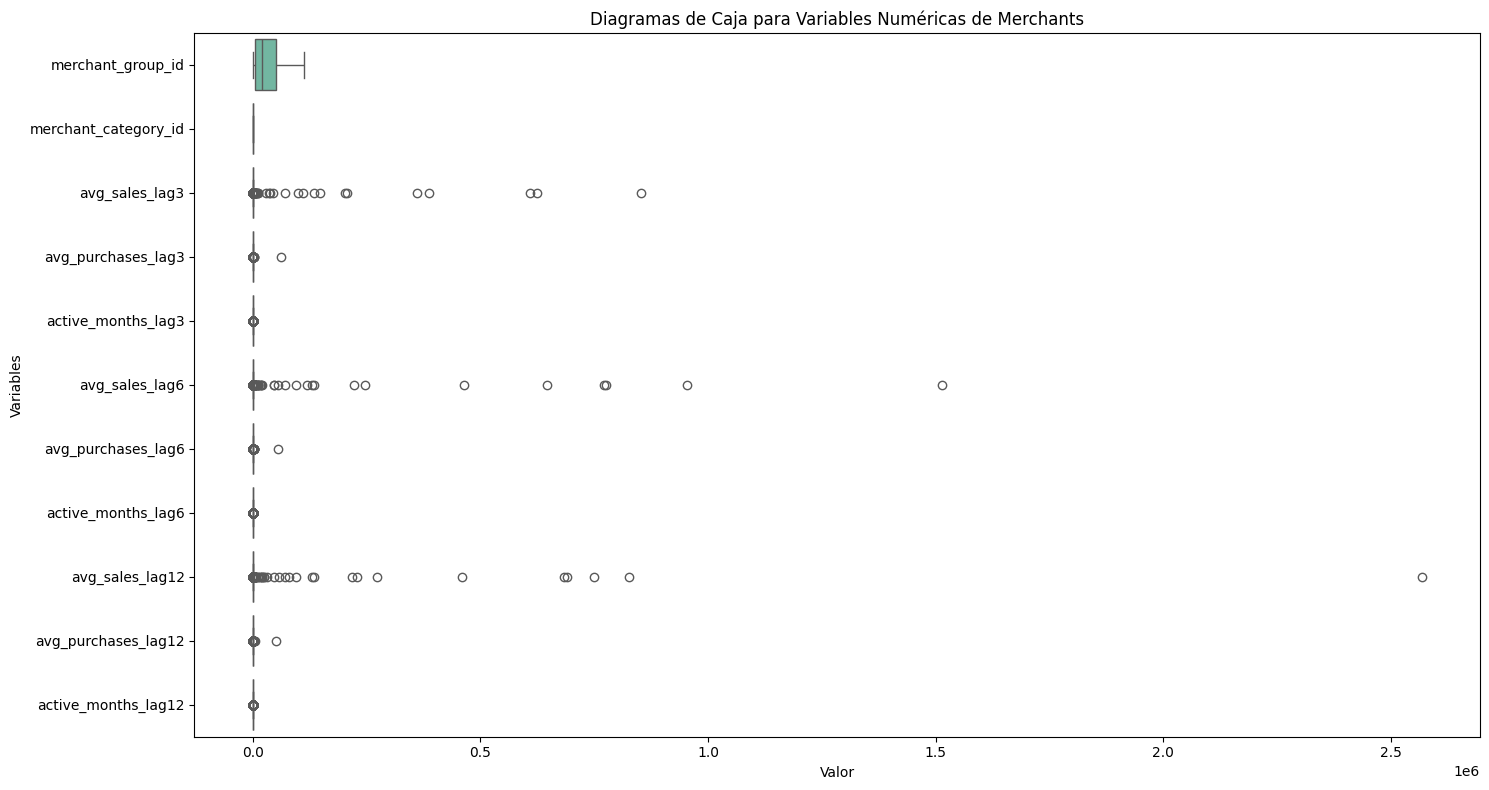

In [13]:
vdf_merchants_pandas = vdf_merchants.to_pandas()
numeric_columns = vdf_merchants_pandas.select_dtypes(include=["float64", "int64"])

# Diagrama de caja y bigotes para las columnas continuas
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=numeric_columns
    , orient="h", palette="Set2"
)
plt.title("Diagramas de Caja para Variables Numéricas de Merchants")
plt.xlabel("Valor")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [10]:
vdf_merchants.group_by("merchant_category_id").agg(
    pl.col("merchant_id").n_unique().alias("unique_merchants")
).sort("unique_merchants", descending=True).to_pandas().head(10)

,merchant_category_id,unique_merchants
0,705,30666
1,278,17989
2,307,17528
3,367,15387
4,68,14341
5,80,13519
6,222,11582
7,884,10397
8,683,9175
9,560,7985


In [11]:
vdf_merchants.group_by("merchant_group_id").agg(
    pl.col("merchant_id").n_unique().alias("unique_merchants")
).sort("unique_merchants", descending=True).to_pandas().head(10)

,merchant_group_id,unique_merchants
0,35,45986
1,434,482
2,419,365
3,713,333
4,3648,305
5,48,283
6,1145,276
7,771,257
8,325,248
9,321,235


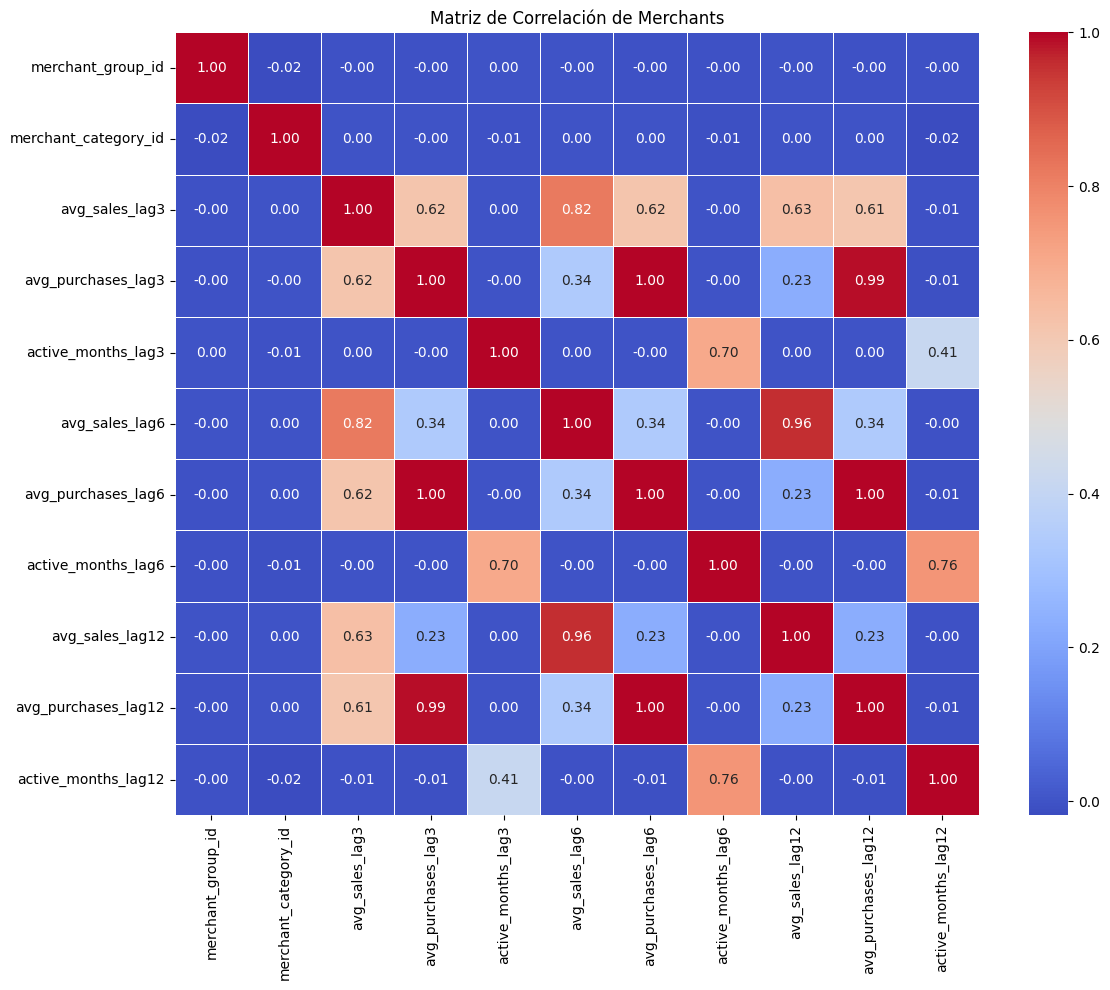

In [15]:
# Correlación entre las variables continuas
correlation_matrix = numeric_columns.corr()

# Mapa de calor de la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix
    , annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Matriz de Correlación de Merchants")
plt.tight_layout()
plt.show()


## Relacion con Target

In [52]:
from datetime import datetime
vdf_total_mtx = vdf_train.collect().join(
    vdf_combined_trends.collect(), on="card_id", how="left"
)
# Obtener la fecha actual
current_date = datetime.now()

vdf_total_mtx = vdf_total_mtx.with_columns(
    # Antiguedad del cliente desde el first_purchase_date
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_purchase_date").cast(pl.Int64)).alias("firs_last_purchase_diff"), 
    # Antiguedad del cliente desde el primer mes de actividad
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_last_purchase_diff"),
    # Antiguedad del cliente desde el primer mes de actividad hasta la fecha actual
    (pl.lit(current_date).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_to_now_days")
)

In [53]:
vdf_total_mtx.head()

first_active_month,card_id,feature_1,feature_2,feature_3,target,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,amount_trend_per_day,total_amount_authorized,mean_amount_authorized,total_installments_authorized,mean_installments_authorized,total_amount_not_authorized,mean_amount_not_authorized,total_installments_not_authorized,mean_installments_not_authorized,max_installments,min_installments,installment_range,installment_trend_per_day,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
str,str,i64,i64,i64,f64,u32,f64,f64,f64,f64,date,date,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,i64,i64,i64,f64,i64,i64,i64
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,260,-165.968739,-0.638341,-0.698042,0.212139,2017-06-27,2018-02-25,2.997789,0.012337,-157.397016,-0.605373,0,0.0,-8.571723,-0.032968,4,0.015385,1,0,1,0.004115,243,269,1748386640907833
"""2017-01""","""C_ID_3d0044924f""",4,1,0,0.392913,350,-210.006336,-0.600018,-0.70859,0.384967,2017-01-06,2018-01-31,5.372699,0.013776,-208.88345,-0.59681,501,1.431429,-1.122886,-0.003208,42,0.12,10,-1,11,0.028205,390,395,1748386640907984
"""2016-08""","""C_ID_d639edf6cd""",2,2,0,0.688056,43,-29.167391,-0.678311,-0.698868,0.08738,2017-01-11,2018-02-27,0.584291,0.001418,-27.828424,-0.647173,0,0.0,-1.338967,-0.031139,0,0.0,0,0,0,0.0,412,575,1748386640908137
"""2017-09""","""C_ID_186d6a6901""",4,3,0,0.1424952,77,-49.491364,-0.642745,-0.707989,0.261624,2017-09-26,2018-02-28,2.1864927,0.014106,-49.491364,-0.642745,84,1.090909,0.0,0.0,0,0.0,3,-1,4,0.025806,155,180,1748386640907741
"""2017-11""","""C_ID_cdbd2c0db2""",1,3,0,-0.159749,133,-48.687656,-0.366073,-0.689807,1.352094,2017-11-12,2018-02-28,7.9391974,0.073511,-69.040465,-0.519101,144,1.082707,20.352809,0.153029,38,0.285714,12,1,11,0.101852,108,119,1748386640907680


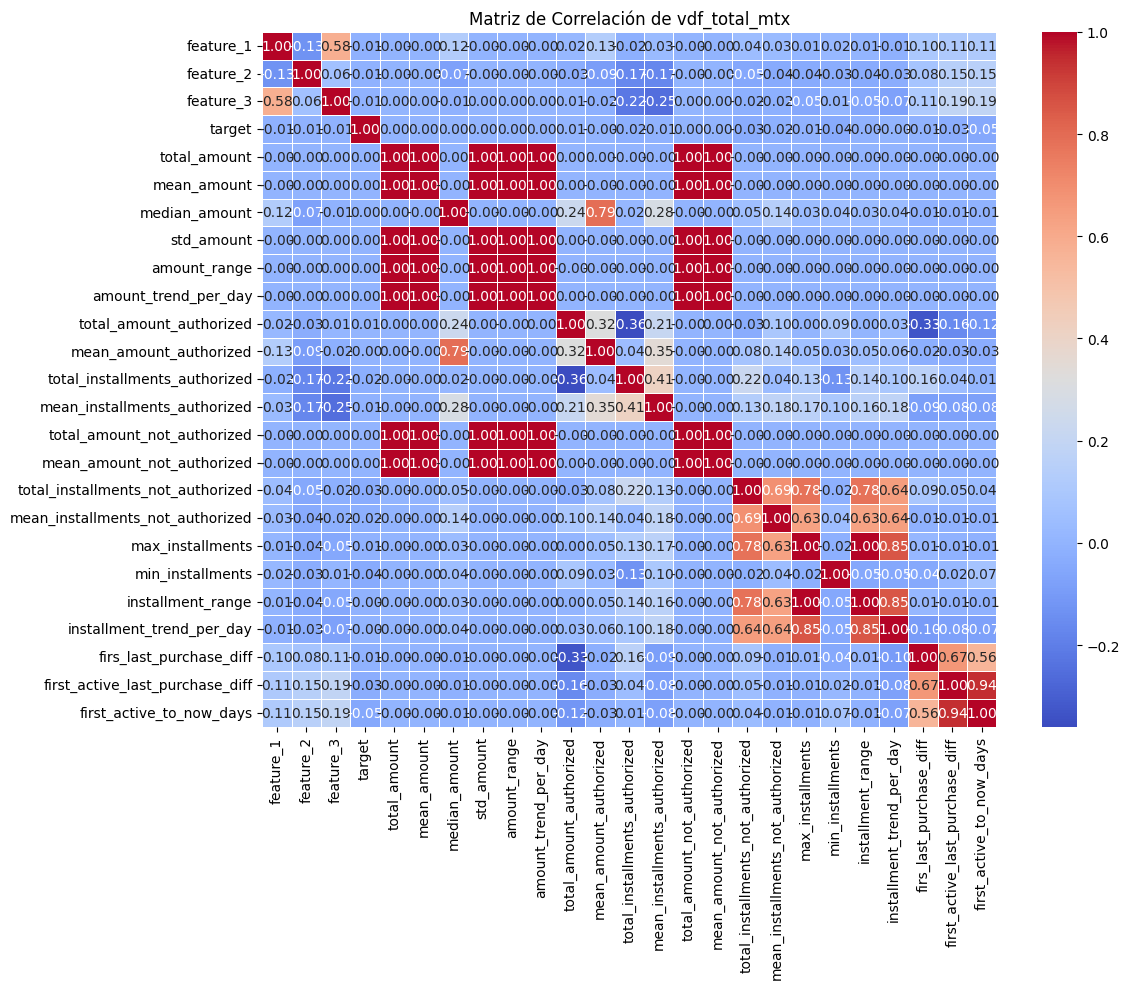

In [54]:
# Variables continuas de vdf_total_mtx
continuous_total_mtx = [
    col for col in vdf_total_mtx.columns if vdf_total_mtx.schema[col] in [pl.Float64, pl.Int64]
]

# Seleccionar solo las columnas continuas
vdf_continuous = vdf_total_mtx.select(continuous_total_mtx)

# Convertir a pandas para calcular la matriz de correlación
df_continuous = vdf_continuous.to_pandas()

# Calcular la matriz de correlación
correlation_matrix_total_mtx = df_continuous.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix_total_mtx,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de Correlación de vdf_total_mtx")
plt.tight_layout()
plt.show()

In [55]:
from datetime import datetime
vdf_total_mtx = vdf_train.collect().join(
    vdf_combined_trends_new_merch.collect(), on="card_id", how="left"
)
# Obtener la fecha actual
current_date = datetime.now()

vdf_total_mtx = vdf_total_mtx.with_columns(
    # Antiguedad del cliente desde el first_purchase_date
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_purchase_date").cast(pl.Int64)).alias("firs_last_purchase_diff"), 
    # Antiguedad del cliente desde el primer mes de actividad
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_last_purchase_diff"),
    # Antiguedad del cliente desde el primer mes de actividad hasta la fecha actual
    (pl.lit(current_date).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_to_now_days")
)

In [56]:
vdf_total_mtx.head()

first_active_month,card_id,feature_1,feature_2,feature_3,target,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,amount_trend_per_day,total_amount_authorized,mean_amount_authorized,total_installments_authorized,mean_installments_authorized,total_amount_not_authorized,mean_amount_not_authorized,total_installments_not_authorized,mean_installments_not_authorized,max_installments,min_installments,installment_range,installment_trend_per_day,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
str,str,i64,i64,i64,f64,u32,f64,f64,f64,f64,date,date,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,i64,i64,i64,f64,i64,i64,i64
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,23,-13.244202,-0.575835,-0.58118,0.135812,2018-03-05,2018-04-29,0.428256,0.007786,-13.244202,-0.575835,0,0.0,-0.0,-0.0,0,0.0,0,0,0,0.0,55,332,1748386766384297
"""2017-01""","""C_ID_3d0044924f""",4,1,0,0.392913,6,-4.355735,-0.725956,-0.732633,0.014326,2018-02-01,2018-03-30,0.037551,0.000659,-4.355735,-0.725956,6,1.0,-0.0,-0.0,0,0.0,1,1,0,0.0,57,453,1748386766384448
"""2016-08""","""C_ID_d639edf6cd""",2,2,0,0.688056,1,-0.700326,-0.700326,-0.700326,null,2018-04-28,2018-04-28,0.0,NaN,-0.700326,-0.700326,0,0.0,-0.0,-0.0,0,0.0,0,0,0,NaN,0,635,1748386766384601
"""2017-09""","""C_ID_186d6a6901""",4,3,0,0.1424952,7,-4.654372,-0.66491,-0.69161,0.065882,2018-03-07,2018-04-18,0.167395,0.003986,-4.654372,-0.66491,5,0.714286,-0.0,-0.0,0,0.0,1,-1,2,0.047619,42,229,1748386766384205
"""2017-11""","""C_ID_cdbd2c0db2""",1,3,0,-0.159749,36,-19.926237,-0.553507,-0.607447,0.223821,2018-03-02,2018-04-28,1.19028,0.020882,-19.926237,-0.553507,35,0.972222,0.0,0.0,0,0.0,2,-1,3,0.052632,57,178,1748386766384144


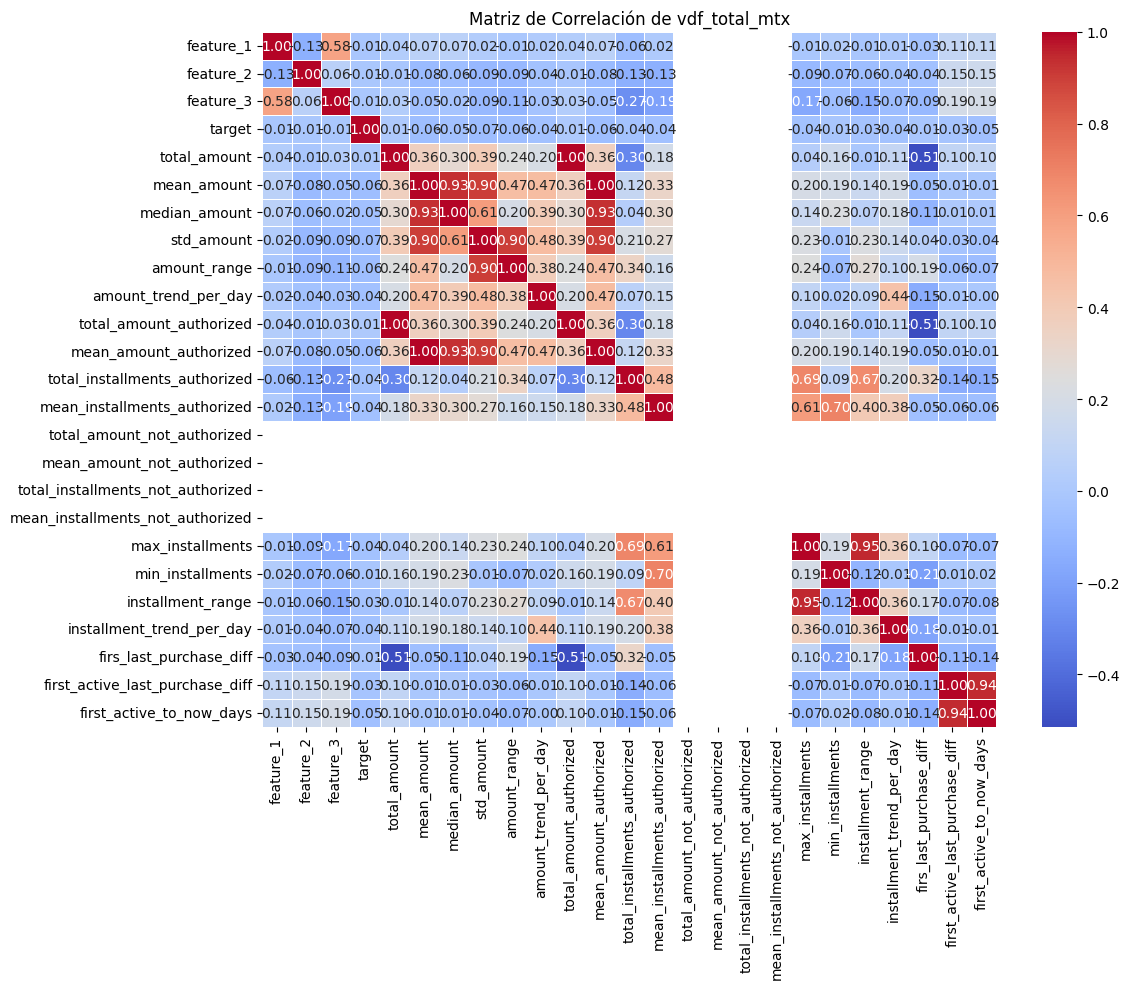

In [57]:
# Variables continuas de vdf_total_mtx
continuous_total_mtx = [
    col for col in vdf_total_mtx.columns if vdf_total_mtx.schema[col] in [pl.Float64, pl.Int64]
]

# Seleccionar solo las columnas continuas
vdf_continuous = vdf_total_mtx.select(continuous_total_mtx)

# Convertir a pandas para calcular la matriz de correlación
df_continuous = vdf_continuous.to_pandas()

# Calcular la matriz de correlación
correlation_matrix_total_mtx = df_continuous.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix_total_mtx,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de Correlación de vdf_total_mtx")
plt.tight_layout()
plt.show()

In [79]:
vdf_trx_total = vdf_hist_trx.collect().vstack(
    vdf_new_merchat_trx.collect()
)

In [6]:
vdf_merchants = vdf_merchants.with_columns(
    pl.when(pl.col("most_recent_sales_range") == "A").then(5)
    .when(pl.col("most_recent_sales_range") == "B").then(4)
    .when(pl.col("most_recent_sales_range") == "C").then(3)
    .when(pl.col("most_recent_sales_range") == "D").then(2)
    .when(pl.col("most_recent_sales_range") == "E").then(1)
    .otherwise(0).alias("sales_range_score"),
    
    pl.when(pl.col("most_recent_purchases_range") == "A").then(5)
    .when(pl.col("most_recent_purchases_range") == "B").then(4)
    .when(pl.col("most_recent_purchases_range") == "C").then(3)
    .when(pl.col("most_recent_purchases_range") == "D").then(2)
    .when(pl.col("most_recent_purchases_range") == "E").then(1)
    .otherwise(0).alias("purchases_range_score")
)

In [7]:
vdf_merchants = vdf_merchants.with_columns(
    (pl.col("sales_range_score") + pl.col("purchases_range_score")).alias("promotion_score")
)

In [80]:
vdf_trx_total = vdf_trx_total.join(
    vdf_merchants,
    on="merchant_id",
    how="left"
).join(
    vdf_merchants.select(["merchant_id", "promotion_score"]),
    on="merchant_id",
    how="left"
)

In [82]:
vdf_combined_trends = (
    vdf_trx_total
    .with_columns(
        pl.col("purchase_date").cast(pl.Int64).alias("purchase_date_num"),
        # Crear columnas binarias para authorized_flag
        pl.when(pl.col("authorized_flag") == "Y").then(1).otherwise(0).alias("is_authorized"),
        pl.when(pl.col("authorized_flag") == "N").then(1).otherwise(0).alias("is_not_authorized")
    )
    .group_by("card_id")
    .agg([
        # Métrica de promoción
        pl.col("promotion_score").mean().alias("avg_promotion_score"),
        pl.col("promotion_score").sum().alias("total_promotion_score"),

        # Métricas generales
        pl.count().alias("transaction_count"),
        pl.sum("purchase_amount").alias("total_amount"),
        pl.mean("purchase_amount").alias("mean_amount"),
        pl.median("purchase_amount").alias("median_amount"),
        pl.std("purchase_amount").alias("std_amount"),
        pl.min("purchase_date").alias("first_purchase_date"),
        pl.max("purchase_date").alias("last_purchase_date"),
        (pl.max("purchase_amount") - pl.min("purchase_amount")).alias("amount_range"),
        
        # Diversidad de comerciantes
        pl.col("merchant_id").n_unique().alias("unique_merchants"),
        pl.col("merchant_category_id").n_unique().alias("unique_merchant_categories"),
        pl.col("merchant_group_id").n_unique().alias("unique_merchant_groups"),
        
        # Actividad del comerciante
        pl.col("active_months_lag3").mean().alias("avg_active_months_lag3"),
        pl.col("active_months_lag6").mean().alias("avg_active_months_lag6"),
        pl.col("active_months_lag12").mean().alias("avg_active_months_lag12"),
        
        # Métricas autorizadas y no autorizadas
        (pl.col("purchase_amount") * pl.col("is_authorized")).sum().alias("total_amount_authorized"),
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).sum().alias("total_amount_not_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).mean().alias("mean_installments_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).mean().alias("mean_installments_not_authorized"),
        
        # Tendencias
        (
            (pl.max("purchase_amount") - pl.min("purchase_amount"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("purchase_amount_trend_per_merchant"),
        (
            (pl.max("installments") - pl.min("installments"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("installments_trend_per_merchant"),
    ])
)

C:\Users\Paul\AppData\Local\Temp\ipykernel_32052\2282482146.py:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("transaction_count"),


In [83]:
vdf_combined_trends.head()

card_id,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag3,avg_active_months_lag6,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant
str,f64,i32,u32,f64,f64,f64,f64,date,date,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""C_ID_85a9a71fc8""",5.761905,121,21,-13.867246,-0.660345,-0.68557,0.10364,2017-11-01,2018-04-24,0.386527,9,6,7,3.0,6.0,11.047619,-12.439427,-1.427819,0.0,0.0,0.002221,0.0
"""C_ID_fcf748b062""",5.755725,1508,262,-163.076722,-0.62243,-0.66614,0.145374,2017-01-04,2018-01-29,1.138634,123,46,82,3.0,5.992366,11.694656,-153.903442,-9.17328,0.0,0.026718,0.00292,0.002564
"""C_ID_feb7611669""",4.142857,29,7,-5.107151,-0.729593,-0.728696,0.014704,2017-01-09,2018-03-28,0.038423,6,4,6,3.0,6.0,11.571429,-5.107151,-0.0,0.0,0.0,0.000087,0.0
"""C_ID_60c094156d""",7.440678,439,59,1.043231,0.017682,-0.416625,1.242416,2017-01-04,2018-03-09,7.806273,25,19,10,3.0,6.0,11.830508,3.111329,-2.068099,2.135593,0.288136,0.018196,0.027972
"""C_ID_9e6751cda5""",8.12,203,25,-8.246024,-0.329841,-0.569445,0.837208,2017-08-04,2018-01-25,4.227409,11,8,10,3.0,6.0,11.6,-8.246024,0.0,2.84,0.0,0.024295,0.051724


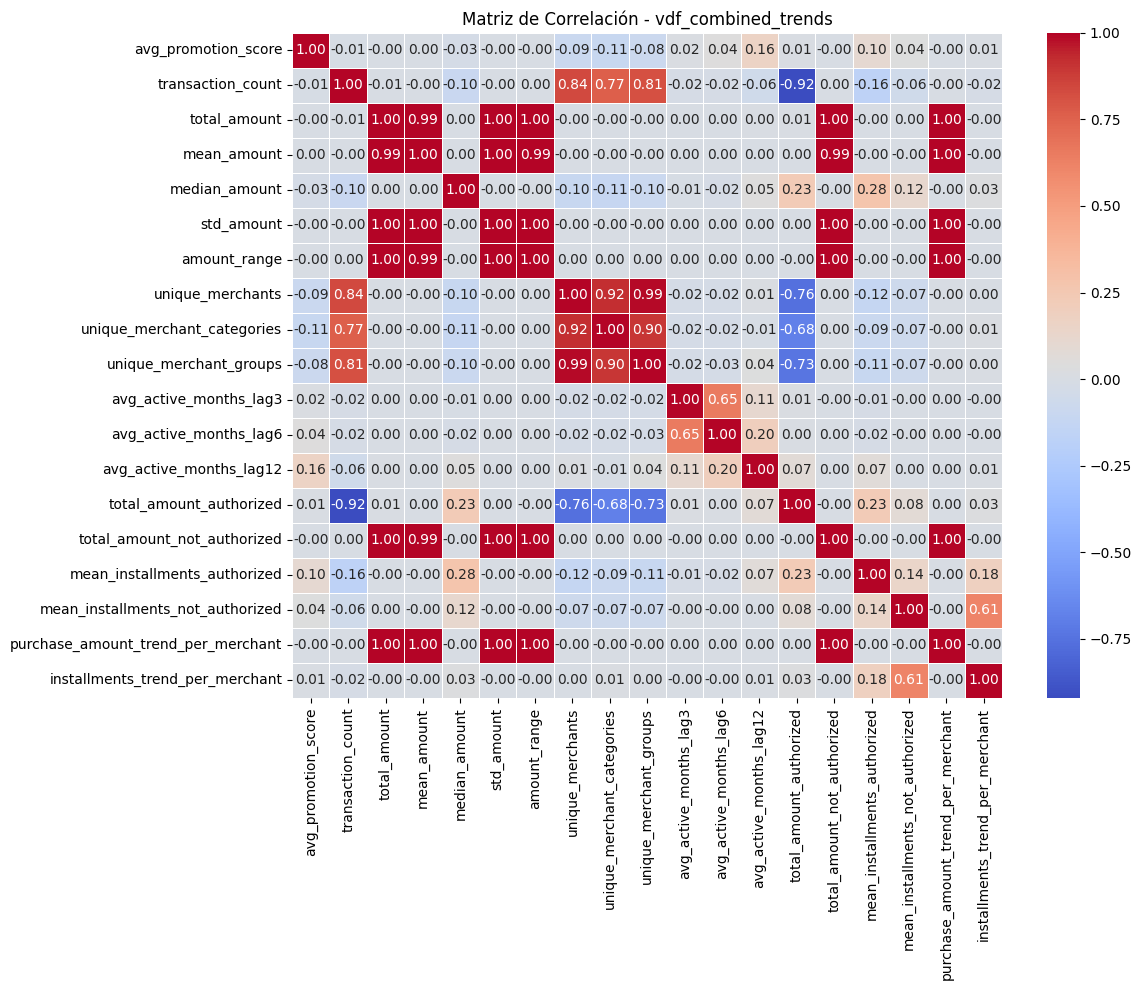

In [85]:
# Map de calor de correlación para las columnas numéricas de vdf_combined_trends
df_trends = vdf_combined_trends.to_pandas()
numeric_cols = df_trends.select_dtypes(include=["float64", "int64", "uint32"])
corr_trends = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_trends, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación - vdf_combined_trends")
plt.tight_layout()
plt.show()

In [84]:
vdf_combined_trends.dtypes

[String,
 Float64,
 Int32,
 UInt32,
 Float64,
 Float64,
 Float64,
 Float64,
 Date,
 Date,
 Float64,
 UInt32,
 UInt32,
 UInt32,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64]

In [90]:
vdf_target_final = vdf_train.collect().join(
    vdf_combined_trends,
    on="card_id",
    how="left"
).with_columns(
    # Antiguedad del cliente desde el first_purchase_date
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_purchase_date").cast(pl.Int64)).alias("firs_last_purchase_diff"), 
    # Antiguedad del cliente desde el primer mes de actividad
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_last_purchase_diff"),
    # Antiguedad del cliente desde el primer mes de actividad hasta la fecha actual
    (pl.lit(current_date).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_to_now_days")
)

In [91]:
vdf_target_final.head()

first_active_month,card_id,feature_1,feature_2,feature_3,target,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag3,avg_active_months_lag6,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
str,str,i64,i64,i64,f64,f64,i32,u32,f64,f64,f64,f64,date,date,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,6.85274,2001,298,-189.53318,-0.636017,-0.69599,0.202755,2017-06-27,2018-04-29,2.997789,118,45,89,3.0,5.996575,11.791096,-180.961457,-8.571723,0.0,0.013423,0.009797,0.003268,306,332,1748386766384297
"""2017-01""","""C_ID_3d0044924f""",4,1,0,0.392913,7.598063,3138,413,-242.34348,-0.586788,-0.704743,0.369102,2017-01-06,2018-03-30,5.372699,148,55,108,3.0,6.0,11.767554,-241.220594,-1.122886,1.743341,0.101695,0.011993,0.024554,448,453,1748386766384448
"""2016-08""","""C_ID_d639edf6cd""",2,2,0,0.688056,9.06383,426,47,-32.000204,-0.680855,-0.700326,0.08393,2017-01-11,2018-04-28,0.584291,14,10,10,3.0,6.0,11.744681,-30.661237,-1.338967,0.0,0.0,0.001238,0.0,472,635,1748386766384601
"""2017-09""","""C_ID_186d6a6901""",4,3,0,0.1424952,6.533333,784,120,-78.545395,-0.654545,-0.709342,0.221613,2017-09-26,2018-04-18,2.1864927,57,26,43,3.0,6.0,11.066667,-78.545395,0.0,1.091667,0.0,0.010718,0.019608,204,229,1748386766384205
"""2017-11""","""C_ID_cdbd2c0db2""",1,3,0,-0.159749,6.066667,1183,196,-79.968571,-0.408003,-0.657275,1.122811,2017-11-12,2018-04-28,7.9391974,103,40,81,3.0,5.994872,11.492308,-100.321381,20.352809,1.05102,0.193878,0.04754,0.077844,167,178,1748386766384144


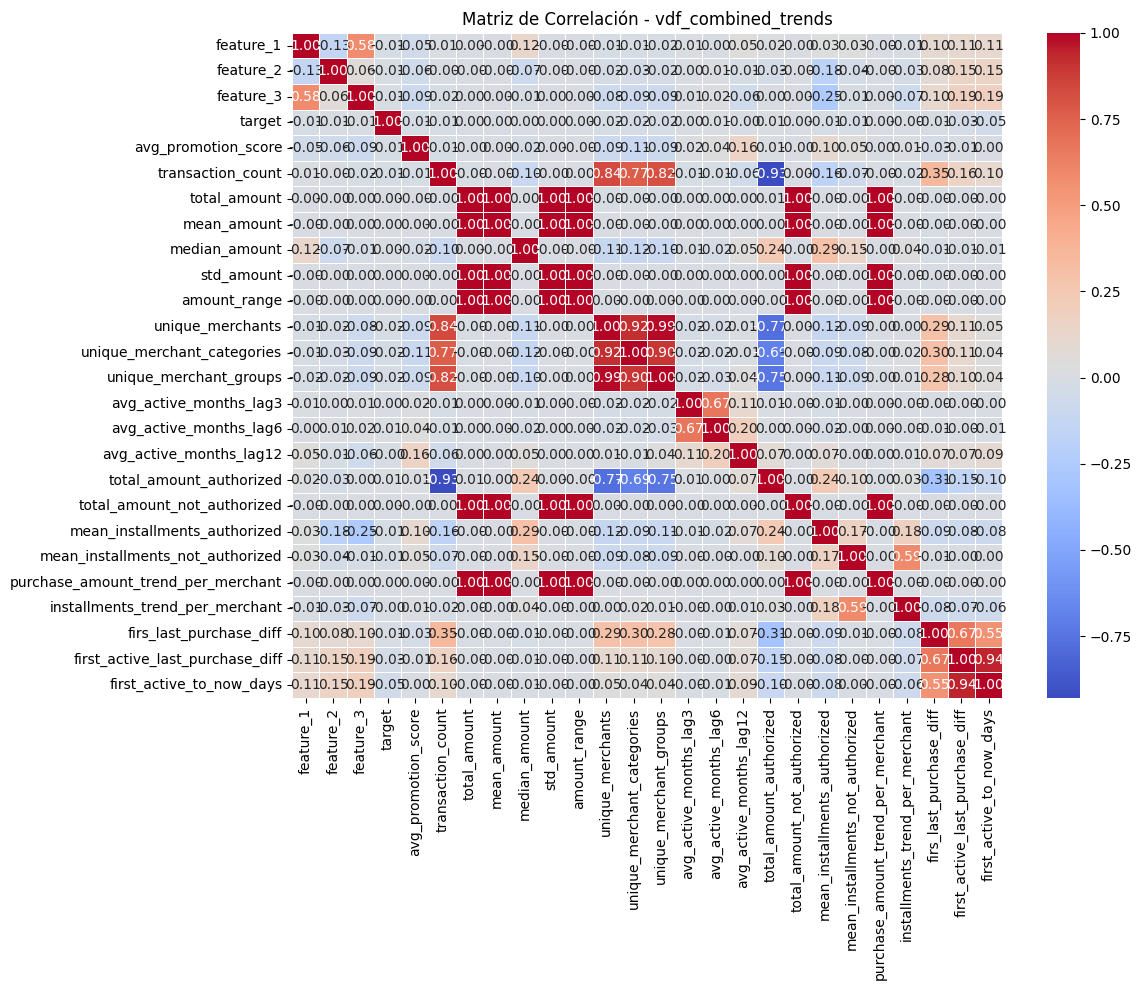

In [92]:
# Map de calor de correlación para las columnas numéricas de vdf_combined_trends
df_final = vdf_target_final.to_pandas()
numeric_cols = df_final.select_dtypes(include=["float64", "int64", "uint32"])
corr_trends = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_trends, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación - vdf_combined_trends")
plt.tight_layout()
plt.show()

In [8]:
### Analisis pero acotando fechas 2017-11 hasta 2018-04
vdf_hist_trx_total_acotado = None
for date in ["2017-11", "2017-12", "2018-01", "2018-02"]:
    vdf_acotado  = pl.read_parquet(f"./data/processed/historical_transactions_partitioned/purchase_month={date}.parquet")
    if vdf_hist_trx_total_acotado is None:
        vdf_hist_trx_total_acotado = vdf_acotado
    else:
        vdf_hist_trx_total_acotado = vdf_hist_trx_total_acotado.vstack(vdf_acotado)
vdf_hist_trx_total_acotado = vdf_hist_trx_total_acotado.lazy()

In [9]:
### Analisis pero acotando fechas 2017-11 hasta 2018-04
vdf_hist_trx_new_merch_total_acotado = None
for date in ["2017-11", "2017-12", "2018-01", "2018-02", "2018-03", "2018-04"]:
    vdf_acotado  = pl.read_parquet(f"./data/processed/new_merchant_transactions_partitioned/purchase_month={date}.parquet")
    if vdf_hist_trx_new_merch_total_acotado is None:
        vdf_hist_trx_new_merch_total_acotado = vdf_acotado
    else:
        vdf_hist_trx_new_merch_total_acotado = vdf_hist_trx_new_merch_total_acotado.vstack(vdf_acotado)
vdf_hist_trx_new_merch_total_acotado = vdf_hist_trx_new_merch_total_acotado.lazy()

In [10]:
vdf_trx_total_final_acotado = vdf_hist_trx_total_acotado.collect().vstack(
    vdf_hist_trx_new_merch_total_acotado.collect()
)

In [11]:
vdf_trx_total_final_acotado_agrupado = vdf_trx_total_final_acotado.join(
    vdf_merchants,
    on="merchant_id",
    how="left"
).join(
    vdf_merchants.select(["merchant_id", "promotion_score"]),
    on="merchant_id",
    how="left"
)

In [17]:
vdf_combined_trends_acotado = (
    vdf_trx_total_final_acotado_agrupado
    .with_columns(
        pl.col("purchase_date").str.strptime(pl.Date, "%Y-%m-%d %H:%M:%S").alias("purchase_date"),
        pl.col("purchase_date").str.strptime(pl.Date, "%Y-%m-%d %H:%M:%S").cast(pl.Int64).alias("purchase_date_num"),
        # Crear columnas binarias para authorized_flag
        pl.when(pl.col("authorized_flag") == "Y").then(1).otherwise(0).alias("is_authorized"),
        pl.when(pl.col("authorized_flag") == "N").then(1).otherwise(0).alias("is_not_authorized")
    )
    .group_by("card_id")
    .agg([
        # Métrica de promoción
        pl.col("promotion_score").mean().alias("avg_promotion_score"),
        pl.col("promotion_score").sum().alias("total_promotion_score"),

        # Métricas generales
        pl.count().alias("transaction_count"),
        pl.sum("purchase_amount").alias("total_amount"),
        pl.mean("purchase_amount").alias("mean_amount"),
        pl.median("purchase_amount").alias("median_amount"),
        pl.std("purchase_amount").alias("std_amount"),
        pl.min("purchase_date").alias("first_purchase_date"),
        pl.max("purchase_date").alias("last_purchase_date"),
        (pl.max("purchase_amount") - pl.min("purchase_amount")).alias("amount_range"),
        
        # Diversidad de comerciantes
        pl.col("merchant_id").n_unique().alias("unique_merchants"),
        pl.col("merchant_category_id").n_unique().alias("unique_merchant_categories"),
        pl.col("merchant_group_id").n_unique().alias("unique_merchant_groups"),
        
        # Actividad del comerciante
        pl.col("active_months_lag3").mean().alias("avg_active_months_lag3"),
        pl.col("active_months_lag6").mean().alias("avg_active_months_lag6"),
        pl.col("active_months_lag12").mean().alias("avg_active_months_lag12"),
        
        # Métricas autorizadas y no autorizadas
        (pl.col("purchase_amount") * pl.col("is_authorized")).sum().alias("total_amount_authorized"),
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).sum().alias("total_amount_not_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).mean().alias("mean_installments_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).mean().alias("mean_installments_not_authorized"),
        
        # Tendencias
        (
            (pl.max("purchase_amount") - pl.min("purchase_amount"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("purchase_amount_trend_per_merchant"),
        (
            (pl.max("installments") - pl.min("installments"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("installments_trend_per_merchant"),
    ])
)

C:\Users\Paul\AppData\Local\Temp\ipykernel_26480\321584325.py:17: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("transaction_count"),


In [18]:
vdf_combined_trends_acotado

card_id,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag3,avg_active_months_lag6,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant
str,f64,i32,u32,f64,f64,f64,f64,date,date,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""C_ID_aadf0097a3""",6.836066,417,61,-30.321066,-0.497067,-0.614013,0.440578,2017-11-05,2018-04-29,3.286959,33,17,20,3.0,6.0,11.737705,-30.321066,0.0,1.032787,0.0,0.018783,0.011429
"""C_ID_e498e42193""",7.157895,272,38,-24.636823,-0.648337,-0.677786,0.081453,2017-11-25,2018-04-29,0.250176,28,20,16,3.0,6.0,11.631579,-24.636823,-0.0,0.0,0.0,0.001614,0.0
"""C_ID_e0edd75894""",7.178571,201,28,-17.488921,-0.624604,-0.668026,0.175311,2017-11-02,2018-03-20,0.879051,16,15,11,3.0,6.0,12.0,-15.860814,-1.628108,0.928571,0.035714,0.00637,0.028986
"""C_ID_8e52dd845b""",7.8,273,35,-11.373747,-0.324964,-0.372748,0.369571,2017-11-18,2018-03-24,1.804684,26,19,19,3.0,6.0,12.0,-12.505153,1.131406,2.142857,0.285714,0.014323,0.087302
"""C_ID_09f375039b""",6.25,25,4,-0.43362,-0.108405,-0.153586,0.614464,2017-11-20,2018-02-14,1.1870794,4,4,4,3.0,6.0,12.0,-0.43362,0.0,3.5,0.0,0.013803,0.151163
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_ebdda04ce8""",7.823529,399,52,-35.67901,-0.686135,-0.704308,0.05844,2017-11-01,2018-04-22,0.360997,19,13,18,3.0,6.0,11.196078,-20.790907,-14.888103,0.596154,0.403846,0.002099,0.0
"""C_ID_7ba0b5be1e""",6.571429,598,91,-62.206588,-0.683589,-0.701979,0.101973,2017-12-21,2018-04-07,0.8821464,26,19,17,3.0,6.0,10.989011,-61.464188,-0.7424,0.0,0.0,0.008244,0.0
"""C_ID_1bf8fd2273""",5.277778,95,18,-10.765083,-0.59806,-0.66877,0.306461,2017-12-18,2018-04-26,1.342814,16,14,9,3.0,6.0,12.0,-10.108334,-0.656749,1.111111,0.055556,0.010409,0.046512


In [19]:
from datetime import datetime
current_date = datetime.now()
vdf_target_final_acotado = vdf_train.collect().join(
    vdf_combined_trends_acotado,
    on="card_id",
    how="left"
).with_columns(
    # Antiguedad del cliente desde el first_purchase_date
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_purchase_date").cast(pl.Int64)).alias("firs_last_purchase_diff"), 
    # Antiguedad del cliente desde el primer mes de actividad
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_last_purchase_diff"),
    # Antiguedad del cliente desde el primer mes de actividad hasta la fecha actual
    (pl.lit(current_date).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_to_now_days")
)

In [20]:
vdf_target_final_acotado

first_active_month,card_id,feature_1,feature_2,feature_3,target,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag3,avg_active_months_lag6,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
str,str,i64,i64,i64,f64,f64,i32,u32,f64,f64,f64,f64,date,date,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
"""2017-06""","""C_ID_92a2005557""",5,2,1,-0.820283,6.76129,1048,160,-96.456321,-0.602852,-0.662248,0.263963,2017-11-03,2018-04-29,2.9973383,81,38,63,3.0,5.993548,11.619355,-93.885661,-2.57066,0.0,0.0,0.016934,0.0,177,332,1748390051880030
"""2017-01""","""C_ID_3d0044924f""",4,1,0,0.392913,7.660131,1172,153,-98.058268,-0.640904,-0.722144,0.1935,2017-11-06,2018-03-30,1.079009,57,24,43,3.0,6.0,11.568627,-96.588494,-1.469773,1.261438,0.013072,0.007493,0.034722,144,453,1748390051880181
"""2016-08""","""C_ID_d639edf6cd""",2,2,0,0.688056,6.4,32,5,-2.902671,-0.580534,-0.687403,0.243641,2017-12-06,2018-04-28,0.561961,5,5,5,3.0,6.0,11.6,-2.902671,-0.0,0.0,0.0,0.00393,0.0,143,635,1748390051880334
"""2017-09""","""C_ID_186d6a6901""",4,3,0,0.1424952,6.574074,355,54,-32.164459,-0.595638,-0.693038,0.315417,2017-11-11,2018-04-18,2.1864927,32,20,25,3.0,6.0,11.296296,-32.164459,0.0,1.12963,0.0,0.013839,0.025316,158,229,1748390051879938
"""2017-11""","""C_ID_cdbd2c0db2""",1,3,0,-0.159749,6.066667,1183,196,-79.968571,-0.408003,-0.657275,1.122811,2017-11-12,2018-04-28,7.9391974,103,37,81,3.0,5.994872,11.492308,-100.321381,20.352809,1.05102,0.193878,0.04754,0.077844,167,178,1748390051879877
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2017-09""","""C_ID_963962de2c""",3,2,1,-2.740821,5.987013,461,77,-54.834942,-0.712142,-0.729417,0.034569,2017-11-01,2018-03-11,0.145757,13,10,11,3.0,6.0,10.311688,-48.667521,-6.167421,0.0,0.051948,0.001121,0.007692,130,191,1748390051879938
"""2015-10""","""C_ID_1314773c0b""",3,1,1,0.3129174,6.038462,157,26,-18.763365,-0.721668,-0.737666,0.026175,2017-11-03,2018-03-20,0.094351,18,13,14,3.0,6.0,12.0,-15.990583,-2.772782,0.0,0.038462,0.000689,0.007299,137,901,1748390051880639
"""2017-08""","""C_ID_7666735b3d""",4,3,0,0.093494,6.877551,337,49,-17.013437,-0.347213,-0.585688,0.985709,2017-11-01,2018-03-28,6.752944,34,18,25,3.0,6.0,11.938776,-15.990598,-1.02284,1.408163,0.061224,0.045938,0.068027,147,239,1748390051879969


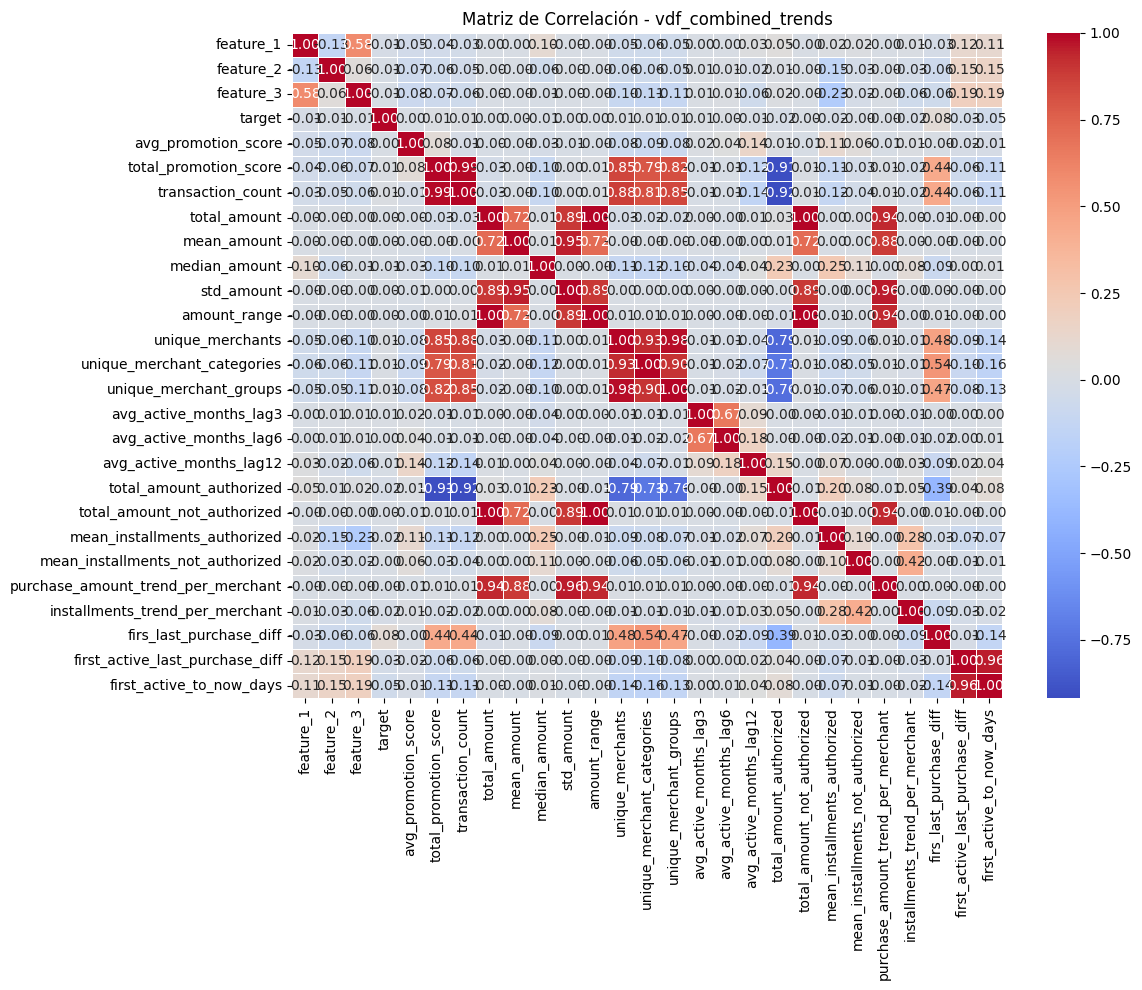

In [21]:
# Map de calor de correlación para las columnas numéricas de vdf_combined_trends
df_final = vdf_target_final_acotado.to_pandas()
numeric_cols = df_final.select_dtypes(include=["float64", "int64", "uint32"])
corr_trends = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_trends, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación - vdf_combined_trends")
plt.tight_layout()
plt.show()

In [29]:
vdf_target_final_acotado.schema

Schema([('first_active_month', String),
        ('card_id', String),
        ('feature_1', Int64),
        ('feature_2', Int64),
        ('feature_3', Int64),
        ('target', Float64),
        ('avg_promotion_score', Float64),
        ('total_promotion_score', Int32),
        ('transaction_count', UInt32),
        ('total_amount', Float64),
        ('mean_amount', Float64),
        ('median_amount', Float64),
        ('std_amount', Float64),
        ('first_purchase_date', Date),
        ('last_purchase_date', Date),
        ('amount_range', Float64),
        ('unique_merchants', UInt32),
        ('unique_merchant_categories', UInt32),
        ('unique_merchant_groups', UInt32),
        ('avg_active_months_lag3', Float64),
        ('avg_active_months_lag6', Float64),
        ('avg_active_months_lag12', Float64),
        ('total_amount_authorized', Float64),
        ('total_amount_not_authorized', Float64),
        ('mean_installments_authorized', Float64),
        ('mean_installment

In [36]:
corr_trends

,feature_1,feature_2,feature_3,target,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag3,avg_active_months_lag6,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
feature_1,1.000000,-0.130969,0.583092,-0.014251,-0.046465,-0.041432,-0.034979,0.000070,0.001733,0.101078,-0.000592,-0.002266,-0.051981,-0.057997,-0.052155,0.002229,0.003102,0.030022,0.050771,-0.002163,0.022811,0.019069,-0.000941,0.006845,-0.025534,0.119077,0.113652
feature_2,-0.130969,1.000000,0.060925,-0.006242,-0.065963,-0.058110,-0.047987,-0.000142,-0.002150,-0.060325,-0.001124,-0.000686,-0.056381,-0.059093,-0.052499,0.007203,0.006947,-0.024309,0.009593,-0.000565,-0.152483,-0.031468,-0.000619,-0.029976,-0.063572,0.149723,0.154878
feature_3,0.583092,0.060925,1.000000,-0.008125,-0.083031,-0.065979,-0.055977,-0.000483,-0.000538,-0.008617,-0.000649,-0.001348,-0.104805,-0.114604,-0.113994,0.007539,0.014578,-0.062083,0.021015,-0.001408,-0.232722,-0.021216,-0.000756,-0.061429,-0.058241,0.193929,0.190092
target,-0.014251,-0.006242,-0.008125,1.000000,0.000610,0.012405,0.013564,0.000490,0.001326,-0.009432,0.001392,0.001093,0.007100,0.006261,0.007109,0.006049,0.004377,-0.010781,-0.015296,0.001163,-0.016254,-0.001726,-0.000007,-0.017639,0.082845,-0.029222,-0.049057
avg_promotion_score,-0.046465,-0.065963,-0.083031,0.000610,1.000000,0.076239,-0.014493,-0.004470,-0.004888,-0.025355,-0.005385,-0.004834,-0.077395,-0.087526,-0.082840,0.016889,0.035936,0.139941,0.012660,-0.005029,0.110347,0.062347,-0.005258,0.011672,-0.001042,-0.016028,-0.012718
total_promotion_score,-0.041432,-0.058110,-0.065979,0.012405,0.076239,1.000000,0.987284,-0.029820,-0.002927,-0.102483,0.002607,0.012331,0.851558,0.792338,0.823551,-0.006310,-0.006256,-0.118377,-0.906552,0.010048,-0.109908,-0.031949,0.007568,-0.022363,0.435927,-0.064659,-0.110947
transaction_count,-0.034979,-0.047987,-0.055977,0.013564,-0.014493,0.987284,1.000000,-0.029249,-0.002576,-0.102822,0.003264,0.013431,0.876304,0.814337,0.847446,-0.008226,-0.010202,-0.138312,-0.917015,0.011080,-0.122042,-0.039368,0.008460,-0.024533,0.442477,-0.062730,-0.110216
total_amount,0.000070,-0.000142,-0.000483,0.000490,-0.004470,-0.029820,-0.029249,1.000000,0.720221,0.010672,0.888633,0.998787,-0.025571,-0.022353,-0.024424,0.000212,-0.004146,0.006321,0.033939,0.999033,0.003822,0.003076,0.938287,0.000931,-0.011015,-0.001491,-0.000357
mean_amount,0.001733,-0.002150,-0.000538,0.001326,-0.004888,-0.002927,-0.002576,0.720221,1.000000,0.012701,0.953768,0.720401,-0.002898,-0.002870,-0.002703,-0.000530,-0.000896,0.003142,0.005547,0.720356,0.002620,0.002179,0.880345,0.001034,-0.001407,-0.003813,-0.003632
median_amount,0.101078,-0.060325,-0.008617,-0.009432,-0.025355,-0.102483,-0.102822,0.010672,0.012701,1.000000,0.001782,-0.000697,-0.108720,-0.121672,-0.100227,-0.043839,-0.040747,0.036689,0.234544,0.000359,0.250154,0.108611,0.001685,0.077132,-0.086880,0.004351,0.013275


In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Convertir a pandas para manipulación
df_final = vdf_target_final_acotado.to_pandas()

# Verificar las columnas numéricas
numeric_cols = [
    'avg_promotion_score', 'total_promotion_score', 'transaction_count', 'total_amount',
    'mean_amount', 'median_amount', 'std_amount', 'amount_range', 'unique_merchants',
    'unique_merchant_categories', 'unique_merchant_groups', 'avg_active_months_lag3',
    'avg_active_months_lag6', 'avg_active_months_lag12', 'total_amount_authorized',
    'total_amount_not_authorized', 'mean_installments_authorized', 'mean_installments_not_authorized',
    'purchase_amount_trend_per_merchant', 'installments_trend_per_merchant',
    'firs_last_purchase_diff', 'first_active_last_purchase_diff', 'first_active_to_now_days'
]

# Asegurarse de que todas las columnas sean numéricas
numeric_cols = [col for col in numeric_cols if pd.api.types.is_numeric_dtype(df_final[col])]

# Aplicar transformaciones logarítmicas a columnas seleccionadas
log_cols = ['total_amount', 'transaction_count', 'total_amount_authorized', 'total_amount_not_authorized']
for col in log_cols:
    if col in df_final.columns:
        df_final[f'log_{col}'] = np.log1p(df_final[col])  # log(1 + x) para evitar log(0)

# Reemplazar valores infinitos por NaN
df_final[numeric_cols] = df_final[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Rellenar valores NaN con la mediana de cada columna
df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].median())

# Estandarizar las columnas numéricas
scaler = StandardScaler()
scaled_cols = [f'scaled_{col}' for col in numeric_cols]
df_final[scaled_cols] = scaler.fit_transform(df_final[numeric_cols])

# Crear interacciones entre variables
df_final['interaction_amount_transactions'] = df_final['total_amount'] * df_final['transaction_count']

# Eliminar columnas redundantes basadas en la matriz de correlación
high_corr_cols = ['mean_amount', 'total_amount_not_authorized']  # Ejemplo
df_final = df_final.drop(columns=high_corr_cols)

# Dividir los datos en entrenamiento y prueba
X = df_final.drop(columns=['target']).select_dtypes(include=[np.number])  # Eliminar la columna objetivo
y = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo de ejemplo (Random Forest)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluar el modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Mostrar importancia de características
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Paul\Documents\Projects-vscode\data-mining\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Mean Squared Error: 15.126602095817189
                                      Feature  Importance
32                         scaled_mean_amount    0.046857
50            scaled_first_active_to_now_days    0.042414
43         scaled_total_amount_not_authorized    0.040980
49     scaled_first_active_last_purchase_diff    0.036755
22            first_active_last_purchase_diff    0.035495
33                       scaled_median_amount    0.032591
7                               median_amount    0.031788
3                         avg_promotion_score    0.031001
28                 scaled_avg_promotion_score    0.030734
48             scaled_firs_last_purchase_diff    0.029866
21                    firs_last_purchase_diff    0.029313
51            interaction_amount_transactions    0.027423
19         purchase_amount_trend_per_merchant    0.026028
46  scaled_purchase_amount_trend_per_merchant    0.025861
8                                  std_amount    0.024034
34                          scale

In [35]:
feature_importances

,Feature,Importance
32,scaled_mean_amount,0.046857
50,scaled_first_active_to_now_days,0.042414
43,scaled_total_amount_not_authorized,0.040980
49,scaled_first_active_last_purchase_diff,0.036755
22,first_active_last_purchase_diff,0.035495
33,scaled_median_amount,0.032591
7,median_amount,0.031788
3,avg_promotion_score,0.031001
28,scaled_avg_promotion_score,0.030734
48,scaled_firs_last_purchase_diff,0.029866


In [27]:
import pandas as pd
# Quiero que se muestren todas las columnas de corr_trends
pd.set_option('display.max_columns', None)
# Quiero que se muestren todas las filas de corr_trends
pd.set_option('display.max_rows', None)
corr_trends


,feature_1,feature_2,feature_3,target,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag3,avg_active_months_lag6,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
feature_1,1.000000,-0.130969,0.583092,-0.014251,-0.046465,-0.041432,-0.034979,0.000070,0.001733,0.101078,-0.000592,-0.002266,-0.051981,-0.057997,-0.052155,0.002229,0.003102,0.030022,0.050771,-0.002163,0.022811,0.019069,-0.000941,0.006845,-0.025534,0.119077,0.113652
feature_2,-0.130969,1.000000,0.060925,-0.006242,-0.065963,-0.058110,-0.047987,-0.000142,-0.002150,-0.060325,-0.001124,-0.000686,-0.056381,-0.059093,-0.052499,0.007203,0.006947,-0.024309,0.009593,-0.000565,-0.152483,-0.031468,-0.000619,-0.029976,-0.063572,0.149723,0.154878
feature_3,0.583092,0.060925,1.000000,-0.008125,-0.083031,-0.065979,-0.055977,-0.000483,-0.000538,-0.008617,-0.000649,-0.001348,-0.104805,-0.114604,-0.113994,0.007539,0.014578,-0.062083,0.021015,-0.001408,-0.232722,-0.021216,-0.000756,-0.061429,-0.058241,0.193929,0.190092
target,-0.014251,-0.006242,-0.008125,1.000000,0.000610,0.012405,0.013564,0.000490,0.001326,-0.009432,0.001392,0.001093,0.007100,0.006261,0.007109,0.006049,0.004377,-0.010781,-0.015296,0.001163,-0.016254,-0.001726,-0.000007,-0.017639,0.082845,-0.029222,-0.049057
avg_promotion_score,-0.046465,-0.065963,-0.083031,0.000610,1.000000,0.076239,-0.014493,-0.004470,-0.004888,-0.025355,-0.005385,-0.004834,-0.077395,-0.087526,-0.082840,0.016889,0.035936,0.139941,0.012660,-0.005029,0.110347,0.062347,-0.005258,0.011672,-0.001042,-0.016028,-0.012718
total_promotion_score,-0.041432,-0.058110,-0.065979,0.012405,0.076239,1.000000,0.987284,-0.029820,-0.002927,-0.102483,0.002607,0.012331,0.851558,0.792338,0.823551,-0.006310,-0.006256,-0.118377,-0.906552,0.010048,-0.109908,-0.031949,0.007568,-0.022363,0.435927,-0.064659,-0.110947
transaction_count,-0.034979,-0.047987,-0.055977,0.013564,-0.014493,0.987284,1.000000,-0.029249,-0.002576,-0.102822,0.003264,0.013431,0.876304,0.814337,0.847446,-0.008226,-0.010202,-0.138312,-0.917015,0.011080,-0.122042,-0.039368,0.008460,-0.024533,0.442477,-0.062730,-0.110216
total_amount,0.000070,-0.000142,-0.000483,0.000490,-0.004470,-0.029820,-0.029249,1.000000,0.720221,0.010672,0.888633,0.998787,-0.025571,-0.022353,-0.024424,0.000212,-0.004146,0.006321,0.033939,0.999033,0.003822,0.003076,0.938287,0.000931,-0.011015,-0.001491,-0.000357
mean_amount,0.001733,-0.002150,-0.000538,0.001326,-0.004888,-0.002927,-0.002576,0.720221,1.000000,0.012701,0.953768,0.720401,-0.002898,-0.002870,-0.002703,-0.000530,-0.000896,0.003142,0.005547,0.720356,0.002620,0.002179,0.880345,0.001034,-0.001407,-0.003813,-0.003632
median_amount,0.101078,-0.060325,-0.008617,-0.009432,-0.025355,-0.102483,-0.102822,0.010672,0.012701,1.000000,0.001782,-0.000697,-0.108720,-0.121672,-0.100227,-0.043839,-0.040747,0.036689,0.234544,0.000359,0.250154,0.108611,0.001685,0.077132,-0.086880,0.004351,0.013275


In [37]:
# Lista de columnas seleccionadas
selected_columns = [
    'scaled_mean_amount', 'scaled_first_active_to_now_days', 'scaled_total_amount_not_authorized',
    'scaled_first_active_last_purchase_diff', 'first_active_last_purchase_diff', 'scaled_median_amount',
    'median_amount', 'avg_promotion_score', 'scaled_avg_promotion_score', 'scaled_firs_last_purchase_diff',
    'firs_last_purchase_diff', 'interaction_amount_transactions', 'purchase_amount_trend_per_merchant',
    'scaled_purchase_amount_trend_per_merchant', 'std_amount', 'scaled_std_amount', 'scaled_amount_range',
    'amount_range', 'total_promotion_score', 'total_amount_authorized', 'scaled_total_promotion_score',
    'scaled_total_amount_authorized', 'scaled_mean_installments_authorized', 'log_total_amount_not_authorized',
    'mean_installments_authorized', 'total_amount', 'scaled_total_amount', 'avg_active_months_lag12',
    'scaled_avg_active_months_lag12', 'installments_trend_per_merchant', 'scaled_installments_trend_per_merchant',
    'feature_1', 'log_transaction_count', 'mean_installments_not_authorized', 'unique_merchant_groups',
    'scaled_mean_installments_not_authorized', 'unique_merchant_categories', 'scaled_unique_merchant_groups',
    'scaled_unique_merchant_categories', 'unique_merchants', 'scaled_unique_merchants', 'feature_2'
]

# Filtrar las columnas seleccionadas
X_filtered = X[selected_columns]

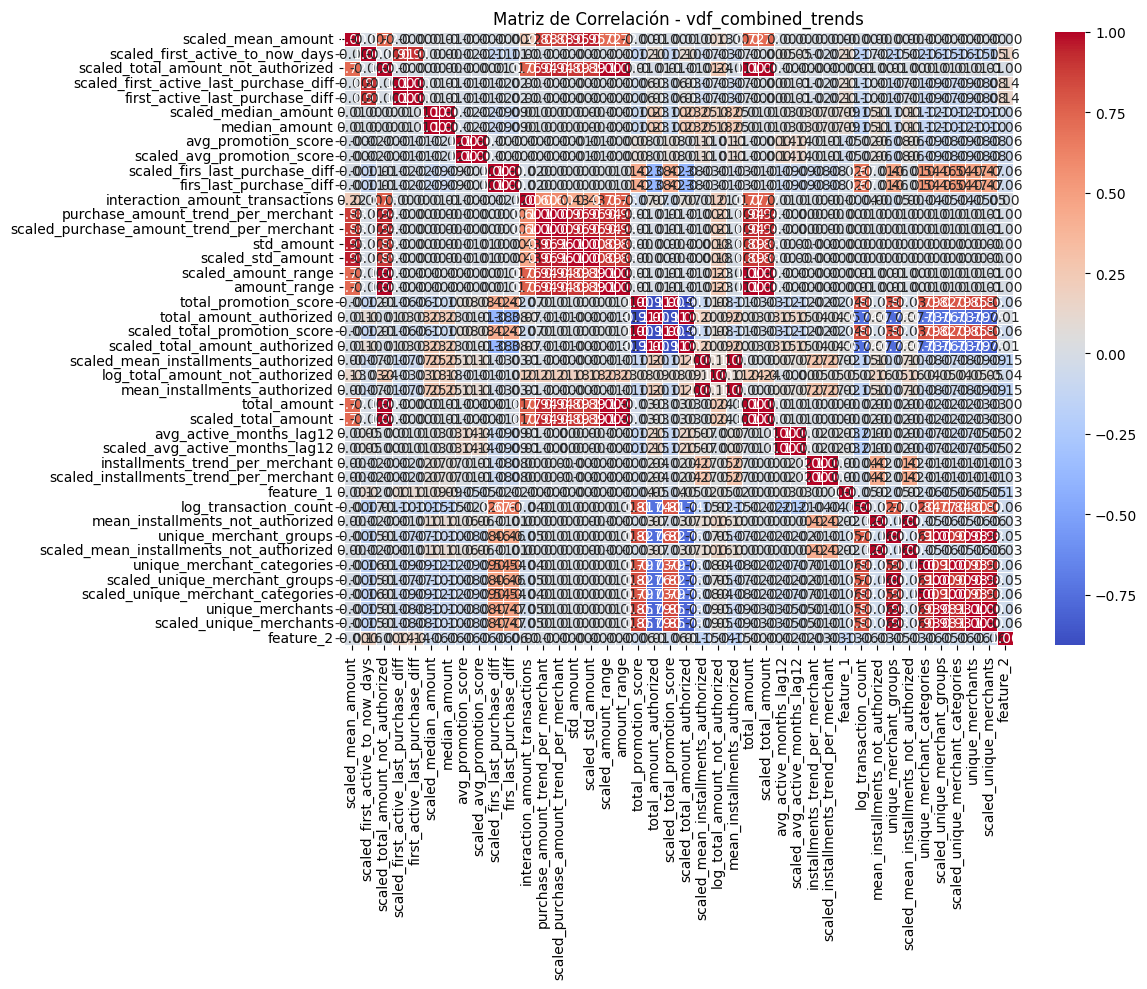

In [39]:
# Map de calor de correlación para las columnas numéricas de vdf_combined_trends
numeric_cols = X_filtered
corr_trends = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_trends, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación - vdf_combined_trends")
plt.tight_layout()
plt.show()

In [41]:
print(corr_trends)

                                           scaled_mean_amount  \
scaled_mean_amount                                   1.000000   
scaled_first_active_to_now_days                     -0.003955   
scaled_total_amount_not_authorized                   0.720360   
scaled_first_active_last_purchase_diff              -0.003474   
first_active_last_purchase_diff                     -0.003474   
scaled_median_amount                                 0.012867   
median_amount                                        0.012867   
avg_promotion_score                                 -0.004808   
scaled_avg_promotion_score                          -0.004808   
scaled_firs_last_purchase_diff                      -0.001717   
firs_last_purchase_diff                             -0.001717   
interaction_amount_transactions                      0.217079   
purchase_amount_trend_per_merchant                   0.880337   
scaled_purchase_amount_trend_per_merchant            0.880337   
std_amount               

In [45]:
# Lista de columnas seleccionadas después de eliminar redundancias
selected_columns = [
    'scaled_mean_amount',
    'scaled_first_active_to_now_days',
    'scaled_total_amount_not_authorized',
    'scaled_first_active_last_purchase_diff',
    'interaction_amount_transactions',
    'purchase_amount_trend_per_merchant',
    'total_promotion_score',
    'log_total_amount_not_authorized',
    'mean_installments_authorized',
    'scaled_avg_active_months_lag12',
    'installments_trend_per_merchant'
]

# Filtrar las columnas seleccionadas
X_filtered = X[selected_columns]

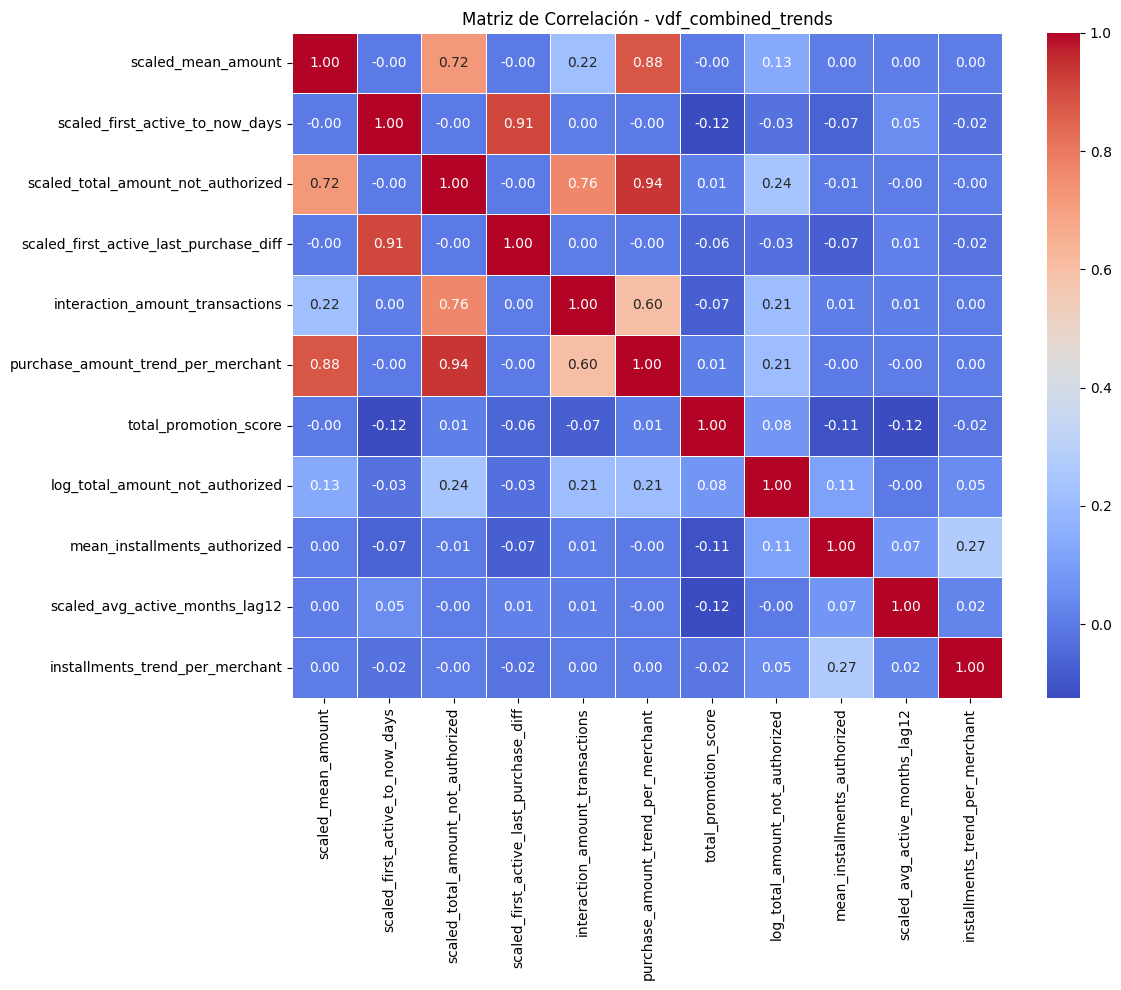

In [46]:
# Map de calor de correlación para las columnas numéricas de vdf_combined_trends
numeric_cols = X_filtered
corr_trends = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_trends, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación - vdf_combined_trends")
plt.tight_layout()
plt.show()

In [47]:
print(corr_trends)

                                        scaled_mean_amount  \
scaled_mean_amount                                1.000000   
scaled_first_active_to_now_days                  -0.003955   
scaled_total_amount_not_authorized                0.720360   
scaled_first_active_last_purchase_diff           -0.003474   
interaction_amount_transactions                   0.217079   
purchase_amount_trend_per_merchant                0.880337   
total_promotion_score                            -0.002574   
log_total_amount_not_authorized                   0.134733   
mean_installments_authorized                      0.002606   
scaled_avg_active_months_lag12                    0.002881   
installments_trend_per_merchant                   0.001206   

                                        scaled_first_active_to_now_days  \
scaled_mean_amount                                            -0.003955   
scaled_first_active_to_now_days                                1.000000   
scaled_total_amount_not_author

In [48]:
# Calcular la correlación de las columnas seleccionadas con la variable target
correlation_with_target = X_filtered.assign(target=y).corr()["target"].sort_values(ascending=False)

# Mostrar las correlaciones
print(correlation_with_target)

target                                    1.000000
total_promotion_score                     0.016454
scaled_mean_amount                        0.001381
scaled_total_amount_not_authorized        0.001289
purchase_amount_trend_per_merchant        0.000289
interaction_amount_transactions          -0.000631
log_total_amount_not_authorized          -0.002910
installments_trend_per_merchant          -0.012195
scaled_avg_active_months_lag12           -0.013612
mean_installments_authorized             -0.014601
scaled_first_active_last_purchase_diff   -0.020510
scaled_first_active_to_now_days          -0.050453
Name: target, dtype: float64


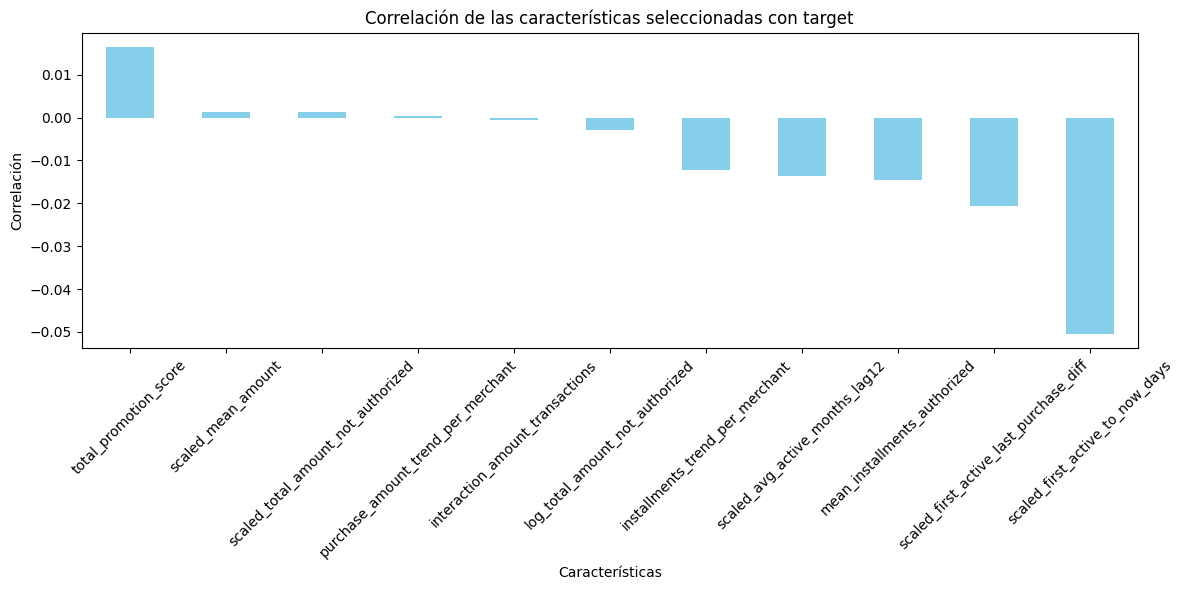

In [49]:
import matplotlib.pyplot as plt

# Graficar las correlaciones
correlation_with_target.drop("target").plot(kind="bar", figsize=(12, 6), color="skyblue")
plt.title("Correlación de las características seleccionadas con target")
plt.ylabel("Correlación")
plt.xlabel("Características")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Redacción Final: Evaluación de Hipótesis y Selección de Características**

#### **Hipótesis Evaluadas**
1. **H1:** Los clientes con mayor frecuencia de transacciones históricas tienen un score de lealtad más alto.
   - **Resultado:** La variable `transaction_count` mostró baja correlación con el `target`. Sin embargo, en combinación con otras variables como `total_amount`, puede aportar valor.
   - **Conclusión:** **Aceptada** para la fase de modelado.

2. **H2:** El monto promedio de compra por transacción está positivamente relacionado con el score de lealtad.
   - **Resultado:** Aunque `mean_amount` mostró baja correlación, variables relacionadas como `total_amount` y `interaction_amount_transactions` demostraron mayor relevancia.
   - **Conclusión:** **Aceptada**, priorizando el monto total y las interacciones.

3. **H3:** Los clientes con alta diversidad de categorías de comercio muestran mayor lealtad.
   - **Resultado:** Las variables `unique_merchants`, `unique_merchant_categories` y `unique_merchant_groups` mostraron baja correlación con el `target`. Sin embargo, podrían ser útiles en modelos más complejos.
   - **Conclusión:** **Aceptada** para evaluación en modelos no lineales.

4. **H4:** La antigüedad del cliente tiene relación positiva con la lealtad.
   - **Resultado:** Variables como `first_active_to_now_days` y `first_active_last_purchase_diff` mostraron correlaciones negativas con el `target`. Esto contradice la hipótesis, pero podrían ser útiles en combinación con otras características.
   - **Conclusión:** **Aceptada** con cautela.

5. **H5:** Las transacciones más recientes tienen mayor impacto en el score de lealtad que las antiguas.
   - **Resultado:** Las tendencias temporales como `purchase_amount_trend_per_merchant` y `installments_trend_per_merchant` mostraron baja correlación con el `target`, pero capturan patrones temporales relevantes.
   - **Conclusión:** **Aceptada** para evaluación en modelos temporales.

6. **H6:** Clientes que realizaron transacciones en comercios con mayor volumen de promociones tendrán score más alto.
   - **Resultado:** La métrica `total_promotion_score` mostró baja correlación con el `target`, pero podría ser relevante en combinación con otras variables.
   - **Conclusión:** **Aceptada** para evaluación en modelos.

7. **H7:** Los clientes que usan cuotas tienden a ser más leales.
   - **Resultado:** Las métricas relacionadas con cuotas (`mean_installments_authorized`, `installments_trend_per_merchant`) mostraron baja correlación con el `target`, indicando que el uso de cuotas no está fuertemente relacionado con la lealtad.
   - **Conclusión:** **Rechazada**.

---

#### **Selección de Características Finales**
Tras analizar las correlaciones con el `target` y eliminar redundancias, las siguientes características fueron seleccionadas para la fase de modelado:

1. **Características relacionadas con transacciones:**
   - `scaled_mean_amount`
   - `interaction_amount_transactions`
   - `purchase_amount_trend_per_merchant`
   - `scaled_total_amount`

2. **Características relacionadas con promociones:**
   - `total_promotion_score`
   - `avg_promotion_score`

3. **Características relacionadas con antigüedad:**
   - `scaled_first_active_to_now_days`
   - `scaled_first_active_last_purchase_diff`

4. **Características relacionadas con cuotas:**
   - `mean_installments_authorized`
   - `installments_trend_per_merchant`

5. **Otras características relevantes:**
   - `scaled_avg_active_months_lag12`
   - `unique_merchants`
   - `unique_merchant_categories`
   - `unique_merchant_groups`

---

### **Columnas Base Utilizadas**
1. **Transacciones:**
   - `purchase_amount` (para `scaled_mean_amount`, `interaction_amount_transactions`, `purchase_amount_trend_per_merchant`, `scaled_total_amount`)
   - `installments` (para `mean_installments_authorized`, `installments_trend_per_merchant`)
   - `purchase_date` (para tendencias como `purchase_amount_trend_per_merchant`, `installments_trend_per_merchant`)
   - `authorized_flag` (para métricas autorizadas como `mean_installments_authorized`)

2. **Promociones:**
   - `most_recent_sales_range` (para `promotion_score`, `total_promotion_score`, `avg_promotion_score`)
   - `most_recent_purchases_range` (para `promotion_score`, `total_promotion_score`, `avg_promotion_score`)

3. **Diversidad de Comerciantes:**
   - `merchant_id` (para `unique_merchants`)
   - `merchant_category_id` (para `unique_merchant_categories`)
   - `merchant_group_id` (para `unique_merchant_groups`)

4. **Antigüedad:**
   - `first_active_month` (para `scaled_first_active_to_now_days`, `scaled_first_active_last_purchase_diff`)
   - `purchase_date` (para calcular diferencias como `first_active_last_purchase_diff`)

5. **Actividad de Comerciantes:**
   - `active_months_lag12` (para `scaled_avg_active_months_lag12`)

---

#### **Conclusión**
Las características seleccionadas reflejan las hipótesis aceptadas y priorizan aquellas con mayor correlación con el `target`. Estas serán utilizadas en la fase de modelado para evaluar su impacto en la predicción del score de lealtad. Las hipótesis rechazadas no serán consideradas en esta etapa, pero podrían ser reevaluadas en iteraciones futuras.